# 퀵커머스 데이터 네트워크 분석

In [2]:
import polars as pl

# 퀵커머스 원본 데이터 로드
b3_df = pl.read_parquet("/Users/hajiyoon/workspace/data/processed/B3_OLN_ODR_DLVR.parquet")

# 데이터 크기, 컬럼 목록, 상위 5개 행 출력
print(f"데이터 크기: {b3_df.shape}")
print(f"컬럼 목록: {b3_df.columns}\n")
print(b3_df.head(5))

데이터 크기: (907439, 7)
컬럼 목록: ['점포코드', '영업일자', 'POS번호', '거래번호', '주문일자', '주문시간', '판매금액']

shape: (5, 7)
┌──────────┬──────────┬─────────┬──────────┬──────────┬──────────┬──────────┐
│ 점포코드 ┆ 영업일자 ┆ POS번호 ┆ 거래번호 ┆ 주문일자 ┆ 주문시간 ┆ 판매금액 │
│ ---      ┆ ---      ┆ ---     ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ i64      ┆ i64      ┆ i64     ┆ i64      ┆ i64      ┆ i64      ┆ str      │
╞══════════╪══════════╪═════════╪══════════╪══════════╪══════════╪══════════╡
│ 64024    ┆ 20250405 ┆ 2       ┆ 28226    ┆ 20250405 ┆ 203411   ┆ 19,700   │
│ 68999    ┆ 20250412 ┆ 1       ┆ 20507    ┆ 20250412 ┆ 130331   ┆ 13,500   │
│ 53783    ┆ 20250421 ┆ 2       ┆ 21302    ┆ 20250421 ┆ 204509   ┆ 14,400   │
│ 67630    ┆ 20250418 ┆ 2       ┆ 20641    ┆ 20250418 ┆ 152259   ┆ 13,300   │
│ 51673    ┆ 20250419 ┆ 2       ┆ 65336    ┆ 20250419 ┆ 102650   ┆ 28,600   │
└──────────┴──────────┴─────────┴──────────┴──────────┴──────────┴──────────┘


In [2]:
import polars as pl
import pandas as pd
import os
import datetime

# 💡 경로 설정 (숨은 공백 에러 방지를 위해 .strip() 유지!)
ROOT = r"/Users/hajiyoon/workspace/"
B2_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_상품단위변환전.parquet").strip()
B3_PATH = os.path.join(ROOT, "data", "processed", "B3_OLN_ODR_DLVR.parquet").strip()
B4_PATH = os.path.join(ROOT, "data", "processed", "B4_ITEM_DV_INFO.parquet").strip()
PARETO_XLSX = os.path.join(ROOT, "711project", "퀵커머스 데이터 EDA", "카테고리필터링_pareto기준자르기.xlsx").strip()

def get_filtered_npd_set():
    """14일 Burn-in + 파레토 43개 카테고리로 필터링된 최종 신상품 추출"""
    print("--- [Step 1] 핵심 43개 중분류 신상품(NPD) 추출 시작 ---")
    
    # 1. B4 식품 카테고리 필터링
    food_categories = ['음료', '과자', '유음료', '미반', '면', '냉장', '맥주', '즉석음료', '빵', '전통주',
                       '아이스크림', '조리빵', '즉석 식품', '건강/기호식품', '가공식품', '양주와인', '디저트',
                       '안주', '신선', '간식', '조미료/건물', '냉동']
    b4_df = pl.read_parquet(B4_PATH)
    if "ITEM_CD" in b4_df.columns:
        b4_df = b4_df.rename({"ITEM_CD": "상품코드"})
    b4_food = b4_df.filter(pl.col("ITEM_LRDV_NM").is_in(food_categories))
    food_item_list = b4_food.select("상품코드").to_series().to_list()

    # 2. 순수 신상품 식별 (기존 14일 로직 동일)
    b2_lazy = pl.scan_parquet(B2_PATH).filter(pl.col("상품코드").is_in(food_item_list))
    start_date = b2_lazy.select(pl.col("영업일자").min()).collect().item()
    start_dt = datetime.datetime.strptime(str(start_date), "%Y%m%d")
    burn_in_threshold = int((start_dt + datetime.timedelta(days=14)).strftime("%Y%m%d"))

    legacy_items = b2_lazy.filter(pl.col("영업일자") <= burn_in_threshold).select("상품코드").unique().collect()
    legacy_set = set(legacy_items["상품코드"].to_list())

    true_npd_df = (b2_lazy
        .filter(~pl.col("상품코드").is_in(list(legacy_set)))
        .select("상품코드").unique().collect())
    true_npd_set = set(true_npd_df["상품코드"].to_list())
    
    # 💡 3. 핵심: 파레토 필터링 엑셀 적용!
    pareto_filter_df = pd.read_excel(PARETO_XLSX)
    survived_cats = set(pareto_filter_df.loc[pareto_filter_df["사용여부"] == "O", "ITEM_MDDV_NM"].tolist())
    
    b4_pd = b4_food.select(["상품코드", "ITEM_MDDV_NM"]).to_pandas()
    survived_items = set(b4_pd[b4_pd["ITEM_MDDV_NM"].isin(survived_cats)]["상품코드"].tolist())
    
    # 교집합을 구해서 진짜 분석할 타겟만 남기기
    final_npd_set = true_npd_set.intersection(survived_items)
    
    print(f"파레토 필터 적용 후 최종 분석 대상 NPD 수: {len(final_npd_set):,}개")
    return final_npd_set

def get_quick_commerce_carts(final_npd_set):
    """최종 신상품이 포함된 퀵커머스(B3) 전체 장바구니 추출"""
    print("\n--- [Step 2] 퀵커머스 장바구니(영수증) 데이터 추출 ---")
    
    # 1. B3 로드 및 거래_고유키 생성
    b3_lazy = pl.scan_parquet(B3_PATH)
    b3_orders = b3_lazy.with_columns([
        (pl.col("영업일자").cast(pl.Utf8) + "_" + 
         pl.col("점포코드").cast(pl.Utf8) + "_" + 
         pl.col("POS번호").cast(pl.Utf8) + "_" + 
         pl.col("거래번호").cast(pl.Utf8)).alias("거래_고유키")
    ]).select(["거래_고유키"]).collect()
    target_keys_set = set(b3_orders["거래_고유키"].to_list())
    
    # 2. B2(전체 POS)에서 퀵커머스 주문 건만 필터링
    b2_lazy = pl.scan_parquet(B2_PATH)
    b2_online = b2_lazy.filter(pl.col("거래_고유키").is_in(list(target_keys_set)))
    b2_online = b2_online.with_columns(pl.col("상품코드").cast(pl.Utf8).str.strip_chars())
    
    # 3. 핵심 신상품(43개 중분류)이 1개라도 포함된 퀵커머스 영수증 찾기
    target_orders = (b2_online
        .filter(pl.col("상품코드").is_in(list(final_npd_set)))
        .select("거래_고유키")
        .unique()
        .collect()
        .to_series()
        .to_list())
    
    # 4. 해당 영수증들의 '전체 장바구니 내역' 가져오기
    target_b3_df = (b2_online
        .filter(pl.col("거래_고유키").is_in(target_orders))
        .collect())
    
    print(f"신상품 포함 퀵커머스 장바구니 개수: {len(target_orders):,} 건")
    print(f"완성된 퀵커머스 장바구니 데이터(행) 수: {len(target_b3_df):,} 건")
    
    return target_b3_df

if __name__ == "__main__":
    final_npd = get_filtered_npd_set()
    cart_df = get_quick_commerce_carts(final_npd)

--- [Step 1] 핵심 43개 중분류 신상품(NPD) 추출 시작 ---
파레토 필터 적용 후 최종 분석 대상 NPD 수: 2,493개

--- [Step 2] 퀵커머스 장바구니(영수증) 데이터 추출 ---
신상품 포함 퀵커머스 장바구니 개수: 12,591 건
완성된 퀵커머스 장바구니 데이터(행) 수: 46,169 건


In [6]:
import polars as pl

# 1. 원본 B3 데이터 로드 및 고유 주문 건수 계산
b3_lazy = pl.scan_parquet("/Users/hajiyoon/workspace/data/processed/B3_OLN_ODR_DLVR.parquet")

b3_info = b3_lazy.with_columns([
    (pl.col("영업일자").cast(pl.Utf8) + "_" + 
     pl.col("점포코드").cast(pl.Utf8) + "_" + 
     pl.col("POS번호").cast(pl.Utf8) + "_" + 
     pl.col("거래번호").cast(pl.Utf8)).alias("거래_고유키")
]).select([
    pl.col("거래_고유키").n_unique().alias("total_orders"),
    pl.len().alias("total_rows")
]).collect()

total_orders_cnt = b3_info["total_orders"][0]
total_rows_cnt = b3_info["total_rows"][0]

# 💡 2. 수정된 부분: cart_df 변수를 활용해서 개수 세기!
# 만약 이전 셀에서 다른 이름으로 받았다면 cart_df 자리에 그 변수명을 넣어줘.
extracted_orders_cnt = cart_df["거래_고유키"].n_unique()  # 고유 주문 건수
extracted_rows_cnt = cart_df.shape[0]                  # 전체 상품 판매 건수(행 수)

# 3. 비율 계산 및 출력
order_ratio = (extracted_orders_cnt / total_orders_cnt) * 100
row_ratio = (extracted_rows_cnt / total_rows_cnt) * 100

print("--- [퀵커머스 원본 대비 분석 대상 비중] ---")
print(f"1. 주문 건수(영수증) 기준: {extracted_orders_cnt:,}건 / {total_orders_cnt:,}건 ({order_ratio:.2f}%)")
print(f"2. 상품 판매 건수(행) 기준: {extracted_rows_cnt:,}건 / {total_rows_cnt:,}건 ({row_ratio:.2f}%)")

--- [퀵커머스 원본 대비 분석 대상 비중] ---
1. 주문 건수(영수증) 기준: 12,591건 / 907,431건 (1.39%)
2. 상품 판매 건수(행) 기준: 46,169건 / 907,439건 (5.09%)


In [8]:
import polars as pl
import os

# 앞서 정의된 타겟 신상품 리스트
npd_list = list(final_npd)
ROOT = r"/Users/hajiyoon/workspace/"
B2_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_상품단위변환전.parquet").strip()
B3_PATH = os.path.join(ROOT, "data", "processed", "B3_OLN_ODR_DLVR.parquet").strip()

# 1. B3 원본에서 퀵커머스 전체 고유키 추출
print("퀵커머스 원본 영수증 불러오는 중...")
b3_lazy = pl.scan_parquet(B3_PATH)
b3_keys = b3_lazy.with_columns([
    (pl.col("영업일자").cast(pl.Utf8) + "_" + 
     pl.col("점포코드").cast(pl.Utf8) + "_" + 
     pl.col("POS번호").cast(pl.Utf8) + "_" + 
     pl.col("거래번호").cast(pl.Utf8)).alias("거래_고유키")
]).select("거래_고유키").unique().collect()

b3_key_list = b3_keys["거래_고유키"].to_list()

# 2. B2(상세 데이터)에서 퀵커머스 내역만 필터링 후 영수증별 집계
print("영수증별 신상품/일반상품 비중 집계 중...")
b2_lazy = pl.scan_parquet(B2_PATH)
receipt_stats = (b2_lazy
    .filter(pl.col("거래_고유키").is_in(b3_key_list))  # 퀵커머스 영수증만
    .with_columns(pl.col("상품코드").cast(pl.Utf8).str.strip_chars())
    .group_by("거래_고유키")
    .agg([
        pl.len().alias("총_상품수"),
        pl.col("상품코드").is_in(npd_list).sum().alias("신상품수")
    ])
    .collect()
)

# 3. 3가지 구매 유형으로 분류
receipt_stats = receipt_stats.with_columns([
    pl.when(pl.col("신상품수") == pl.col("총_상품수")).then(pl.lit("신상품만"))
    .when(pl.col("신상품수") == 0).then(pl.lit("일반상품만"))
    .otherwise(pl.lit("혼합구매"))
    .alias("구매유형")
])

# 4. 결과 요약 계산
total_receipts = receipt_stats.height
summary_df = receipt_stats.group_by("구매유형").agg([
    pl.len().alias("영수증_수")
]).with_columns([
    ((pl.col("영수증_수") / total_receipts) * 100).round(2).alias("비율(%)")
]).sort("영수증_수", descending=True)

mixed_avg_items = receipt_stats.filter(
    pl.col("구매유형") == "혼합구매"
).select(pl.col("총_상품수").mean()).item()

# 5. 최종 출력
print("\n--- [전체 퀵커머스 원본 영수증 혼합구매 분석] ---")
print(summary_df)

if mixed_avg_items is not None:
    print(f"\n💡 혼합구매 영수증당 평균 상품 수: {mixed_avg_items:.2f}개")

퀵커머스 원본 영수증 불러오는 중...
영수증별 신상품/일반상품 비중 집계 중...

--- [전체 퀵커머스 원본 영수증 혼합구매 분석] ---
shape: (3, 3)
┌────────────┬───────────┬─────────┐
│ 구매유형   ┆ 영수증_수 ┆ 비율(%) │
│ ---        ┆ ---       ┆ ---     │
│ str        ┆ u32       ┆ f64     │
╞════════════╪═══════════╪═════════╡
│ 일반상품만 ┆ 19272     ┆ 60.48   │
│ 혼합구매   ┆ 7569      ┆ 23.75   │
│ 신상품만   ┆ 5022      ┆ 15.76   │
└────────────┴───────────┴─────────┘

💡 혼합구매 영수증당 평균 상품 수: 5.28개


In [9]:
import polars as pl

# 💡 변수명 에러 방지: 우리가 직전에 저장했던 이름(final_npd, cart_df) 사용!
npd_list = list(final_npd)  
target_b3_df = cart_df       

# 1. 신상품에 해당하는 행만 필터링 (일반상품 제거)
npd_only_df = target_b3_df.filter(pl.col("상품코드").is_in(npd_list))

# 2. 영수증(거래_고유키) 기준으로 신상품 개수 집계
npd_counts = npd_only_df.group_by("거래_고유키").agg(
    pl.len().alias("신상품_수")
)

# 3. 영수증 수 및 비율 계산
total_receipts = npd_counts.height

# 1개만 있는 경우
cnt_1 = npd_counts.filter(pl.col("신상품_수") == 1).height
ratio_1 = (cnt_1 / total_receipts) * 100

# 2개 이상 있는 경우
cnt_2_plus = npd_counts.filter(pl.col("신상품_수") >= 2).height
ratio_2_plus = (cnt_2_plus / total_receipts) * 100

# 2개 이상 구매한 영수증의 평균 신상품 수 계산
avg_2_plus = npd_counts.filter(pl.col("신상품_수") >= 2).select(pl.col("신상품_수").mean()).item()

# 4. 신상품 개수 상세 분포 (1개, 2개, 3개, 4개 이상)
cnt_2 = npd_counts.filter(pl.col("신상품_수") == 2).height
cnt_3 = npd_counts.filter(pl.col("신상품_수") == 3).height
cnt_4_plus = npd_counts.filter(pl.col("신상품_수") >= 4).height

# 5. 결과 출력
print("--- [신상품 간 동반구매(네트워크 기반) 분석] ---")
print(f"전체 분석 대상 영수증: {total_receipts:,}건\n")

print(f"▶ 신상품 1개만 포함: {cnt_1:,}건 ({ratio_1:.2f}%)")
print(f"▶ 신상품 2개 이상 포함: {cnt_2_plus:,}건 ({ratio_2_plus:.2f}%)")
if avg_2_plus is not None:
    print(f"   ↳ 2개 이상 구매 시 영수증당 평균 신상품 수: {avg_2_plus:.2f}개\n")

print("--- [신상품 수 상세 분포] ---")
print(f"1개: {cnt_1:,}건")
print(f"2개: {cnt_2:,}건")
print(f"3개: {cnt_3:,}건")
print(f"4개 이상: {cnt_4_plus:,}건")

--- [신상품 간 동반구매(네트워크 기반) 분석] ---
전체 분석 대상 영수증: 12,591건

▶ 신상품 1개만 포함: 9,003건 (71.50%)
▶ 신상품 2개 이상 포함: 3,588건 (28.50%)
   ↳ 2개 이상 구매 시 영수증당 평균 신상품 수: 2.51개

--- [신상품 수 상세 분포] ---
1개: 9,003건
2개: 2,342건
3개: 832건
4개 이상: 414건


혼합 구매가 상당히 이루어지고 있음. 

/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_82916/3459787655.py:78: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if "ITEM_CD" in b4_lazy.columns:


--- [Top 30 신상품 동반구매 페어 (Lift 기준)] ---
                   상품명_A                 상품명_B  Support        Lift
            초코텍)퍼지초코100g          초코텍)퍼지딸기100g        6 1541.755102
       CJ)작은햇반흑미밥130g*3입   CJ)작은햇반발아현미밥130g*3입        9 1144.636364
            PB)말차라떼250ml        PB)말차딸기라떼250ml        7  979.300000
         G)치로루초코인절미모찌35g        G)치로루초코초코모찌35g        8  932.666667
        PB)젤리초코볼샤인머스켓42g        PB)젤리초코볼오렌지42g       14  740.647059
            동원)양반현미밥130g          동원)양반흑미밥130g        7  734.475000
       칠성)핫식스더킹메가파워500ml     칠성)핫식스더킹메가제로500ml        8  699.500000
        7P)스트롱사와복숭아500ml  세븐브로이)하이볼에빠진피치500ml캔        5  655.781250
           G)스틱휘낭시에치즈39g        G)스틱휘낭시에레몬티39g        5  599.571429
           CJ)비비고군만두315g     CJ)비비고찰보리감자만두300g        5  582.916667
    앙리마티스)와인볼쇼비뇽블랑500ml캔 앙리마티스)하트와인볼(로제)500ml캔        7  572.318182
           CJ)비비고왕교자315g       CJ)비비고김치왕교자315g       14  518.452941
       롯데)마가렛트고창꿀고구마176g       롯데)빈츠고창꿀고구마102g        6  490.558442
       위드

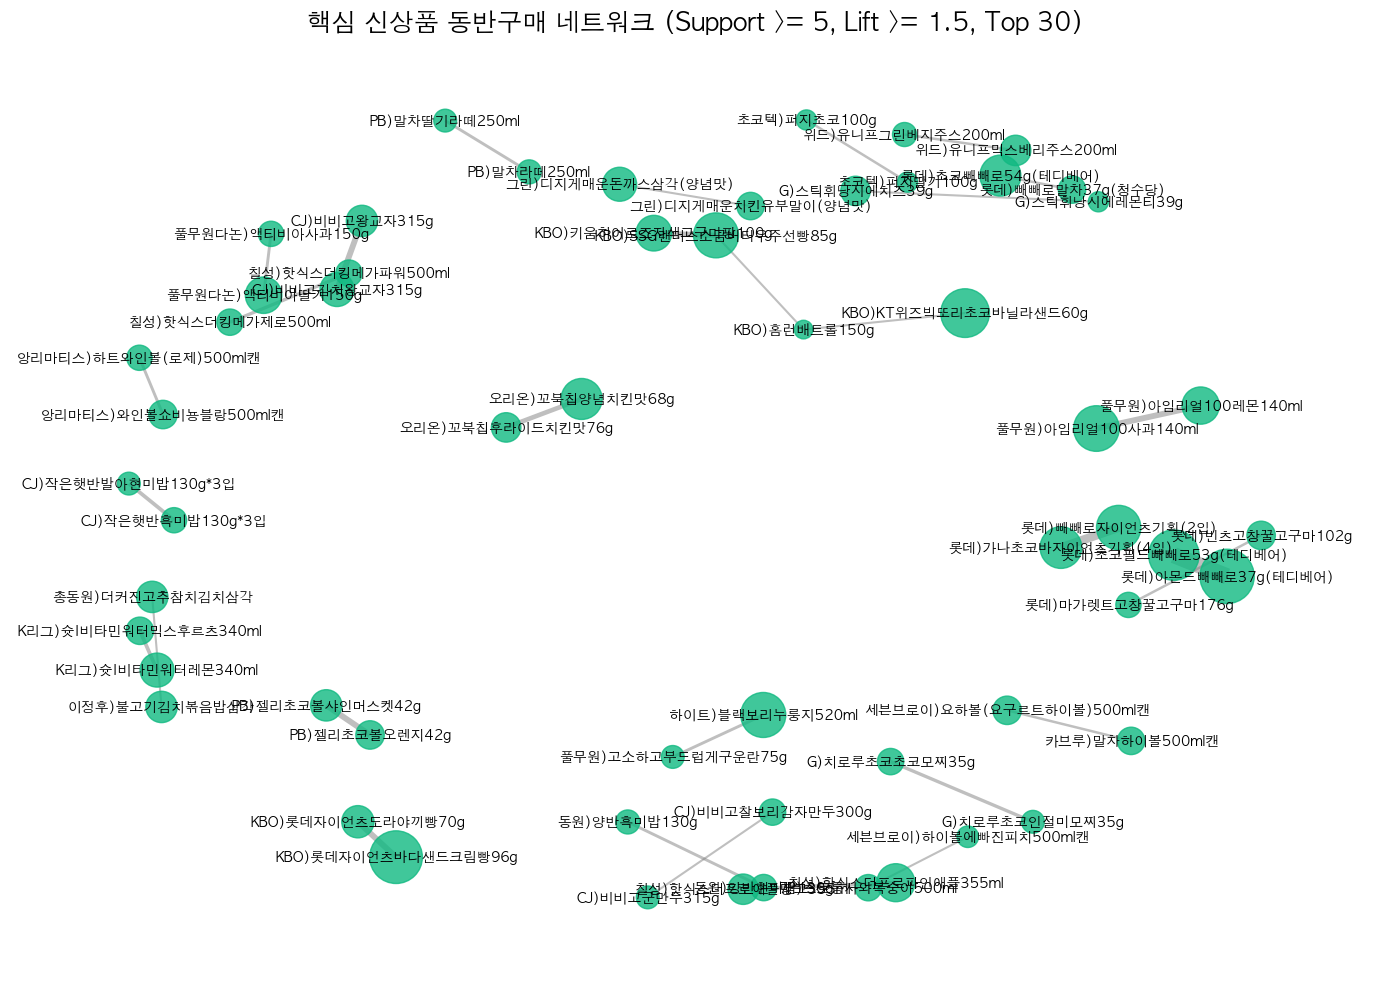

In [51]:
# support >= 5 AND lift >= 1.5 조건으로 신상품 동반구매 네트워크 분석
import polars as pl
import pandas as pd
import itertools
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt
import os

# 💡 맥북 환경 한글 폰트 깨짐 방지 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 신상품 2개 이상 영수증 필터링 및 전처리
# ==========================================
npd_list = list(final_npd)  # 앞서 저장해둔 신상품 리스트
b3_npd = cart_df.filter(pl.col("상품코드").is_in(npd_list))

# 한 영수증에서 같은 신상품을 여러 개 산 경우(예: 신상젤리 3개)는 1개로 취급 (고유 상품 종류만 페어로 봄)
b3_npd_unique = b3_npd.select(["거래_고유키", "상품코드"]).unique()

# 신상품 2개 이상 포함된 영수증 추출
receipt_counts = b3_npd_unique.group_by("거래_고유키").agg(pl.len().alias("신상품수"))
valid_keys = receipt_counts.filter(pl.col("신상품수") >= 2)["거래_고유키"].to_list()
target_df = b3_npd_unique.filter(pl.col("거래_고유키").is_in(valid_keys)).to_pandas()

# ==========================================
# 2. 페어(Pair) 추출 및 지표 계산 준비
# ==========================================
# 영수증별로 상품코드 리스트 만들기
receipt_dict = target_df.groupby("거래_고유키")["상품코드"].apply(list).to_dict()

item_counter = Counter()
pair_counter = Counter()

# 빈도수 카운트
for items in receipt_dict.values():
    items = sorted(items)  # 순서 무관 페어 생성을 위해 정렬
    for item in items:
        item_counter[item] += 1
    # itertools로 2개씩 짝지은 모든 조합 추출
    for pair in itertools.combinations(items, 2):
        pair_counter[pair] += 1

# ==========================================
# 3. Support & Lift 계산
# ==========================================
# 전체 분석 대상 영수증 수 (12,591건) - 확률 P() 계산의 분모가 됨
TOTAL_RECEIPTS = cart_df["거래_고유키"].n_unique()

results = []
for (item_A, item_B), support_cnt in pair_counter.items():
    prob_A = item_counter[item_A] / TOTAL_RECEIPTS
    prob_B = item_counter[item_B] / TOTAL_RECEIPTS
    prob_AB = support_cnt / TOTAL_RECEIPTS
    
    # Lift = P(A∩B) / (P(A) * P(B))
    lift = prob_AB / (prob_A * prob_B)
    
    results.append({
        "상품코드_A": item_A,
        "상품코드_B": item_B,
        "Support": support_cnt,  # 함께 등장한 영수증 수
        "Lift": lift             # 우연 대비 동반구매 강도
    })

pair_df = pd.DataFrame(results)

# ==========================================
# 4. 필터링 및 상품명 매핑 (B4 데이터 조인)
# ==========================================
# 조건: Support >= 5 AND Lift >= 1.5
filtered_pairs = pair_df[(pair_df["Support"] >= 5) & (pair_df["Lift"] >= 1.5)].copy()

# B4에서 상품명 가져오기
b4_lazy = pl.scan_parquet(B4_PATH)
if "ITEM_CD" in b4_lazy.columns:
    b4_lazy = b4_lazy.rename({"ITEM_CD": "상품코드", "ITEM_NM": "상품명"})
b4_map = b4_lazy.select(["상품코드", "상품명"]).collect().to_pandas()
item_dict = dict(zip(b4_map["상품코드"], b4_map["상품명"]))

filtered_pairs["상품명_A"] = filtered_pairs["상품코드_A"].map(item_dict).fillna(filtered_pairs["상품코드_A"])
filtered_pairs["상품명_B"] = filtered_pairs["상품코드_B"].map(item_dict).fillna(filtered_pairs["상품코드_B"])

# ==========================================
# 5. Top 30 결과 출력 (Lift 내림차순)
# ==========================================
top30_pairs = filtered_pairs.sort_values(by="Lift", ascending=False).head(30)
print("--- [Top 30 신상품 동반구매 페어 (Lift 기준)] ---")
print(top30_pairs[["상품명_A", "상품명_B", "Support", "Lift"]].to_string(index=False))

# ==========================================
# 6. 네트워크 시각화 (NetworkX & Matplotlib)
# ==========================================
G = nx.Graph()

# 엣지(선) 추가
for _, row in top30_pairs.iterrows():
    G.add_edge(row["상품명_A"], row["상품명_B"], weight=row["Support"])

# 노드(점) 크기 계산: 해당 상품이 2개 이상 영수증에서 등장한 총 빈도수 비례
node_sizes = []
for node in G.nodes():
    code = [k for k, v in item_dict.items() if v == node]
    freq = item_counter[code[0]] if code else 1
    node_sizes.append(freq * 30)  # 보기 좋게 크기 30배율 적용

# 엣지 굵기 계산: Support 비례
edges = G.edges()
edge_weights = [G[u][v]['weight'] * 0.3 for u, v in edges]

# 그래프 그리기
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.8, seed=42)  # k값이 클수록 노드 간 간격이 넓어짐

# 노드, 엣지, 라벨 시각화 세팅
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#10B981', alpha=0.8)
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G, pos, font_family='AppleGothic', font_size=10, font_weight='bold')

plt.title("핵심 신상품 동반구매 네트워크 (Support >= 5, Lift >= 1.5, Top 30)", fontsize=18, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

In [52]:
# 신상품 간 동반구매 네트워크 분석 - 기초 통계 지표 및 허브 상품 추출
import networkx as nx
import numpy as np

# 💡 에러 해결: 컴퓨터가 까먹지 않게 여기서 all_pairs를 다시 한 번 명확히 정의해 줄게!
all_pairs = filtered_pairs.copy()

# 1. NetworkX 그래프 생성 (전체 페어 데이터 활용)
G_all = nx.Graph()
for _, row in all_pairs.iterrows():
    G_all.add_edge(row["상품명_A"], row["상품명_B"], weight=row["Support"])

# 2. 기초 통계 지표 계산
num_nodes = G_all.number_of_nodes()
num_edges = G_all.number_of_edges()
density = nx.density(G_all)  # 네트워크 밀도

# 평균 연결선 수 (Average Degree)
degrees = [deg for node, deg in G_all.degree()]
avg_degree = np.mean(degrees) if degrees else 0

# 3. 연결 중심성(Degree Centrality) 기반 허브 상품 추출
# 특정 상품이 얼마나 많은 다른 상품들과 직접 연결되어 있는지 비율로 나타냄
degree_centrality = nx.degree_centrality(G_all)
top5_hubs = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

# 4. 통계 결과 출력
print("--- [신상품 동반구매 네트워크 기초 통계] ---")
print(f"▶ 총 노드 수 (상품 종류): {num_nodes:,}개")
print(f"▶ 총 엣지 수 (연결 조합): {num_edges:,}개")
print(f"▶ 평균 연결 수 (Avg Degree): {avg_degree:.2f}개")
print(f"▶ 네트워크 밀도 (Density): {density:.4f}\n")

print("--- [연결 중심성 Top 5 슈퍼 허브 상품] ---")
for i, (node, cent) in enumerate(top5_hubs, 1):
    # 실제 몇 개의 상품과 연결되었는지 엣지 개수도 함께 확인
    connected_count = G_all.degree(node)
    print(f"{i}위: {node} (연결된 상품 수: {connected_count}개, 중심성: {cent:.4f})")

--- [신상품 동반구매 네트워크 기초 통계] ---
▶ 총 노드 수 (상품 종류): 142개
▶ 총 엣지 수 (연결 조합): 207개
▶ 평균 연결 수 (Avg Degree): 2.92개
▶ 네트워크 밀도 (Density): 0.0207

--- [연결 중심성 Top 5 슈퍼 허브 상품] ---
1위: 롯데)7찬도시락 (연결된 상품 수: 24개, 중심성: 0.1702)
2위: KBO)KT위즈빅또리초코바닐라샌드60g (연결된 상품 수: 9개, 중심성: 0.0638)
3위: KBO)SSG랜더스소금버터우주선빵85g (연결된 상품 수: 9개, 중심성: 0.0638)
4위: PB)자이언츠돌아온팅클초코맛60g (연결된 상품 수: 9개, 중심성: 0.0638)
5위: 한도초과)의성마늘햄&고추장불고기 (연결된 상품 수: 9개, 중심성: 0.0638)


In [53]:
# 필터링 있는 네트워크
# 연결 조건: 두 상품의 조합이 Support 5 와 Lift 1.5를 동시에 만족해야만 지도에 선이 그려집니다. 하나라도 미달하면 선은 삭제됩니다.
import pandas as pd
import polars as pl
import os
import json
import networkx as nx

# ==========================================
# 1. 데이터 정제 및 상품명 매핑
# ==========================================
target_pairs = filtered_pairs.copy()
target_pairs["상품코드_A"] = target_pairs["상품코드_A"].astype(str).str.strip()
target_pairs["상품코드_B"] = target_pairs["상품코드_B"].astype(str).str.strip()

b4_lazy = pl.scan_parquet(B4_PATH)
if "ITEM_CD" in b4_lazy.columns:
    b4_lazy = b4_lazy.rename({"ITEM_CD": "상품코드", "ITEM_NM": "상품명"})
b4_map = b4_lazy.select(["상품코드", "상품명"]).collect().to_pandas()
b4_map["상품코드"] = b4_map["상품코드"].astype(str).str.strip()
item_dict = dict(zip(b4_map["상품코드"], b4_map["상품명"]))

target_pairs["formatting_A"] = target_pairs["상품코드_A"].map(item_dict).fillna(target_pairs["상품코드_A"])
target_pairs["formatting_B"] = target_pairs["상품코드_B"].map(item_dict).fillna(target_pairs["상품코드_B"])

# ==========================================
# 2. NetworkX를 통한 3대 중심성 계산 📊
# ==========================================
G_stats = nx.Graph()
for _, row in target_pairs.iterrows():
    G_stats.add_edge(row["formatting_A"], row["formatting_B"], weight=row["Support"])

# 각 중심성 계산 실행
deg_cent = nx.degree_centrality(G_stats)         
bet_cent = nx.betweenness_centrality(G_stats)      
try:
    eig_cent = nx.eigenvector_centrality(G_stats, max_iter=1000) 
except:
    eig_cent = {node: 0.0 for node in G_stats.nodes()} 

# ==========================================
# 3. 자바스크립트 전송용 노드 및 엣지 포맷팅
# ==========================================
unique_nodes = list(G_stats.nodes())

node_freqs = [item_counter.get([k for k, v in item_dict.items() if v == node][0] if [k for k, v in item_dict.items() if v == node] else node, 1) for node in unique_nodes]
threshold = pd.Series(node_freqs).quantile(0.9) if node_freqs else 0

nodes_data = []
for node in unique_nodes:
    code_lookup = [k for k, v in item_dict.items() if v == node]
    code = code_lookup[0] if code_lookup else node
    freq = item_counter.get(code, 1)
    is_star = freq >= threshold
    
    # 💡 수정된 부분: 상품명과 3가지 중심성만 깔끔하게 출력!
    tooltip_text = (
        f"<b>상품명:</b> {node}<br><br>"
        f"• 연결 중심성: {deg_cent.get(node, 0):.4f}<br>"
        f"• 매개 중심성: {bet_cent.get(node, 0):.4f}<br>"
        f"• 고유벡터 중심성: {eig_cent.get(node, 0):.4f}"
    )
    
    nodes_data.append({
        "id": str(node),
        "label": str(node),
        "shape": "star" if is_star else "dot",
        "color": "#EF4444" if is_star else "#10B981",
        "size": int(min(freq * 5, 50)),
        "title": tooltip_text 
    })

edges_data = []
for _, row in target_pairs.iterrows():
    edges_data.append({
        "from": str(row["formatting_A"]),
        "to": str(row["formatting_B"]),
        "value": int(row["Support"]),
        "title": f"Support: {row['Support']}회<br>Lift: {row['Lift']:.2f}"
    })

# ==========================================
# 4. 순수 HTML + Vis.js 인터랙티브 템플릿 작성 🛠️
# ==========================================
html_template = f"""
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <title>Quick Commerce Network Centrality Analysis</title>
    <script type="text/javascript" src="https://unpkg.com/vis-network/standalone/umd/vis-network.min.js"></script>
    <style type="text/css">
        body {{ margin: 0; padding: 0; background-color: #ffffff; font-family: sans-serif; }}
        #network {{ width: 100vw; height: 100vh; }}
    </style>
</head>
<body>
<div id="network"></div>

<script type="text/javascript">
    var nodesArray = {json.dumps(nodes_data)};
    var edgesArray = {json.dumps(edges_data)};

    var nodes = new vis.DataSet(nodesArray);
    var edges = new vis.DataSet(edgesArray);

    var container = document.getElementById('network');
    var data = {{ nodes: nodes, edges: edges }};
    
    var options = {{
        nodes: {{ borderWidthSelected: 3 }},
        edges: {{
            color: {{ inherit: true }},
            smooth: {{ type: "continuous", forceDirection: "none" }}
        }},
        interaction: {{ hover: true, selectConnectedEdges: false }},
        physics: {{
            barnesHut: {{
                gravitationalConstant: -20000,
                centralGravity: 0.3,
                springLength: 150,
                springConstant: 0.05,
                damping: 0.8,
                avoidOverlap: 0.5
            }},
            minVelocity: 0.75,
            stabilization: {{ enabled: true, iterations: 50 }}
        }}
    }};

    var network = new vis.Network(container, data, options);

    network.on("click", function (params) {{
        if (params.nodes.length > 0) {{
            var selectedNode = params.nodes[0];
            var connectedNodes = network.getConnectedNodes(selectedNode);
            
            var updateArray = nodesArray.map(function(node) {{
                if (node.id === selectedNode || connectedNodes.indexOf(node.id) !== -1) {{
                    return {{ id: node.id, color: node.color, font: {{ color: "#333333" }} }};
                }} else {{
                    return {{ id: node.id, color: "rgba(200, 200, 200, 0.2)", font: {{ color: "rgba(200, 200, 200, 0.2)" }} }};
                }}
            }});
            nodes.update(updateArray);
            
            var edgeUpdateArray = edgesArray.map(function(edge) {{
                if (edge.from === selectedNode || edge.to === selectedNode) {{
                    return {{ id: edge.id, color: {{ opacity: 1.0 }} }};
                }} else {{
                    return {{ id: edge.id, color: {{ opacity: 0.05 }} }};
                }}
            }});
            edges.update(edgeUpdateArray);
            
        }} else {{
            var resetNodes = nodesArray.map(function(node) {{
                return {{ id: node.id, color: node.color, font: {{ color: "#333333" }} }};
            }});
            nodes.update(resetNodes);
            
            var resetEdges = edgesArray.map(function(edge) {{
                return {{ id: edge.id, color: null }};
            }});
            edges.update(resetEdges);
        }}
    }});
</script>
</body>
</html>
"""

# ==========================================
# 5. 파일 저장 및 실행 완료 출력
# ==========================================
html_path = "/Users/hajiyoon/quick_network.html"
with open(html_path, "w", encoding="utf-8") as f:
    f.write(html_template)

print(f"🔥 툴팁 심플화 적용 완료! 주소: {html_path}")

/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_82916/1176160866.py:17: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if "ITEM_CD" in b4_lazy.columns:


🔥 툴팁 심플화 적용 완료! 주소: /Users/hajiyoon/quick_network.html


In [54]:
# 필터링한 네트워크 분석
import pandas as pd
import polars as pl
import networkx as nx
from collections import Counter

# ==========================================
# 0. 카테고리 매핑 및 IP/콜라보 확인 함수 준비
# ==========================================
b4_full_lazy = pl.scan_parquet(B4_PATH)
name_col = "ITEM_NM"
cat_col = "ITEM_MDDV_NM" 

b4_cat_df = b4_full_lazy.select([name_col, cat_col]).collect().to_pandas()
cat_dict = dict(zip(b4_cat_df[name_col], b4_cat_df[cat_col]))

def get_category(item_name):
    return cat_dict.get(item_name, "알수없음")

def is_ip_collab(item_name):
    keywords = ['KBO', 'PB', '콜라보', '한도초과', '리미티드', '자이언츠', '이스타)']
    return any(k in str(item_name) for k in keywords)


# 네트워크 기본 정보 세팅
nodes = list(G_stats.nodes())
degrees = dict(G_stats.degree())
num_nodes = G_stats.number_of_nodes()
num_edges = G_stats.number_of_edges()

# ==========================================
# 1. 네트워크 구조 지표
# ==========================================
avg_degree = sum(degrees.values()) / num_nodes if num_nodes > 0 else 0
density = nx.density(G_stats)
max_degree = max(degrees.values()) if degrees else 0

print("="*60)
print("📊 1. 네트워크 구조 지표")
print("="*60)
print(f"- 총 노드 수: {num_nodes}개")
print(f"- 총 엣지 수: {num_edges}개")
print(f"- 평균 연결 수(Degree): {avg_degree:.4f}")
print(f"- 네트워크 밀도(Density): {density:.4f}")
print(f"- 최대 연결 수(Max Degree): {max_degree}")
print("\n")

# ==========================================
# 2. 허브 상품 지표
# ==========================================
print("="*60)
print("👑 2. 허브 상품 지표 (Degree 중심성 Top 10)")
print("="*60)
deg_cent = nx.degree_centrality(G_stats)
top10_hubs = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]

hub_data = []
for name, cent in top10_hubs:
    hub_data.append({
        "상품명": name,
        "연결 수": degrees[name],
        "중심성": f"{cent:.4f}",
        "카테고리": get_category(name),
        "IP/콜라보": "O" if is_ip_collab(name) else "X"
    })
hub_df = pd.DataFrame(hub_data)
print(hub_df.to_string(index=False))

print("\n[허브 Top 10 중분류 카테고리 분포]")
print(hub_df["카테고리"].value_counts().to_string())
print("\n")

# ==========================================
# 3. 엣지 다양성 지표
# ==========================================
print("="*60)
print("🔗 3. 엣지 다양성 지표 (카테고리 간 연결성)")
print("="*60)
same_cat_edges = 0
diff_cat_edges = 0
cat_pairs = Counter()

for u, v in G_stats.edges():
    cat_u = get_category(u)
    cat_v = get_category(v)
    
    if cat_u == cat_v:
        same_cat_edges += 1
    else:
        diff_cat_edges += 1
        
    pair = tuple(sorted([cat_u, cat_v]))
    cat_pairs[pair] += 1
    
same_ratio = same_cat_edges / num_edges if num_edges > 0 else 0
diff_ratio = diff_cat_edges / num_edges if num_edges > 0 else 0

print(f"- 동일 카테고리 내 연결: {same_cat_edges}개 ({same_ratio*100:.4f}%)")
print(f"- 다른 카테고리 간 연결: {diff_cat_edges}개 ({diff_ratio*100:.4f}%)")

print("\n[중분류 카테고리 간 연결 조합 Top 10]")
top10_cat_pairs = cat_pairs.most_common(10)
for i, (pair, count) in enumerate(top10_cat_pairs, 1):
    print(f"{i:2d}. {pair[0]} - {pair[1]}: {count}개")
print("\n")

# ==========================================
# 4. 클러스터 지표
# ==========================================
print("="*60)
print("🧩 4. 클러스터 지표")
print("="*60)
components = list(nx.connected_components(G_stats))
num_components = len(components)
max_component_size = max([len(c) for c in components]) if components else 0
isolates = list(nx.isolates(G_stats))
num_isolates = len(isolates)

print(f"- 전체 클러스터(연결 그룹) 수: {num_components}개")
print(f"- 최대 클러스터 내 노드 수: {max_component_size}개")
print(f"- 고립 노드 수 (연결 0개): {num_isolates}개")
print("\n")

# ==========================================
# 5. 상위 10% 핵심 상품
# ==========================================
print("="*60)
print("⭐ 5. 상위 10% 핵심 상품 (등장 빈도 기준)")
print("="*60)

# 💡 수정된 부분: 상품명 노드와 상품코드 기반 item_counter를 정확히 매핑합니다.
name_to_code = {v: k for k, v in item_dict.items()}
node_freq_dict = {}

for node in G_stats.nodes():
    code = name_to_code.get(node, node)
    node_freq_dict[node] = item_counter.get(code, 1)

freq_series = pd.Series(node_freq_dict)

if not freq_series.empty:
    threshold_10pct = freq_series.quantile(0.9)
    top10pct_nodes = freq_series[freq_series >= threshold_10pct].sort_values(ascending=False)

    top10pct_data = []
    for name, freq in top10pct_nodes.items():
        top10pct_data.append({
            "상품명": name,
            "등장 빈도": freq,
            "카테고리": get_category(name),
            "IP/콜라보": "O" if is_ip_collab(name) else "X"
        })
        
    top10pct_df = pd.DataFrame(top10pct_data)
    print(top10pct_df.to_string(index=False))
else:
    print("네트워크에 분석할 노드가 없습니다.")
print("="*60)

📊 1. 네트워크 구조 지표
- 총 노드 수: 142개
- 총 엣지 수: 207개
- 평균 연결 수(Degree): 2.9155
- 네트워크 밀도(Density): 0.0207
- 최대 연결 수(Max Degree): 24


👑 2. 허브 상품 지표 (Degree 중심성 Top 10)
                    상품명  연결 수    중심성 카테고리 IP/콜라보
               롯데)7찬도시락    24 0.1702  도시락      X
  KBO)KT위즈빅또리초코바닐라샌드60g     9 0.0638  간식빵      O
  KBO)SSG랜더스소금버터우주선빵85g     9 0.0638  간식빵      O
     PB)자이언츠돌아온팅클초코맛60g     9 0.0638  스낵류      O
      한도초과)의성마늘햄&고추장불고기     9 0.0638  도시락      O
     KBO)두산베어스곰발바닥꿀빵95g     8 0.0567  간식빵      O
    KBO)LG트윈스쌍둥이딸기샌드99g     8 0.0567  간식빵      O
KBO)NC다이노스공룡알흑임자컵케익130g     8 0.0567  간식빵      O
    KBO)한화이글스핫투움바브레드90g     8 0.0567  간식빵      O
 KBO)삼성라이온즈블루베리패스츄리100g     8 0.0567  간식빵      O

[허브 Top 10 중분류 카테고리 분포]
카테고리
간식빵    7
도시락    2
스낵류    1


🔗 3. 엣지 다양성 지표 (카테고리 간 연결성)
- 동일 카테고리 내 연결: 148개 (71.4976%)
- 다른 카테고리 간 연결: 59개 (28.5024%)

[중분류 카테고리 간 연결 조합 Top 10]
 1. 간식빵 - 간식빵: 41개
 2. 도시락 - 도시락: 35개
 3. 스낵류 - 스낵류: 23개
 4. 간식빵 - 스낵류: 11개
 5. 컵커피 - 컵커피: 8개
 6. 비스킷류 - 비스킷류: 7개
 7. 스낵류 -

In [55]:
# support >5 인 네트워크 매개중심성 기준 허브 구하기

import pandas as pd
import polars as pl
import networkx as nx

# ==========================================
# 0. 사전 준비 (카테고리 및 IP/콜라보 판별 함수)
# ==========================================
# 이미 상단에서 선언되었다면 생략 가능하지만, 안전한 실행을 위해 포함합니다.
def get_category(item_name):
    try:
        return cat_dict.get(item_name, "알수없음")
    except NameError:
        return "알수없음"

def is_ip_collab(item_name):
    keywords = ['KBO', 'PB', '콜라보', '한도초과', '리미티드', '자이언츠', '이스타)']
    return any(k in str(item_name) for k in keywords)

# ==========================================
# 1. 중심성 계산 (Degree 및 Betweenness)
# ==========================================
print("⏳ 매개 중심성을 계산 중입니다... (데이터 크기에 따라 수 초 소요될 수 있습니다)")

num_nodes = G_stats.number_of_nodes()

# Degree(연결) 중심성 및 Betweenness(매개) 중심성 계산
deg_cent = nx.degree_centrality(G_stats)
bet_cent = nx.betweenness_centrality(G_stats, normalized=True)

bet_values = pd.Series(list(bet_cent.values()))

# ==========================================
# 2. 매개 중심성 분포 및 기술통계 분석
# ==========================================
zero_count = (bet_values == 0).sum()
zero_ratio = (zero_count / num_nodes) * 100 if num_nodes > 0 else 0

print(f"\n{'='*70}")
print("📊 1. 매개 중심성(Betweenness Centrality) 분포 요약 (Support >= 3)")
print(f"{'='*70}")
print(f"- 값이 0인 노드 수: {zero_count}개 (전체 {num_nodes}개 중 {zero_ratio:.2f}%)")
print(f"- 최솟값 (Min)  : {bet_values.min():.6f}")
print(f"- 최댓값 (Max)  : {bet_values.max():.6f}")
print(f"- 평  균 (Mean) : {bet_values.mean():.6f}")
print(f"- 중앙값 (Median): {bet_values.median():.6f}")
print(f"- 상위 25% (75th): {bet_values.quantile(0.75):.6f}")
print(f"- 상위 10% (90th): {bet_values.quantile(0.90):.6f}")

# 구간별 노드 수 계산
bucket_0 = zero_count
bucket_01 = ((bet_values > 0) & (bet_values <= 0.01)).sum()
bucket_05 = ((bet_values > 0.01) & (bet_values <= 0.05)).sum()
bucket_max = (bet_values > 0.05).sum()

print(f"\n[구간별 노드 수 분포]")
print(f" 1) 0 (징검다리 역할 없음) : {bucket_0}개")
print(f" 2) 0 초과 ~ 0.01 이하     : {bucket_01}개")
print(f" 3) 0.01 초과 ~ 0.05 이하  : {bucket_05}개")
print(f" 4) 0.05 초과 (핵심 허브)  : {bucket_max}개")

# ==========================================
# 3. 매개 중심성 기반 허브 상품 추출
# ==========================================
threshold_90 = bet_values.quantile(0.90)
print(f"\n{'='*70}")
print("👑 2. 허브 상품 목록 (매개 중심성 Top 10)")
print(f"{'='*70}")
print(f"💡 [허브 기준 제안] 데이터 분포 상 상위 10%에 해당하는 {threshold_90:.4f} 이상을 핵심 매개 허브로 정의합니다.\n")

# Degree 중심성 Top 10 리스트 (교집합 확인용)
top10_degree_names = [k for k, v in sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]]

# 매개 중심성 Top 10 정렬
top10_between = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:10]

hub_data = []
for rank, (name, b_val) in enumerate(top10_between, 1):
    d_val = deg_cent[name]
    # 단순 연결 수(Degree) Top 10에도 포함되는지 체크
    is_deg_top = "★" if name in top10_degree_names else ""
    
    hub_data.append({
        "순위": rank,
        "상품명": name,
        "매개 중심성": f"{b_val:.4f}",
        "Degree 중심성": f"{d_val:.4f}",
        "카테고리": get_category(name),
        "IP/콜라보": "O" if is_ip_collab(name) else "X",
        "Degree Top10": is_deg_top
    })
    
hub_df = pd.DataFrame(hub_data)
print(hub_df.to_string(index=False))

print("\n" + "-"*70)
print("* 📌 해석 가이드:")
print("  - [★ 표시가 있는 상품]: 절대적인 판매량(연결 수)도 많고, 네트워크 연결다리 역할도 수행하는 '초핵심 대장 상품'입니다.")
print("  - [★ 표시가 없는 상품]: 판매량(연결 수)은 Top 10이 아니지만, 서로 다른 소비 그룹(카테고리)을 엮어주는 '숨은 꿀조합 허브'입니다.")
print("="*70)

⏳ 매개 중심성을 계산 중입니다... (데이터 크기에 따라 수 초 소요될 수 있습니다)

📊 1. 매개 중심성(Betweenness Centrality) 분포 요약 (Support >= 3)
- 값이 0인 노드 수: 91개 (전체 142개 중 64.08%)
- 최솟값 (Min)  : 0.000000
- 최댓값 (Max)  : 0.158899
- 평  균 (Mean) : 0.004970
- 중앙값 (Median): 0.000000
- 상위 25% (75th): 0.000365
- 상위 10% (90th): 0.010478

[구간별 노드 수 분포]
 1) 0 (징검다리 역할 없음) : 91개
 2) 0 초과 ~ 0.01 이하     : 35개
 3) 0.01 초과 ~ 0.05 이하  : 12개
 4) 0.05 초과 (핵심 허브)  : 4개

👑 2. 허브 상품 목록 (매개 중심성 Top 10)
💡 [허브 기준 제안] 데이터 분포 상 상위 10%에 해당하는 0.0105 이상을 핵심 매개 허브로 정의합니다.

 순위                 상품명 매개 중심성 Degree 중심성 카테고리 IP/콜라보 Degree Top10
  1            롯데)7찬도시락 0.1589     0.1702  도시락      X            ★
  2        이스타)도쿠시마라면큰컵 0.0878     0.0284  용기면      O             
  3       자이언츠)쌔리라빠지락라면 0.0573     0.0284  용기면      O             
  4   CJ)맥스봉고소한치즈후랑크65g 0.0554     0.0426 냉장간식      X             
  5       해태)구운버터옥수수60g 0.0450     0.0426  스낵류      X             
  6  PB)자이언츠새로온팅클메론맛60g 0.0359     0.0426  스낵류      O             
  7     롯데)맛장우삼각더커

In [ ]:
# 필터링 없이 전체 연결한 네트워크
import pandas as pd
import polars as pl
import os
import json
import networkx as nx

# ==========================================
# 1. 필터 없이 전체 페어 데이터 사용 (모든 조합 연결)
# ==========================================
# 💡 핵심 수정: filtered_pairs 대신 pair_df 전체를 복사해서 사용해!
target_pairs = pair_df.copy()

target_pairs["상품코드_A"] = target_pairs["상품코드_A"].astype(str).str.strip()
target_pairs["상품코드_B"] = target_pairs["상품코드_B"].astype(str).str.strip()

# B4 마스터 데이터 매핑
b4_lazy = pl.scan_parquet(B4_PATH)
if "ITEM_CD" in b4_lazy.columns:
    b4_lazy = b4_lazy.rename({"ITEM_CD": "상품코드", "ITEM_NM": "상품명"})
b4_map = b4_lazy.select(["상품코드", "상품명"]).collect().to_pandas()
b4_map["상품코드"] = b4_map["상품코드"].astype(str).str.strip()
item_dict = dict(zip(b4_map["상품코드"], b4_map["상품명"]))

target_pairs["formatting_A"] = target_pairs["상품코드_A"].map(item_dict).fillna(target_pairs["상품코드_A"])
target_pairs["formatting_B"] = target_pairs["상품코드_B"].map(item_dict).fillna(target_pairs["상품코드_B"])

# ==========================================
# 2. NetworkX를 통한 전체 데이터 중심성 계산
# ==========================================
G_stats = nx.Graph()
for _, row in target_pairs.iterrows():
    G_stats.add_edge(row["formatting_A"], row["formatting_B"], weight=row["Support"])

deg_cent = nx.degree_centrality(G_stats)         
bet_cent = nx.betweenness_centrality(G_stats)      
try:
    eig_cent = nx.eigenvector_centrality(G_stats, max_iter=1000) 
except:
    eig_cent = {node: 0.0 for node in G_stats.nodes()} 

# ==========================================
# 3. 자바스크립트 전송용 데이터 포맷팅
# ==========================================
unique_nodes = list(G_stats.nodes())

node_freqs = [item_counter.get([k for k, v in item_dict.items() if v == node][0] if [k for k, v in item_dict.items() if v == node] else node, 1) for node in unique_nodes]
threshold = pd.Series(node_freqs).quantile(0.9) if node_freqs else 0

nodes_data = []
for node in unique_nodes:
    code_lookup = [k for k, v in item_dict.items() if v == node]
    code = code_lookup[0] if code_lookup else node
    freq = item_counter.get(code, 1)
    is_star = freq >= threshold
    
    tooltip_text = (
        f"<b>상품명:</b> {node}<br><br>"
        f"• 연결 중심성: {deg_cent.get(node, 0):.4f}<br>"
        f"• 매개 중심성: {bet_cent.get(node, 0):.4f}<br>"
        f"• 고유벡터 중심성: {eig_cent.get(node, 0):.4f}"
    )
    
    nodes_data.append({
        "id": str(node),
        "label": str(node),
        "shape": "star" if is_star else "dot",
        "color": "#EF4444" if is_star else "#10B981",
        "size": int(min(freq * 5, 50)),
        "title": tooltip_text 
    })

edges_data = []
for _, row in target_pairs.iterrows():
    edges_data.append({
        "from": str(row["formatting_A"]),
        "to": str(row["formatting_B"]),
        "value": int(row["Support"]),
        "title": f"Support: {row['Support']}회<br>Lift: {row['Lift']:.2f}"
    })

# ==========================================
# 4. 순수 HTML + Vis.js 템플릿 작성 (클릭 하이라이트 포함)
# ==========================================
html_template = f"""
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <title>Full Quick Commerce Network Analysis</title>
    <script type="text/javascript" src="https://unpkg.com/vis-network/standalone/umd/vis-network.min.js"></script>
    <style type="text/css">
        body {{ margin: 0; padding: 0; background-color: #ffffff; font-family: sans-serif; }}
        #network {{ width: 100vw; height: 100vh; }}
    </style>
</head>
<body>
<div id="network"></div>

<script type="text/javascript">
    var nodesArray = {json.dumps(nodes_data)};
    var edgesArray = {json.dumps(edges_data)};

    var nodes = new vis.DataSet(nodesArray);
    var edges = new vis.DataSet(edgesArray);

    var container = document.getElementById('network');
    var data = {{ nodes: nodes, edges: edges }};
    
    var options = {{
        nodes: {{ borderWidthSelected: 3 }},
        edges: {{
            color: {{ inherit: true }},
            smooth: {{ type: "continuous", forceDirection: "none" }}
        }},
        interaction: {{ hover: true, selectConnectedEdges: false }},
        physics: {{
            barnesHut: {{
                gravitationalConstant: -30000,
                centralGravity: 0.2,
                springLength: 200,
                springConstant: 0.02,
                damping: 0.85,
                avoidOverlap: 0.8
            }},
            minVelocity: 1.0,
            stabilization: {{ enabled: true, iterations: 100 }}
        }}
    }};

    var network = new vis.Network(container, data, options);

    network.on("click", function (params) {{
        if (params.nodes.length > 0) {{
            var selectedNode = params.nodes[0];
            var connectedNodes = network.getConnectedNodes(selectedNode);
            
            var updateArray = nodesArray.map(function(node) {{
                if (node.id === selectedNode || connectedNodes.indexOf(node.id) !== -1) {{
                    return {{ id: node.id, color: node.color, font: {{ color: "#333333" }} }};
                }} else {{
                    return {{ id: node.id, color: "rgba(200, 200, 200, 0.1)", font: {{ color: "rgba(200, 200, 200, 0.1)" }} }};
                }}
            }});
            nodes.update(updateArray);
            
            var edgeUpdateArray = edgesArray.map(function(edge) {{
                if (edge.from === selectedNode || edge.to === selectedNode) {{
                    return {{ id: edge.id, color: {{ opacity: 1.0 }} }};
                }} else {{
                    return {{ id: edge.id, color: {{ opacity: 0.02 }} }};
                }}
            }});
            edges.update(edgeUpdateArray);
            
        }} else {{
            var resetNodes = nodesArray.map(function(node) {{
                return {{ id: node.id, color: node.color, font: {{ color: "#333333" }} }};
            }});
            nodes.update(resetNodes);
            
            var resetEdges = edgesArray.map(function(edge) {{
                return {{ id: edge.id, color: null }};
            }});
            edges.update(resetEdges);
        }}
    }});
</script>
</body>
</html>
"""

# ==========================================
# 5. 파일 저장
# ==========================================
html_path = "/Users/hajiyoon/quick_network_full.html"
with open(html_path, "w", encoding="utf-8") as f:
    f.write(html_template)

print(f"🔥 전체 상품 연결 완료! 지도를 확인해 봐: {html_path}")

/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_82916/2309705332.py:18: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if "ITEM_CD" in b4_lazy.columns:


🔥 전체 상품 연결 완료! 지도를 확인해 봐: /Users/hajiyoon/quick_network_full.html


In [42]:
import pandas as pd
import polars as pl
import networkx as nx
from collections import Counter

# ==========================================
# 0. 카테고리 매핑 및 IP/콜라보 확인 함수 준비
# ==========================================
b4_full_lazy = pl.scan_parquet(B4_PATH)
name_col = "ITEM_NM"
cat_col = "ITEM_MDDV_NM" 

b4_cat_df = b4_full_lazy.select([name_col, cat_col]).collect().to_pandas()
cat_dict = dict(zip(b4_cat_df[name_col], b4_cat_df[cat_col]))

def get_category(item_name):
    return cat_dict.get(item_name, "알수없음")

# 💡 여기에 '이스타)' 키워드를 새롭게 추가했어!
def is_ip_collab(item_name):
    keywords = ['KBO', 'PB', '콜라보', '한도초과', '리미티드', '자이언츠', '이스타)']
    return any(k in str(item_name) for k in keywords)


# 네트워크 기본 정보 세팅
nodes = list(G_stats.nodes())
degrees = dict(G_stats.degree())
num_nodes = G_stats.number_of_nodes()
num_edges = G_stats.number_of_edges()

# ==========================================
# 1. 네트워크 구조 지표
# ==========================================
avg_degree = sum(degrees.values()) / num_nodes if num_nodes > 0 else 0
density = nx.density(G_stats)
max_degree = max(degrees.values()) if degrees else 0

print("="*60)
print("📊 1. 네트워크 구조 지표")
print("="*60)
print(f"- 총 노드 수: {num_nodes}개")
print(f"- 총 엣지 수: {num_edges}개")
print(f"- 평균 연결 수(Degree): {avg_degree:.4f}")
print(f"- 네트워크 밀도(Density): {density:.4f}")
print(f"- 최대 연결 수(Max Degree): {max_degree}")
print("\n")

# ==========================================
# 2. 허브 상품 지표
# ==========================================
print("="*60)
print("👑 2. 허브 상품 지표 (Degree 중심성 Top 10)")
print("="*60)
deg_cent = nx.degree_centrality(G_stats)
top10_hubs = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]

hub_data = []
for name, cent in top10_hubs:
    hub_data.append({
        "상품명": name,
        "연결 수": degrees[name],
        "중심성": f"{cent:.4f}",
        "카테고리": get_category(name),
        "IP/콜라보": "O" if is_ip_collab(name) else "X"
    })
hub_df = pd.DataFrame(hub_data)
print(hub_df.to_string(index=False))

print("\n[허브 Top 10 중분류 카테고리 분포]")
print(hub_df["카테고리"].value_counts().to_string())
print("\n")

# ==========================================
# 3. 엣지 다양성 지표
# ==========================================
print("="*60)
print("🔗 3. 엣지 다양성 지표 (카테고리 간 연결성)")
print("="*60)
same_cat_edges = 0
diff_cat_edges = 0
cat_pairs = Counter()

for u, v in G_stats.edges():
    cat_u = get_category(u)
    cat_v = get_category(v)
    
    if cat_u == cat_v:
        same_cat_edges += 1
    else:
        diff_cat_edges += 1
        
    pair = tuple(sorted([cat_u, cat_v]))
    cat_pairs[pair] += 1
    
same_ratio = same_cat_edges / num_edges if num_edges > 0 else 0
diff_ratio = diff_cat_edges / num_edges if num_edges > 0 else 0

print(f"- 동일 카테고리 내 연결: {same_cat_edges}개 ({same_ratio*100:.4f}%)")
print(f"- 다른 카테고리 간 연결: {diff_cat_edges}개 ({diff_ratio*100:.4f}%)")

print("\n[중분류 카테고리 간 연결 조합 Top 10]")
top10_cat_pairs = cat_pairs.most_common(10)
for i, (pair, count) in enumerate(top10_cat_pairs, 1):
    print(f"{i:2d}. {pair[0]} - {pair[1]}: {count}개")
print("\n")

# ==========================================
# 4. 클러스터 지표
# ==========================================
print("="*60)
print("🧩 4. 클러스터 지표")
print("="*60)
components = list(nx.connected_components(G_stats))
num_components = len(components)
max_component_size = max([len(c) for c in components]) if components else 0
isolates = list(nx.isolates(G_stats))
num_isolates = len(isolates)

print(f"- 전체 클러스터(연결 그룹) 수: {num_components}개")
print(f"- 최대 클러스터 내 노드 수: {max_component_size}개")
print(f"- 고립 노드 수 (연결 0개): {num_isolates}개")
print("\n")

# ==========================================
# 5. 상위 10% 핵심 상품
# ==========================================
print("="*60)
print("⭐ 5. 상위 10% 핵심 상품 (등장 빈도 기준)")
print("="*60)
# 이전 셀에서 만들어둔 node_freq 딕셔너리 활용
freq_series = pd.Series(node_freq)
threshold_10pct = freq_series.quantile(0.9)

top10pct_nodes = freq_series[freq_series >= threshold_10pct].sort_values(ascending=False)

top10pct_data = []
for name, freq in top10pct_nodes.items():
    top10pct_data.append({
        "상품명": name,
        "등장 빈도": freq,
        "카테고리": get_category(name),
        "IP/콜라보": "O" if is_ip_collab(name) else "X"
    })
    
top10pct_df = pd.DataFrame(top10pct_data)
print(top10pct_df.to_string(index=False))
print("="*60)

📊 1. 네트워크 구조 지표
- 총 노드 수: 682개
- 총 엣지 수: 4741개
- 평균 연결 수(Degree): 13.9032
- 네트워크 밀도(Density): 0.0204
- 최대 연결 수(Max Degree): 143


👑 2. 허브 상품 지표 (Degree 중심성 Top 10)
               상품명  연결 수    중심성 카테고리 IP/콜라보
      이스타)도쿠시마라면큰컵   143 0.2100  용기면      O
     해태)구운버터옥수수60g   119 0.1747  스낵류      X
          롯데)7찬도시락   117 0.1718  도시락      X
   롯데)맛장우삼각더커진비빔참치   114 0.1674 삼각김밥      X
         롯데)인가샌드위치   110 0.1615 샌드위치      X
 CJ)맥스봉고소한치즈후랑크65g   109 0.1601 냉장간식      X
 한도초과)의성마늘햄&고추장불고기    98 0.1439  도시락      O
PB)자이언츠돌아온팅클초코맛60g    97 0.1424  스낵류      O
      롯데)케이준치킨&햄샌드    89 0.1307 샌드위치      X
   한도초과)고민할필요없는도시락    88 0.1292  도시락      O

[허브 Top 10 중분류 카테고리 분포]
카테고리
도시락     3
스낵류     2
샌드위치    2
용기면     1
삼각김밥    1
냉장간식    1


🔗 3. 엣지 다양성 지표 (카테고리 간 연결성)
- 동일 카테고리 내 연결: 1052개 (22.1894%)
- 다른 카테고리 간 연결: 3689개 (77.8106%)

[중분류 카테고리 간 연결 조합 Top 10]
 1. 스낵류 - 스낵류: 254개
 2. 도시락 - 도시락: 173개
 3. 스낵류 - 용기면: 140개
 4. 도시락 - 샌드위치: 139개
 5. 비스킷류 - 스낵류: 122개
 6. 김밥 - 샌드위치: 111개
 7. 김밥 - 도시락: 107

In [ ]:
# 매개중심성으로 허브 구하기 (support >= 5 기준)
import pandas as pd
import polars as pl
import networkx as nx

# ==========================================
# 0. 사전 준비 (카테고리 및 IP/콜라보 판별 함수)
# ==========================================
# 이미 상단에서 선언되었다면 생략 가능하지만, 안전한 실행을 위해 포함합니다.
def get_category(item_name):
    try:
        return cat_dict.get(item_name, "알수없음")
    except NameError:
        return "알수없음"

def is_ip_collab(item_name):
    keywords = ['KBO', 'PB', '콜라보', '한도초과', '리미티드', '자이언츠', '이스타)']
    return any(k in str(item_name) for k in keywords)

# ==========================================
# 1. 중심성 계산 (Degree 및 Betweenness)
# ==========================================
print("⏳ 매개 중심성을 계산 중입니다... (데이터 크기에 따라 수 초 소요될 수 있습니다)")

num_nodes = G_stats.number_of_nodes()

# Degree(연결) 중심성 및 Betweenness(매개) 중심성 계산
deg_cent = nx.degree_centrality(G_stats)
bet_cent = nx.betweenness_centrality(G_stats, normalized=True)

bet_values = pd.Series(list(bet_cent.values()))

# ==========================================
# 2. 매개 중심성 분포 및 기술통계 분석
# ==========================================
zero_count = (bet_values == 0).sum()
zero_ratio = (zero_count / num_nodes) * 100 if num_nodes > 0 else 0

print(f"\n{'='*70}")
print("📊 1. 매개 중심성(Betweenness Centrality) 분포 요약 (Support >= 3)")
print(f"{'='*70}")
print(f"- 값이 0인 노드 수: {zero_count}개 (전체 {num_nodes}개 중 {zero_ratio:.2f}%)")
print(f"- 최솟값 (Min)  : {bet_values.min():.6f}")
print(f"- 최댓값 (Max)  : {bet_values.max():.6f}")
print(f"- 평  균 (Mean) : {bet_values.mean():.6f}")
print(f"- 중앙값 (Median): {bet_values.median():.6f}")
print(f"- 상위 25% (75th): {bet_values.quantile(0.75):.6f}")
print(f"- 상위 10% (90th): {bet_values.quantile(0.90):.6f}")

# 구간별 노드 수 계산
bucket_0 = zero_count
bucket_01 = ((bet_values > 0) & (bet_values <= 0.01)).sum()
bucket_05 = ((bet_values > 0.01) & (bet_values <= 0.05)).sum()
bucket_max = (bet_values > 0.05).sum()

print(f"\n[구간별 노드 수 분포]")
print(f" 1) 0 (징검다리 역할 없음) : {bucket_0}개")
print(f" 2) 0 초과 ~ 0.01 이하     : {bucket_01}개")
print(f" 3) 0.01 초과 ~ 0.05 이하  : {bucket_05}개")
print(f" 4) 0.05 초과 (핵심 허브)  : {bucket_max}개")

# ==========================================
# 3. 매개 중심성 기반 허브 상품 추출
# ==========================================
threshold_90 = bet_values.quantile(0.90)
print(f"\n{'='*70}")
print("👑 2. 허브 상품 목록 (매개 중심성 Top 10)")
print(f"{'='*70}")
print(f"💡 [허브 기준 제안] 데이터 분포 상 상위 10%에 해당하는 {threshold_90:.4f} 이상을 핵심 매개 허브로 정의합니다.\n")

# Degree 중심성 Top 10 리스트 (교집합 확인용)
top10_degree_names = [k for k, v in sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]]

# 매개 중심성 Top 10 정렬
top10_between = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:10]

hub_data = []
for rank, (name, b_val) in enumerate(top10_between, 1):
    d_val = deg_cent[name]
    # 단순 연결 수(Degree) Top 10에도 포함되는지 체크
    is_deg_top = "★" if name in top10_degree_names else ""
    
    hub_data.append({
        "순위": rank,
        "상품명": name,
        "매개 중심성": f"{b_val:.4f}",
        "Degree 중심성": f"{d_val:.4f}",
        "카테고리": get_category(name),
        "IP/콜라보": "O" if is_ip_collab(name) else "X",
        "Degree Top10": is_deg_top
    })
    
hub_df = pd.DataFrame(hub_data)
print(hub_df.to_string(index=False))

print("\n" + "-"*70)
print("* 📌 해석 가이드:")
print("  - [★ 표시가 있는 상품]: 절대적인 판매량(연결 수)도 많고, 네트워크 연결다리 역할도 수행하는 '초핵심 대장 상품'입니다.")
print("  - [★ 표시가 없는 상품]: 판매량(연결 수)은 Top 10이 아니지만, 서로 다른 소비 그룹(카테고리)을 엮어주는 '숨은 꿀조합 허브'입니다.")
print("="*70)

In [ ]:
# support >= 3인 네트워크 그리기 (필터링 조건 낮춤)
import pandas as pd
import polars as pl
import os
import json
import networkx as nx

# ==========================================
# 1. 데이터 필터링 및 상품명 매핑 🚨 (Support 3으로 변경)
# ==========================================
# 기존 Support 5에서 3으로 기준 완화, Lift는 1.5 유지
filtered_pairs = pair_df[(pair_df["Support"] >= 3) & (pair_df["Lift"] >= 1.5)].copy()

target_pairs = filtered_pairs.copy()
target_pairs["상품코드_A"] = target_pairs["상품코드_A"].astype(str).str.strip()
target_pairs["상품코드_B"] = target_pairs["상품코드_B"].astype(str).str.strip()

b4_lazy = pl.scan_parquet(B4_PATH)
if "ITEM_CD" in b4_lazy.columns:
    b4_lazy = b4_lazy.rename({"ITEM_CD": "상품코드", "ITEM_NM": "상품명"})
b4_map = b4_lazy.select(["상품코드", "상품명"]).collect().to_pandas()
b4_map["상품코드"] = b4_map["상품코드"].astype(str).str.strip()
item_dict = dict(zip(b4_map["상품코드"], b4_map["상품명"]))

target_pairs["formatting_A"] = target_pairs["상품코드_A"].map(item_dict).fillna(target_pairs["상품코드_A"])
target_pairs["formatting_B"] = target_pairs["상품코드_B"].map(item_dict).fillna(target_pairs["상품코드_B"])

# ==========================================
# 2. NetworkX를 통한 3대 중심성 계산 📊
# ==========================================
G_stats = nx.Graph()
for _, row in target_pairs.iterrows():
    G_stats.add_edge(row["formatting_A"], row["formatting_B"], weight=row["Support"])

# 각 중심성 계산 실행
deg_cent = nx.degree_centrality(G_stats)         
bet_cent = nx.betweenness_centrality(G_stats)      
try:
    eig_cent = nx.eigenvector_centrality(G_stats, max_iter=1000) 
except:
    eig_cent = {node: 0.0 for node in G_stats.nodes()} 

# ==========================================
# 3. 자바스크립트 전송용 노드 및 엣지 포맷팅
# ==========================================
unique_nodes = list(G_stats.nodes())

# 3,588건 동반구매 기준 빈도수 맵핑
node_freqs = [item_counter.get([k for k, v in item_dict.items() if v == node][0] if [k for k, v in item_dict.items() if v == node] else node, 1) for node in unique_nodes]
threshold = pd.Series(node_freqs).quantile(0.9) if node_freqs else 0

nodes_data = []
for node in unique_nodes:
    code_lookup = [k for k, v in item_dict.items() if v == node]
    code = code_lookup[0] if code_lookup else node
    freq = item_counter.get(code, 1)
    is_star = freq >= threshold
    
    tooltip_text = (
        f"<b>상품명:</b> {node}<br><br>"
        f"• 연결 중심성: {deg_cent.get(node, 0):.4f}<br>"
        f"• 매개 중심성: {bet_cent.get(node, 0):.4f}<br>"
        f"• 고유벡터 중심성: {eig_cent.get(node, 0):.4f}"
    )
    
    nodes_data.append({
        "id": str(node),
        "label": str(node),
        "shape": "star" if is_star else "dot",
        "color": "#EF4444" if is_star else "#10B981",
        "size": int(min(freq * 5, 50)),
        "title": tooltip_text 
    })

edges_data = []
for _, row in target_pairs.iterrows():
    edges_data.append({
        "from": str(row["formatting_A"]),
        "to": str(row["formatting_B"]),
        "value": int(row["Support"]),
        "title": f"Support: {row['Support']}회<br>Lift: {row['Lift']:.2f}"
    })

# ==========================================
# 4. 순수 HTML + Vis.js 인터랙티브 템플릿 작성 🛠️
# ==========================================
html_template = f"""
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <title>Quick Commerce Network Centrality Analysis (Support >= 3)</title>
    <script type="text/javascript" src="https://unpkg.com/vis-network/standalone/umd/vis-network.min.js"></script>
    <style type="text/css">
        body {{ margin: 0; padding: 0; background-color: #ffffff; font-family: sans-serif; }}
        #network {{ width: 100vw; height: 100vh; }}
    </style>
</head>
<body>
<div id="network"></div>

<script type="text/javascript">
    var nodesArray = {json.dumps(nodes_data)};
    var edgesArray = {json.dumps(edges_data)};

    var nodes = new vis.DataSet(nodesArray);
    var edges = new vis.DataSet(edgesArray);

    var container = document.getElementById('network');
    var data = {{ nodes: nodes, edges: edges }};
    
    var options = {{
        nodes: {{ borderWidthSelected: 3 }},
        edges: {{
            color: {{ inherit: true }},
            smooth: {{ type: "continuous", forceDirection: "none" }}
        }},
        interaction: {{ hover: true, selectConnectedEdges: false }},
        physics: {{
            barnesHut: {{
                gravitationalConstant: -20000,
                centralGravity: 0.3,
                springLength: 150,
                springConstant: 0.05,
                damping: 0.8,
                avoidOverlap: 0.5
            }},
            minVelocity: 0.75,
            stabilization: {{ enabled: true, iterations: 50 }}
        }}
    }};

    var network = new vis.Network(container, data, options);

    network.on("click", function (params) {{
        if (params.nodes.length > 0) {{
            var selectedNode = params.nodes[0];
            var connectedNodes = network.getConnectedNodes(selectedNode);
            
            var updateArray = nodesArray.map(function(node) {{
                if (node.id === selectedNode || connectedNodes.indexOf(node.id) !== -1) {{
                    return {{ id: node.id, color: node.color, font: {{ color: "#333333" }} }};
                }} else {{
                    return {{ id: node.id, color: "rgba(200, 200, 200, 0.2)", font: {{ color: "rgba(200, 200, 200, 0.2)" }} }};
                }}
            }});
            nodes.update(updateArray);
            
            var edgeUpdateArray = edgesArray.map(function(edge) {{
                if (edge.from === selectedNode || edge.to === selectedNode) {{
                    return {{ id: edge.id, color: {{ opacity: 1.0 }} }};
                }} else {{
                    return {{ id: edge.id, color: {{ opacity: 0.05 }} }};
                }}
            }});
            edges.update(edgeUpdateArray);
            
        }} else {{
            var resetNodes = nodesArray.map(function(node) {{
                return {{ id: node.id, color: node.color, font: {{ color: "#333333" }} }};
            }});
            nodes.update(resetNodes);
            
            var resetEdges = edgesArray.map(function(edge) {{
                return {{ id: edge.id, color: null }};
            }});
            edges.update(resetEdges);
        }}
    }});
</script>
</body>
</html>
"""

# ==========================================
# 5. 파일 저장 및 실행 완료 출력
# ==========================================
html_path = "/Users/hajiyoon/quick_network_support3.html"
with open(html_path, "w", encoding="utf-8") as f:
    f.write(html_template)

print(f"🔥 Support 3 기준 네트워크 생성 완료! 주소: {html_path}")

/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_82916/876470242.py:19: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if "ITEM_CD" in b4_lazy.columns:


🔥 Support 3 기준 네트워크 생성 완료! 주소: /Users/hajiyoon/quick_network_support3.html


In [49]:
# support >= 3인 네트워크 분석 (필터링 조건 낮춤)
import pandas as pd
import polars as pl
import networkx as nx
from collections import Counter

# ==========================================
# 0. 카테고리 매핑 및 IP/콜라보 확인 함수 준비
# ==========================================
b4_full_lazy = pl.scan_parquet(B4_PATH)
name_col = "ITEM_NM"
cat_col = "ITEM_MDDV_NM" 

b4_cat_df = b4_full_lazy.select([name_col, cat_col]).collect().to_pandas()
cat_dict = dict(zip(b4_cat_df[name_col], b4_cat_df[cat_col]))

def get_category(item_name):
    return cat_dict.get(item_name, "알수없음")

def is_ip_collab(item_name):
    keywords = ['KBO', 'PB', '콜라보', '한도초과', '리미티드', '자이언츠', '이스타)']
    return any(k in str(item_name) for k in keywords)


# 네트워크 기본 정보 세팅 (Support >= 3 기준 G_stats)
nodes = list(G_stats.nodes())
degrees = dict(G_stats.degree())
num_nodes = G_stats.number_of_nodes()
num_edges = G_stats.number_of_edges()

# ==========================================
# 1. 네트워크 구조 지표
# ==========================================
avg_degree = sum(degrees.values()) / num_nodes if num_nodes > 0 else 0
density = nx.density(G_stats)
max_degree = max(degrees.values()) if degrees else 0

print("="*60)
print("📊 1. 네트워크 구조 지표 (Support >= 3)")
print("="*60)
print(f"- 총 노드 수: {num_nodes}개")
print(f"- 총 엣지 수: {num_edges}개")
print(f"- 평균 연결 수(Degree): {avg_degree:.4f}")
print(f"- 네트워크 밀도(Density): {density:.4f}")
print(f"- 최대 연결 수(Max Degree): {max_degree}")
print("\n")

# ==========================================
# 2. 허브 상품 지표
# ==========================================
print("="*60)
print("👑 2. 허브 상품 지표 (Degree 중심성 Top 10)")
print("="*60)
deg_cent = nx.degree_centrality(G_stats)
top10_hubs = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]

hub_data = []
for name, cent in top10_hubs:
    hub_data.append({
        "상품명": name,
        "연결 수": degrees[name],
        "중심성": f"{cent:.4f}",
        "카테고리": get_category(name),
        "IP/콜라보": "O" if is_ip_collab(name) else "X"
    })
hub_df = pd.DataFrame(hub_data)
print(hub_df.to_string(index=False))

print("\n[허브 Top 10 중분류 카테고리 분포]")
print(hub_df["카테고리"].value_counts().to_string())
print("\n")

# ==========================================
# 3. 엣지 다양성 지표
# ==========================================
print("="*60)
print("🔗 3. 엣지 다양성 지표 (카테고리 간 연결성)")
print("="*60)
same_cat_edges = 0
diff_cat_edges = 0
cat_pairs = Counter()

for u, v in G_stats.edges():
    cat_u = get_category(u)
    cat_v = get_category(v)
    
    if cat_u == cat_v:
        same_cat_edges += 1
    else:
        diff_cat_edges += 1
        
    pair = tuple(sorted([cat_u, cat_v]))
    cat_pairs[pair] += 1
    
same_ratio = same_cat_edges / num_edges if num_edges > 0 else 0
diff_ratio = diff_cat_edges / num_edges if num_edges > 0 else 0

print(f"- 동일 카테고리 내 연결: {same_cat_edges}개 ({same_ratio*100:.4f}%)")
print(f"- 다른 카테고리 간 연결: {diff_cat_edges}개 ({diff_ratio*100:.4f}%)")

print("\n[중분류 카테고리 간 연결 조합 Top 10]")
top10_cat_pairs = cat_pairs.most_common(10)
for i, (pair, count) in enumerate(top10_cat_pairs, 1):
    print(f"{i:2d}. {pair[0]} - {pair[1]}: {count}개")
print("\n")

# ==========================================
# 4. 클러스터 지표
# ==========================================
print("="*60)
print("🧩 4. 클러스터 지표")
print("="*60)
components = list(nx.connected_components(G_stats))
num_components = len(components)
max_component_size = max([len(c) for c in components]) if components else 0
isolates = list(nx.isolates(G_stats))
num_isolates = len(isolates)

print(f"- 전체 클러스터(연결 그룹) 수: {num_components}개")
print(f"- 최대 클러스터 내 노드 수: {max_component_size}개")
print(f"- 고립 노드 수 (연결 0개): {num_isolates}개")
print("\n")

# ==========================================
# 5. 상위 10% 핵심 상품
# ==========================================
print("="*60)
print("⭐ 5. 상위 10% 핵심 상품 (등장 빈도 기준)")
print("="*60)

# 상품명 노드와 상품코드 기반 item_counter 매핑
name_to_code = {v: k for k, v in item_dict.items()}
node_freq_dict = {}

for node in G_stats.nodes():
    code = name_to_code.get(node, node)
    node_freq_dict[node] = item_counter.get(code, 1)

freq_series = pd.Series(node_freq_dict)

if not freq_series.empty:
    threshold_10pct = freq_series.quantile(0.9)
    top10pct_nodes = freq_series[freq_series >= threshold_10pct].sort_values(ascending=False)

    top10pct_data = []
    for name, freq in top10pct_nodes.items():
        top10pct_data.append({
            "상품명": name,
            "등장 빈도": freq,
            "카테고리": get_category(name),
            "IP/콜라보": "O" if is_ip_collab(name) else "X"
        })
        
    top10pct_df = pd.DataFrame(top10pct_data)
    print(top10pct_df.to_string(index=False))
else:
    print("네트워크에 분석할 노드가 없습니다.")
print("="*60)

📊 1. 네트워크 구조 지표 (Support >= 3)
- 총 노드 수: 214개
- 총 엣지 수: 461개
- 평균 연결 수(Degree): 4.3084
- 네트워크 밀도(Density): 0.0202
- 최대 연결 수(Max Degree): 39


👑 2. 허브 상품 지표 (Degree 중심성 Top 10)
               상품명  연결 수    중심성 카테고리 IP/콜라보
          롯데)7찬도시락    39 0.1831  도시락      X
 한도초과)의성마늘햄&고추장불고기    26 0.1221  도시락      O
         롯데)인가샌드위치    24 0.1127 샌드위치      X
PB)자이언츠돌아온팅클초코맛60g    20 0.0939  스낵류      O
   롯데)맛장우삼각더커진비빔참치    19 0.0892 삼각김밥      X
      이스타)도쿠시마라면큰컵    19 0.0892  용기면      O
   한도초과)고민할필요없는도시락    17 0.0798  도시락      O
    롯데)리얼소프트햄&에그샌드    16 0.0751 샌드위치      X
     해태)구운버터옥수수60g    15 0.0704  스낵류      X
 CJ)맥스봉고소한치즈후랑크65g    15 0.0704 냉장간식      X

[허브 Top 10 중분류 카테고리 분포]
카테고리
도시락     3
샌드위치    2
스낵류     2
삼각김밥    1
용기면     1
냉장간식    1


🔗 3. 엣지 다양성 지표 (카테고리 간 연결성)
- 동일 카테고리 내 연결: 253개 (54.8807%)
- 다른 카테고리 간 연결: 208개 (45.1193%)

[중분류 카테고리 간 연결 조합 Top 10]
 1. 도시락 - 도시락: 58개
 2. 스낵류 - 스낵류: 47개
 3. 간식빵 - 간식빵: 43개
 4. 샌드위치 - 샌드위치: 27개
 5. 도시락 - 샌드위치: 21개
 6. 비스킷류 - 스낵류: 17개
 7. 간식빵 - 스

In [50]:
# 매개중심성으로 허브 구하기 (support >= 3 기준)
import pandas as pd
import polars as pl
import networkx as nx

# ==========================================
# 0. 사전 준비 (카테고리 및 IP/콜라보 판별 함수)
# ==========================================
# 이미 상단에서 선언되었다면 생략 가능하지만, 안전한 실행을 위해 포함합니다.
def get_category(item_name):
    try:
        return cat_dict.get(item_name, "알수없음")
    except NameError:
        return "알수없음"

def is_ip_collab(item_name):
    keywords = ['KBO', 'PB', '콜라보', '한도초과', '리미티드', '자이언츠', '이스타)']
    return any(k in str(item_name) for k in keywords)

# ==========================================
# 1. 중심성 계산 (Degree 및 Betweenness)
# ==========================================
print("⏳ 매개 중심성을 계산 중입니다... (데이터 크기에 따라 수 초 소요될 수 있습니다)")

num_nodes = G_stats.number_of_nodes()

# Degree(연결) 중심성 및 Betweenness(매개) 중심성 계산
deg_cent = nx.degree_centrality(G_stats)
bet_cent = nx.betweenness_centrality(G_stats, normalized=True)

bet_values = pd.Series(list(bet_cent.values()))

# ==========================================
# 2. 매개 중심성 분포 및 기술통계 분석
# ==========================================
zero_count = (bet_values == 0).sum()
zero_ratio = (zero_count / num_nodes) * 100 if num_nodes > 0 else 0

print(f"\n{'='*70}")
print("📊 1. 매개 중심성(Betweenness Centrality) 분포 요약 (Support >= 3)")
print(f"{'='*70}")
print(f"- 값이 0인 노드 수: {zero_count}개 (전체 {num_nodes}개 중 {zero_ratio:.2f}%)")
print(f"- 최솟값 (Min)  : {bet_values.min():.6f}")
print(f"- 최댓값 (Max)  : {bet_values.max():.6f}")
print(f"- 평  균 (Mean) : {bet_values.mean():.6f}")
print(f"- 중앙값 (Median): {bet_values.median():.6f}")
print(f"- 상위 25% (75th): {bet_values.quantile(0.75):.6f}")
print(f"- 상위 10% (90th): {bet_values.quantile(0.90):.6f}")

# 구간별 노드 수 계산
bucket_0 = zero_count
bucket_01 = ((bet_values > 0) & (bet_values <= 0.01)).sum()
bucket_05 = ((bet_values > 0.01) & (bet_values <= 0.05)).sum()
bucket_max = (bet_values > 0.05).sum()

print(f"\n[구간별 노드 수 분포]")
print(f" 1) 0 (징검다리 역할 없음) : {bucket_0}개")
print(f" 2) 0 초과 ~ 0.01 이하     : {bucket_01}개")
print(f" 3) 0.01 초과 ~ 0.05 이하  : {bucket_05}개")
print(f" 4) 0.05 초과 (핵심 허브)  : {bucket_max}개")

# ==========================================
# 3. 매개 중심성 기반 허브 상품 추출
# ==========================================
threshold_90 = bet_values.quantile(0.90)
print(f"\n{'='*70}")
print("👑 2. 허브 상품 목록 (매개 중심성 Top 10)")
print(f"{'='*70}")
print(f"💡 [허브 기준 제안] 데이터 분포 상 상위 10%에 해당하는 {threshold_90:.4f} 이상을 핵심 매개 허브로 정의합니다.\n")

# Degree 중심성 Top 10 리스트 (교집합 확인용)
top10_degree_names = [k for k, v in sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]]

# 매개 중심성 Top 10 정렬
top10_between = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:10]

hub_data = []
for rank, (name, b_val) in enumerate(top10_between, 1):
    d_val = deg_cent[name]
    # 단순 연결 수(Degree) Top 10에도 포함되는지 체크
    is_deg_top = "★" if name in top10_degree_names else ""
    
    hub_data.append({
        "순위": rank,
        "상품명": name,
        "매개 중심성": f"{b_val:.4f}",
        "Degree 중심성": f"{d_val:.4f}",
        "카테고리": get_category(name),
        "IP/콜라보": "O" if is_ip_collab(name) else "X",
        "Degree Top10": is_deg_top
    })
    
hub_df = pd.DataFrame(hub_data)
print(hub_df.to_string(index=False))

print("\n" + "-"*70)
print("* 📌 해석 가이드:")
print("  - [★ 표시가 있는 상품]: 절대적인 판매량(연결 수)도 많고, 네트워크 연결다리 역할도 수행하는 '초핵심 대장 상품'입니다.")
print("  - [★ 표시가 없는 상품]: 판매량(연결 수)은 Top 10이 아니지만, 서로 다른 소비 그룹(카테고리)을 엮어주는 '숨은 꿀조합 허브'입니다.")
print("="*70)

⏳ 매개 중심성을 계산 중입니다... (데이터 크기에 따라 수 초 소요될 수 있습니다)

📊 1. 매개 중심성(Betweenness Centrality) 분포 요약 (Support >= 3)
- 값이 0인 노드 수: 118개 (전체 214개 중 55.14%)
- 최솟값 (Min)  : 0.000000
- 최댓값 (Max)  : 0.123843
- 평  균 (Mean) : 0.004886
- 중앙값 (Median): 0.000000
- 상위 25% (75th): 0.001455
- 상위 10% (90th): 0.015649

[구간별 노드 수 분포]
 1) 0 (징검다리 역할 없음) : 118개
 2) 0 초과 ~ 0.01 이하     : 69개
 3) 0.01 초과 ~ 0.05 이하  : 23개
 4) 0.05 초과 (핵심 허브)  : 4개

👑 2. 허브 상품 목록 (매개 중심성 Top 10)
💡 [허브 기준 제안] 데이터 분포 상 상위 10%에 해당하는 0.0156 이상을 핵심 매개 허브로 정의합니다.

 순위                 상품명 매개 중심성 Degree 중심성 카테고리 IP/콜라보 Degree Top10
  1            롯데)7찬도시락 0.1238     0.1831  도시락      X            ★
  2        이스타)도쿠시마라면큰컵 0.0925     0.0892  용기면      O            ★
  3           롯데)인가샌드위치 0.0728     0.1127 샌드위치      X            ★
  4           농심)메론킥60g 0.0530     0.0657  스낵류      X             
  5  PB)자이언츠돌아온팅클초코맛60g 0.0407     0.0939  스낵류      O            ★
  6 그린)디지게매운등심돈까스(디진다맛) 0.0396     0.0657  도시락      X             
  7   한도초과)의성마늘햄

# 오프라인 포스데이터 네트워크

In [1]:
# 포스데이터 분석 대상상품만으로 필터링 & 장바구니 만들기
import polars as pl
import pandas as pd
import os
import datetime

# 💡 경로 설정 (기존과 동일)
ROOT = r"/Users/hajiyoon/workspace/"
B2_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_상품단위변환전.parquet").strip()
B3_PATH = os.path.join(ROOT, "data", "processed", "B3_OLN_ODR_DLVR.parquet").strip()
B4_PATH = os.path.join(ROOT, "data", "processed", "B4_ITEM_DV_INFO.parquet").strip()
PARETO_XLSX = os.path.join(ROOT, "711project", "퀵커머스 데이터 EDA", "카테고리필터링_pareto기준자르기.xlsx").strip()

def get_filtered_npd_set():
    """14일 Burn-in + 파레토 43개 카테고리로 필터링된 최종 신상품 추출 (기존 로직 100% 동일)"""
    print("--- [Step 1] 핵심 43개 중분류 신상품(NPD) 추출 시작 ---")
    
    food_categories = ['음료', '과자', '유음료', '미반', '면', '냉장', '맥주', '즉석음료', '빵', '전통주',
                       '아이스크림', '조리빵', '즉석 식품', '건강/기호식품', '가공식품', '양주와인', '디저트',
                       '안주', '신선', '간식', '조미료/건물', '냉동']
    b4_df = pl.read_parquet(B4_PATH)
    if "ITEM_CD" in b4_df.columns:
        b4_df = b4_df.rename({"ITEM_CD": "상품코드"})
    b4_food = b4_df.filter(pl.col("ITEM_LRDV_NM").is_in(food_categories))
    food_item_list = b4_food.select("상품코드").to_series().to_list()

    b2_lazy = pl.scan_parquet(B2_PATH).filter(pl.col("상품코드").is_in(food_item_list))
    start_date = b2_lazy.select(pl.col("영업일자").min()).collect().item()
    start_dt = datetime.datetime.strptime(str(start_date), "%Y%m%d")
    burn_in_threshold = int((start_dt + datetime.timedelta(days=14)).strftime("%Y%m%d"))

    legacy_items = b2_lazy.filter(pl.col("영업일자") <= burn_in_threshold).select("상품코드").unique().collect()
    legacy_set = set(legacy_items["상품코드"].to_list())

    true_npd_df = (b2_lazy
        .filter(~pl.col("상품코드").is_in(list(legacy_set)))
        .select("상품코드").unique().collect())
    true_npd_set = set(true_npd_df["상품코드"].to_list())
    
    pareto_filter_df = pd.read_excel(PARETO_XLSX)
    survived_cats = set(pareto_filter_df.loc[pareto_filter_df["사용여부"] == "O", "ITEM_MDDV_NM"].tolist())
    
    b4_pd = b4_food.select(["상품코드", "ITEM_MDDV_NM"]).to_pandas()
    survived_items = set(b4_pd[b4_pd["ITEM_MDDV_NM"].isin(survived_cats)]["상품코드"].tolist())
    
    final_npd_set = true_npd_set.intersection(survived_items)
    
    print(f"파레토 필터 적용 후 최종 분석 대상 NPD 수: {len(final_npd_set):,}개")
    return final_npd_set

def get_offline_carts(final_npd_set):
    """최종 신상품이 포함된 오프라인(순수 오프라인 매장 결제) 전체 장바구니 추출"""
    print("\n--- [Step 2] 오프라인 장바구니(영수증) 데이터 추출 ---")
    
    # 1. B3 로드 및 퀵커머스 거래_고유키 파악 (온라인 건을 빼내기 위해 필요)
    b3_lazy = pl.scan_parquet(B3_PATH)
    b3_orders = b3_lazy.with_columns([
        (pl.col("영업일자").cast(pl.Utf8) + "_" + 
         pl.col("점포코드").cast(pl.Utf8) + "_" + 
         pl.col("POS번호").cast(pl.Utf8) + "_" + 
         pl.col("거래번호").cast(pl.Utf8)).alias("거래_고유키")
    ]).select(["거래_고유키"]).collect()
    online_keys_set = set(b3_orders["거래_고유키"].to_list())
    
    # 2. B2(전체 POS)에서 퀵커머스 주문 건만 제외하여 오프라인 필터링
    # 💡 핵심 수정 포인트: is_in 앞에 틸다(~)를 붙여 차집합(온라인 제외)으로 만듭니다.
    b2_lazy = pl.scan_parquet(B2_PATH)
    b2_offline = b2_lazy.filter(~pl.col("거래_고유키").is_in(list(online_keys_set)))
    b2_offline = b2_offline.with_columns(pl.col("상품코드").cast(pl.Utf8).str.strip_chars())
    
    # 3. 핵심 신상품(43개 중분류)이 1개라도 포함된 오프라인 영수증 찾기
    target_orders = (b2_offline
        .filter(pl.col("상품코드").is_in(list(final_npd_set)))
        .select("거래_고유키")
        .unique()
        .collect()
        .to_series()
        .to_list())
    
    # 4. 해당 영수증들의 '전체 장바구니 내역' 가져오기
    target_b2_df = (b2_offline
        .filter(pl.col("거래_고유키").is_in(target_orders))
        .collect())
    
    print(f"신상품 포함 오프라인 장바구니 개수: {len(target_orders):,} 건")
    print(f"완성된 오프라인 장바구니 데이터(행) 수: {len(target_b2_df):,} 건")
    
    return target_b2_df

if __name__ == "__main__":
    final_npd = get_filtered_npd_set()
    # cart_df 변수에 오프라인 장바구니 데이터가 담깁니다.
    cart_df = get_offline_carts(final_npd)

--- [Step 1] 핵심 43개 중분류 신상품(NPD) 추출 시작 ---
파레토 필터 적용 후 최종 분석 대상 NPD 수: 2,493개

--- [Step 2] 오프라인 장바구니(영수증) 데이터 추출 ---
신상품 포함 오프라인 장바구니 개수: 6,584,722 건
완성된 오프라인 장바구니 데이터(행) 수: 17,179,498 건


In [ ]:
# '전체 모수 대비 우리가 분석할 타겟 데이터의 비중' 확인해보기

import polars as pl
import os

# 💡 경로 설정 (이전과 동일)
ROOT = r"/Users/hajiyoon/workspace/"
B2_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_상품단위변환전.parquet").strip()
B3_PATH = os.path.join(ROOT, "data", "processed", "B3_OLN_ODR_DLVR.parquet").strip()

# 1. 퀵커머스(B3) 거래키 추출 (오프라인 모수에서 제외하기 위함)
b3_lazy = pl.scan_parquet(B3_PATH)
online_keys_df = b3_lazy.with_columns([
    (pl.col("영업일자").cast(pl.Utf8) + "_" + 
     pl.col("점포코드").cast(pl.Utf8) + "_" + 
     pl.col("POS번호").cast(pl.Utf8) + "_" + 
     pl.col("거래번호").cast(pl.Utf8)).alias("거래_고유키")
]).select("거래_고유키").unique().collect()
online_keys_set = set(online_keys_df["거래_고유키"].to_list())

# 2. 순수 오프라인(B2 - B3) 전체 모수 계산 (분모)
b2_lazy = pl.scan_parquet(B2_PATH)
pure_offline_lazy = b2_lazy.filter(~pl.col("거래_고유키").is_in(list(online_keys_set)))

offline_info = pure_offline_lazy.select([
    pl.col("거래_고유키").n_unique().alias("total_orders"),
    pl.len().alias("total_rows")
]).collect()

total_offline_orders_cnt = offline_info["total_orders"][0]
total_offline_rows_cnt = offline_info["total_rows"][0]

# 3. 추출된 타겟 데이터(cart_df) 개수 세기 (분자)
extracted_orders_cnt = cart_df["거래_고유키"].n_unique()  # 고유 주문 건수 (Polars 방식)
extracted_rows_cnt = cart_df.height

# 4. 비율 계산 및 출력
order_ratio = (extracted_orders_cnt / total_offline_orders_cnt) * 100
row_ratio = (extracted_rows_cnt / total_offline_rows_cnt) * 100

print("--- [순수 오프라인 원본 대비 신상품(NPD) 타겟 분석 대상 비중] ---")
print(f"1. 주문 건수(영수증) 기준: {extracted_orders_cnt:,}건 / {total_offline_orders_cnt:,}건 ({order_ratio:.2f}%)")
print(f"2. 상품 판매 건수(행) 기준: {extracted_rows_cnt:,}건 / {total_offline_rows_cnt:,}건 ({row_ratio:.2f}%)")

--- [순수 오프라인 원본 대비 신상품(NPD) 타겟 분석 대상 비중] ---
1. 주문 건수(영수증) 기준: 6,584,722건 / 40,005,815건 (16.46%)
2. 상품 판매 건수(행) 기준: 17,179,498건 / 73,213,875건 (23.46%)


In [ ]:
# 전체 오프라인 영수증을 3가지 유형(신상품만, 일반상품만, 혼합구매)으로 분류해보기

import polars as pl
import os

# 💡 사전 정의된 타겟 신상품 리스트 및 경로 설정
npd_list = list(final_npd)
ROOT = r"/Users/hajiyoon/workspace/"
B2_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_상품단위변환전.parquet").strip()
B3_PATH = os.path.join(ROOT, "data", "processed", "B3_OLN_ODR_DLVR.parquet").strip()

# 1. 퀵커머스(B3) 원본에서 거래키 추출 (오프라인 모수에서 제외하기 위함)
print("1. 온라인(퀵커머스) 영수증 키 추출 중...")
b3_lazy = pl.scan_parquet(B3_PATH)
online_keys = b3_lazy.with_columns([
    (pl.col("영업일자").cast(pl.Utf8) + "_" + 
     pl.col("점포코드").cast(pl.Utf8) + "_" + 
     pl.col("POS번호").cast(pl.Utf8) + "_" + 
     pl.col("거래번호").cast(pl.Utf8)).alias("거래_고유키")
]).select("거래_고유키").unique().collect()

online_key_list = online_keys["거래_고유키"].to_list()

# 2. 순수 오프라인(B2) 데이터 필터링 후 영수증별 집계
# 💡 핵심: ~is_in 연산자를 사용하여 퀵커머스 영수증을 제외합니다.
print("2. 순수 오프라인 영수증별 구매 유형 집계 중... (데이터량이 많아 수 초 소요될 수 있습니다)")
b2_lazy = pl.scan_parquet(B2_PATH)
receipt_stats = (b2_lazy
    .filter(~pl.col("거래_고유키").is_in(online_key_list))  # 오프라인 영수증만 남기기
    .with_columns(pl.col("상품코드").cast(pl.Utf8).str.strip_chars())
    .group_by("거래_고유키")
    .agg([
        pl.len().alias("총_상품수"),
        pl.col("상품코드").is_in(npd_list).sum().alias("신상품수")
    ])
    .collect()
)

# 3. 3가지 구매 유형으로 분류 (신상품만 / 일반상품만 / 혼합구매)
receipt_stats = receipt_stats.with_columns([
    pl.when(pl.col("신상품수") == pl.col("총_상품수")).then(pl.lit("신상품만"))
    .when(pl.col("신상품수") == 0).then(pl.lit("일반상품만"))
    .otherwise(pl.lit("혼합구매"))
    .alias("구매유형")
])

# 4. 결과 요약 계산 (유형별 영수증 수 및 비율)
total_receipts = receipt_stats.height
summary_df = receipt_stats.group_by("구매유형").agg([
    pl.len().alias("영수증_수")
]).with_columns([
    ((pl.col("영수증_수") / total_receipts) * 100).round(2).alias("비율(%)")
]).sort("영수증_수", descending=True)

# 혼합구매 영수증의 평균 상품 개수 계산
mixed_avg_items = receipt_stats.filter(
    pl.col("구매유형") == "혼합구매"
).select(pl.col("총_상품수").mean()).item()

# 5. 최종 출력
print("\n--- [전체 오프라인 원본 영수증 혼합구매 분석] ---")
print(summary_df)

if mixed_avg_items is not None:
    print(f"\n💡 오프라인 혼합구매 영수증당 평균 총 상품 수: {mixed_avg_items:.2f}개")

1. 온라인(퀵커머스) 영수증 키 추출 중...
2. 순수 오프라인 영수증별 구매 유형 집계 중... (데이터량이 많아 수 초 소요될 수 있습니다)


In [ ]:
#1) 오프라인 상품 간 Support 및 Lift 계산 코드

import polars as pl
import pandas as pd
import os

# ==========================================
# 0. 환경 변수 연동 및 기초 세팅
# ==========================================
npd_list = list(final_npd)

ROOT = r"/Users/hajiyoon/workspace/"
B4_PATH = os.path.join(ROOT, "data", "processed", "B4_ITEM_DV_INFO.parquet").strip()

print("⏳ [Step 1-1] 상품 마스터(B4) 로드 및 매핑 사전 구축 중...")
b4_df = pl.read_parquet(B4_PATH)
if "ITEM_CD" in b4_df.columns:
    b4_df = b4_df.rename({"ITEM_CD": "상품코드", "ITEM_NM": "상품명", "ITEM_MDDV_NM": "중분류"})

b4_map = b4_df.select(["상품코드", "상품명", "중분류"]).to_pandas()
b4_map["상품코드"] = b4_map["상품코드"].astype(str).str.strip()

item_dict = dict(zip(b4_map["상품코드"], b4_map["상품명"]))
cat_dict = dict(zip(b4_map["상품명"], b4_map["중분류"]))

print("⏳ [Step 1-2] 오프라인 장바구니 기반 상품별 빈도 집계 중...")
npd_cart_lazy = cart_df.lazy().filter(
    pl.col("상품코드").is_in(npd_list)
).select(["거래_고유키", "상품코드"]).unique()

item_counts = npd_cart_lazy.group_by("상품코드").agg(pl.len().alias("item_count")).collect()
offline_item_counter = dict(zip(item_counts["상품코드"], item_counts["item_count"]))

print("⏳ [Step 1-3] 셀프 조인을 통한 동반구매 페어(Pair) 및 Support 생성 중...")
pairs_lazy = npd_cart_lazy.join(
    npd_cart_lazy, on="거래_고유키", how="inner"
).filter(
    pl.col("상품코드") < pl.col("상품코드_right")
)

pair_counts_df = pairs_lazy.group_by(["상품코드", "상품코드_right"]).agg(pl.len().alias("Support")).collect()

print("⏳ [Step 1-4] 최종 연관지수(Lift) 연산 및 한글 상품명 변환 중...")
N = cart_df["거래_고유키"].n_unique()

pair_counts_df = pair_counts_df.join(item_counts, on="상품코드", how="left").rename({"item_count": "count_A"})
# 💡 오타 수정: 맨 끝에 있던 불필요한 콜론(:)을 완벽하게 제거했습니다.
pair_counts_df = pair_counts_df.join(item_counts, left_on="상품코드_right", right_on="상품코드", how="left").rename({"item_count": "count_B"})

pair_counts_df = pair_counts_df.with_columns(
    (pl.col("Support") * N / (pl.col("count_A") * pl.col("count_B"))).alias("Lift")
).to_pandas()

pair_counts_df = pair_counts_df.rename(columns={"상품코드": "상품코드_A", "상품코드_right": "상품코드_B"})
pair_counts_df["formatting_A"] = pair_counts_df["상품코드_A"].map(item_dict).fillna(pair_counts_df["상품코드_A"])
pair_counts_df["formatting_B"] = pair_counts_df["상품코드_B"].map(item_dict).fillna(pair_counts_df["상품코드_B"])

print(f"✅ [완료] 총 {len(pair_counts_df):,}개의 오프라인 신상품 구매 조합 지표 연산이 완료되었습니다.")

⏳ [Step 1-1] 상품 마스터(B4) 로드 및 매핑 사전 구축 중...
⏳ [Step 1-2] 오프라인 장바구니 기반 상품별 빈도 집계 중...
⏳ [Step 1-3] 셀프 조인을 통한 동반구매 페어(Pair) 및 Support 생성 중...
⏳ [Step 1-4] 최종 연관지수(Lift) 연산 및 한글 상품명 변환 중...
✅ [완료] 총 280,804개의 오프라인 신상품 구매 조합 지표 연산이 완료되었습니다.


In [5]:
#2) 첫 번째 버전 네트워크 생성 및 시각화 코드 (Support >= 3, Lift >= 1.5 기준)

import networkx as nx
import json
import pandas as pd

# ==========================================
# 0. 누락된 헬퍼 함수 정의 (NameError 해결)
# ==========================================
def get_category(item_name):
    # 이전 셀에서 만들어둔 cat_dict를 참조합니다.
    return cat_dict.get(item_name, "알수없음")

# ==========================================
# 2. 첫 번째 버전: Support >= 3 및 Lift >= 1.5 네트워크 구축
# ==========================================
min_support_3 = 3
min_lift = 1.5
html_path_sp3 = "/Users/hajiyoon/offline_network_support3.html"

print(f"⏳ [Support >= {min_support_3}] 기준 데이터 필터링 및 그래프 구조 구축 중...")

# 1. 28만 개 조합 중 Support 3 이상, Lift 1.5 이상인 항목만 필터링
filtered_pairs_sp3 = pair_counts_df[
    (pair_counts_df["Support"] >= min_support_3) & (pair_counts_df["Lift"] >= min_lift)
].copy()

# 2. 💡 변수명 분리: 독립된 변수인 G_stats_sp3에 네트워크 구조를 저장합니다.
G_stats_sp3 = nx.Graph()
for _, row in filtered_pairs_sp3.iterrows():
    G_stats_sp3.add_edge(row["formatting_A"], row["formatting_B"], weight=row["Support"])

# 3. 독립 변수 기반 3대 중심성 계산
print("⏳ [Support >= 3] 네트워크 기준 3대 중심성(Centrality) 연산 중...")
deg_cent_sp3 = nx.degree_centrality(G_stats_sp3)
bet_cent_sp3 = nx.betweenness_centrality(G_stats_sp3)
try:
    eig_cent_sp3 = nx.eigenvector_centrality(G_stats_sp3, max_iter=1000)
except:
    eig_cent_sp3 = {node: 0.0 for node in G_stats_sp3.nodes()}

# 4. 웹 시각화(Vis.js) 전송용 노드 데이터 구성
unique_nodes_sp3 = list(G_stats_sp3.nodes())
node_freqs_sp3 = [
    offline_item_counter.get([k for k, v in item_dict.items() if v == node][0] if [k for k, v in item_dict.items() if v == node] else node, 1)
    for node in unique_nodes_sp3
]
threshold_sp3 = pd.Series(node_freqs_sp3).quantile(0.9) if node_freqs_sp3 else 0

nodes_data_sp3 = []
for node in unique_nodes_sp3:
    code_lookup = [k for k, v in item_dict.items() if v == node]
    code = code_lookup[0] if code_lookup else node
    freq = offline_item_counter.get(code, 1)
    is_star = freq >= threshold_sp3
    
    tooltip_text = (
        f"<b>상품명:</b> {node}<br>"
        f"<b>중분류:</b> {get_category(node)}<br><br>"
        f"• 연결 중심성: {deg_cent_sp3.get(node, 0):.4f}<br>"
        f"• 매개 중심성: {bet_cent_sp3.get(node, 0):.4f}<br>"
        f"• 고유벡터 중심성: {eig_cent_sp3.get(node, 0):.4f}"
    )
    
    nodes_data_sp3.append({
        "id": str(node),
        "label": str(node),
        "shape": "star" if is_star else "dot",
        "color": "#EF4444" if is_star else "#10B981",
        "size": int(min(max(freq * 0.005, 10), 50)), # 대용량 스케일 다운 튜닝 적용
        "title": tooltip_text
    })

# 5. 웹 시각화 전송용 엣지(연결선) 데이터 구성
edges_data_sp3 = []
for _, row in filtered_pairs_sp3.iterrows():
    edges_data_sp3.append({
        "from": str(row["formatting_A"]),
        "to": str(row["formatting_B"]),
        "value": int(row["Support"]),
        "title": f"Support: {row['Support']}회<br>Lift: {row['Lift']:.2f}"
    })

# 6. HTML 인터랙티브 시각화 템플릿 작성
html_template_sp3 = f"""
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <title>Offline Commerce Network Analysis (Support >= 3)</title>
    <script type="text/javascript" src="https://unpkg.com/vis-network/standalone/umd/vis-network.min.js"></script>
    <style type="text/css">
        body {{ margin: 0; padding: 0; background-color: #ffffff; font-family: sans-serif; }}
        #network {{ width: 100vw; height: 100vh; }}
    </style>
</head>
<body>
<div id="network"></div>
<script type="text/javascript">
    var nodesArray = {json.dumps(nodes_data_sp3)};
    var edgesArray = {json.dumps(edges_data_sp3)};
    var nodes = new vis.DataSet(nodesArray);
    var edges = new vis.DataSet(edgesArray);
    var container = document.getElementById('network');
    var data = {{ nodes: nodes, edges: edges }};
    var options = {{
        nodes: {{ borderWidthSelected: 3 }},
        edges: {{ color: {{ inherit: true }}, smooth: {{ type: "continuous", forceDirection: "none" }} }},
        interaction: {{ hover: true, selectConnectedEdges: false }},
        physics: {{
            barnesHut: {{ gravitationalConstant: -30000, centralGravity: 0.3, springLength: 180, springConstant: 0.04, damping: 0.8, avoidOverlap: 0.6 }},
            minVelocity: 0.75, stabilization: {{ enabled: true, iterations: 100 }}
        }}
    }};
    var network = new vis.Network(container, data, options);
    network.on("click", function (params) {{
        if (params.nodes.length > 0) {{
            var selectedNode = params.nodes[0];
            var connectedNodes = network.getConnectedNodes(selectedNode);
            var updateArray = nodesArray.map(function(node) {{
                if (node.id === selectedNode || connectedNodes.indexOf(node.id) !== -1) {{
                    return {{ id: node.id, color: node.color, font: {{ color: "#333333" }} }};
                }} else {{
                    return {{ id: node.id, color: "rgba(200, 200, 200, 0.15)", font: {{ color: "rgba(200, 200, 200, 0.15)" }} }};
                }}
            }});
            nodes.update(updateArray);
            var edgeUpdateArray = edgesArray.map(function(edge) {{
                if (edge.from === selectedNode || edge.to === selectedNode) {{
                    return {{ id: edge.id, color: {{ opacity: 1.0 }} }};
                }} else {{
                    return {{ id: edge.id, color: {{ opacity: 0.02 }} }};
                }}
            }});
            edges.update(edgeUpdateArray);
        }} else {{
            var resetNodes = nodesArray.map(function(node) {{ return {{ id: node.id, color: node.color, font: {{ color: "#333333" }} }}; }});
            nodes.update(resetNodes);
            var resetEdges = edgesArray.map(function(edge) {{ return {{ id: edge.id, color: null }}; }});
            edges.update(resetEdges);
        }}
    }});
</script>
</body>
</html>
"""

# 7. 파일 저장 및 최종 명세 출력
with open(html_path_sp3, "w", encoding="utf-8") as f:
    f.write(html_template_sp3)

print(f"🎯 [완료] 첫 번째 버전 네트워크 모델 생성 및 시각화 파일 저장이 완료되었습니다!")
print(f"   ↳ 보관된 그래프 변수명: G_stats_sp3")
print(f"   ↳ 생성된 총 노드(상품) 수: {G_stats_sp3.number_of_nodes()}개")
print(f"   ↳ 생성된 총 엣지(연결선) 수: {G_stats_sp3.number_of_edges()}개")
print(f"   ↳ HTML 파일 저장 위치: {html_path_sp3}")

⏳ [Support >= 3] 기준 데이터 필터링 및 그래프 구조 구축 중...
⏳ [Support >= 3] 네트워크 기준 3대 중심성(Centrality) 연산 중...
🎯 [완료] 첫 번째 버전 네트워크 모델 생성 및 시각화 파일 저장이 완료되었습니다!
   ↳ 보관된 그래프 변수명: G_stats_sp3
   ↳ 생성된 총 노드(상품) 수: 1652개
   ↳ 생성된 총 엣지(연결선) 수: 29585개
   ↳ HTML 파일 저장 위치: /Users/hajiyoon/offline_network_support3.html


In [6]:
import pandas as pd
import networkx as nx

# ==========================================
# 0. 카테고리 및 IP/콜라보 판별 함수 정의
# ==========================================
def get_category(item_name):
    return cat_dict.get(item_name, "알수없음")

def is_ip_collab(item_name):
    keywords = ['KBO', 'PB', '콜라보', '한도초과', '리미티드', '자이언츠', '이스타)']
    return any(k in str(item_name) for k in keywords)

# ==========================================
# 1. 중심성 계산 (G_stats_sp3 변수 기준)
# ==========================================
print("⏳ [Support >= 3] 오프라인 네트워크 매개 중심성을 계산 중입니다...")

num_nodes = G_stats_sp3.number_of_nodes()
num_edges = G_stats_sp3.number_of_edges()

# G_stats_sp3 객체를 소스로 하여 중심성 연산 실행
deg_cent_sp3 = nx.degree_centrality(G_stats_sp3)
bet_cent_sp3 = nx.betweenness_centrality(G_stats_sp3, normalized=True)

bet_values_sp3 = pd.Series(list(bet_cent_sp3.values()))

# ==========================================
# 2. 매개 중심성 분포 및 기술통계 분석
# ==========================================
zero_count = (bet_values_sp3 == 0).sum()
zero_ratio = (zero_count / num_nodes) * 100 if num_nodes > 0 else 0

print(f"\n{'='*70}")
print("📊 1. 매개 중심성(Betweenness Centrality) 분포 요약 (오프라인 Support >= 3)")
print(f"{'='*70}")
print(f"- 총 노드(상품) 수: {num_nodes}개")
print(f"- 총 엣지(연결선) 수: {num_edges}개")
print(f"- 값이 0인 노드 수: {zero_count}개 (전체 중 {zero_ratio:.2f}%)")
print(f"- 최랫값 (Min)  : {bet_values_sp3.min():.6f}")
print(f"- 최댓값 (Max)  : {bet_values_sp3.max():.6f}")
print(f"- 평  균 (Mean) : {bet_values_sp3.mean():.6f}")
print(f"- 중앙값 (Median): {bet_values_sp3.median():.6f}")
print(f"- 상위 25% (75th): {bet_values_sp3.quantile(0.75):.6f}")
print(f"- 상위 10% (90th): {bet_values_sp3.quantile(0.90):.6f}")

# 구간별 노드 분포 계산
bucket_0 = zero_count
bucket_01 = ((bet_values_sp3 > 0) & (bet_values_sp3 <= 0.01)).sum()
bucket_05 = ((bet_values_sp3 > 0.01) & (bet_values_sp3 <= 0.05)).sum()
bucket_max = (bet_values_sp3 > 0.05).sum()

print(f"\n[구간별 노드 수 분포]")
print(f" 1) 0 (징검다리 역할 없음) : {bucket_0}개")
print(f" 2) 0 초과 ~ 0.01 이하     : {bucket_01}개")
print(f" 3) 0.01 초과 ~ 0.05 이하  : {bucket_05}개")
print(f" 4) 0.05 초과 (핵심 허브)  : {bucket_max}개")

# ==========================================
# 3. 매개 중심성 기반 상위 10개 허브 상품 추출
# ==========================================
threshold_90 = bet_values_sp3.quantile(0.90)
print(f"\n{'='*70}")
print("👑 2. 오프라인 허브 상품 목록 (매개 중심성 Top 10)")
print(f"{'='*70}")
print(f"💡 [허브 기준 제안] 데이터 분포 상 상위 10%에 해당하는 {threshold_90:.4f} 이상을 핵심 매개 허브로 정의합니다.\n")

# 단순 연결 수(Degree) 중심성 상위 10개 상품 리스트 추출 (교집합 확인용)
top10_degree_names = [k for k, v in sorted(deg_cent_sp3.items(), key=lambda x: x[1], reverse=True)[:10]]

# 매개 중심성 상위 10개 정렬
top10_between = sorted(bet_cent_sp3.items(), key=lambda x: x[1], reverse=True)[:10]

hub_data = []
for rank, (name, b_val) in enumerate(top10_between, 1):
    d_val = deg_cent_sp3[name]
    # 단순 연결 수도 상위 10등 안에 드는 초핵심 상품인지 검증
    is_deg_top = "★" if name in top10_degree_names else ""
    
    hub_data.append({
        "순위": rank,
        "상품명": name,
        "매개 중심성": f"{b_val:.4f}",
        "Degree 중심성": f"{d_val:.4f}",
        "카테고리": get_category(name),
        "IP/콜라보": "O" if is_ip_collab(name) else "X",
        "Degree Top10": is_deg_top
    })
    
hub_df = pd.DataFrame(hub_data)
print(hub_df.to_string(index=False))
print("="*70)

⏳ [Support >= 3] 오프라인 네트워크 매개 중심성을 계산 중입니다...

📊 1. 매개 중심성(Betweenness Centrality) 분포 요약 (오프라인 Support >= 3)
- 총 노드(상품) 수: 1652개
- 총 엣지(연결선) 수: 29585개
- 값이 0인 노드 수: 143개 (전체 중 8.66%)
- 최랫값 (Min)  : 0.000000
- 최댓값 (Max)  : 0.030886
- 평  균 (Mean) : 0.001034
- 중앙값 (Median): 0.000565
- 상위 25% (75th): 0.001319
- 상위 10% (90th): 0.002437

[구간별 노드 수 분포]
 1) 0 (징검다리 역할 없음) : 143개
 2) 0 초과 ~ 0.01 이하     : 1501개
 3) 0.01 초과 ~ 0.05 이하  : 8개
 4) 0.05 초과 (핵심 허브)  : 0개

👑 2. 오프라인 허브 상품 목록 (매개 중심성 Top 10)
💡 [허브 기준 제안] 데이터 분포 상 상위 10%에 해당하는 0.0024 이상을 핵심 매개 허브로 정의합니다.

 순위                 상품명 매개 중심성 Degree 중심성 카테고리 IP/콜라보 Degree Top10
  1   롯데)초코빼빼로54g(테디베어) 0.0309     0.0600 비스킷류      X             
  2  롯데)아몬드빼빼로37g(테디베어) 0.0240     0.0557 비스킷류      X             
  3 롯데)초코필드빼빼로53g(테디베어) 0.0196     0.0515 비스킷류      X             
  4    롯데)빼빼로말차37g(청수당) 0.0161     0.0491 비스킷류      X             
  5 스위트)부르봉블란츌딸기랑그드샤40g 0.0145     0.0472 비스킷류      X             
  6     롯데)빈츠프리미어말차102g 0.0132     0.09

In [10]:
import pandas as pd
import networkx as nx

# ==========================================
# 0. 사전 세팅 및 환경 변수 정비
# ==========================================
# 💡 분석하고자 하는 그래프 객체를 선택하세요 (G_stats_sp3 또는 G_stats_sp5)
G_target = G_stats_sp3  
version_label = "Support >= 3"

# 속도 최적화를 위한 역매핑(상품명 -> 상품코드) 사전 구축
name_to_code = {v: k for k, v in item_dict.items()}

def get_category(item_name):
    return cat_dict.get(item_name, "알수없음")

def is_ip_collab(item_name):
    keywords = ['KBO', 'PB', '콜라보', '한도초과', '리미티드', '자이언츠', '이스타)']
    return any(k in str(item_name) for k in keywords)

# 데이터 추출을 위한 기초 연산
num_nodes = G_target.number_of_nodes()
num_edges = G_target.number_of_edges()
degrees = dict(G_target.degree())
deg_centrality = nx.degree_centrality(G_target)

# ==========================================
# 📊 1. 네트워크 구조 지표 출력
# ==========================================
avg_degree = sum(degrees.values()) / num_nodes if num_nodes > 0 else 0
density = nx.density(G_target)
max_degree = max(degrees.values()) if degrees else 0

print(f"{'='*60}\n📊 1. 네트워크 구조 지표 ({version_label})\n{'='*60}")
print(f"- 총 노드 수: {num_nodes}개")
print(f"- 총 엣지 수: {num_edges}개")
print(f"- 평균 연결 수(Degree): {avg_degree:.4f}")
print(f"- 네트워크 밀도(Density): {density:.4f}")
print(f"- 최대 연결 수(Max Degree): {max_degree}개")


# ==========================================
# 👑 2. 허브 상품 지표 (Degree 중심성 Top 10)
# ==========================================
print(f"\n{'='*60}\n👑 2. 허브 상품 지표 (Degree 중심성 Top 10)\n{'='*60}")

top10_degree = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]
hub_list = []

for rank, (name, deg) in enumerate(top10_degree, 1):
    cent = deg_centrality[name]
    hub_list.append({
        "순위": rank, "상품명": name, "연결 수": deg, "중심성": f"{cent:.4f}",
        "카테고리": get_category(name), "IP/콜라보": "O" if is_ip_collab(name) else "X"
    })

hub_df = pd.DataFrame(hub_list)
print(hub_df.to_string(index=False))

print("\n[허브 Top 10 중분류 카테고리 분포]")
cat_counts = hub_df["카테고리"].value_counts()
for cat, count in cat_counts.items():
    print(f"{cat:<10} {count}개")


# ==========================================
# 🔗 3. 엣지 다양성 지표 (카테고리 간 연결성)
# ==========================================
print(f"\n{'='*60}\n🔗 3. 엣지 다양성 지표 (카테고리 간 연결성)\n{'='*60}")

intra_count = 0
inter_count = 0
combination_counts = {}

for u, v in G_target.edges():
    cat_u = get_category(u)
    cat_v = get_category(v)
    
    if cat_u == cat_v:
        intra_count += 1
    else:
        inter_count += 1
        
    # 알파벳순 정렬하여 (A-B)와 (B-A)가 분리되어 집계되는 현상 방지
    pair = tuple(sorted([cat_u, cat_v]))
    combination_counts[pair] = combination_counts.get(pair, 0) + 1

total_edges = intra_count + inter_count
intra_ratio = (intra_count / total_edges) * 100 if total_edges > 0 else 0
inter_ratio = (inter_count / total_edges) * 100 if total_edges > 0 else 0

print(f"- 동일 카테고리 내 연결: {intra_count:,}개 ({intra_ratio:.4f}%)")
print(f"- 다른 카테고리 간 연결: {inter_count:,}개 ({inter_ratio:.4f}%)")

print("\n[중분류 카테고리 간 연결 조합 Top 10]")
sorted_combos = sorted(combination_counts.items(), key=lambda x: x[1], reverse=True)[:10]
for idx, (pair, count) in enumerate(sorted_combos, 1):
    print(f"{idx:>2}. {pair[0]} - {pair[1]}: {count:,}개")


# ==========================================
# 🧩 4. 클러스터 지표
# ==========================================
print(f"\n{'='*60}\n🧩 4. 클러스터 지표\n{'='*60}")

components = list(nx.connected_components(G_target))
num_clusters = len(components)
max_cluster_size = len(max(components, key=len)) if components else 0
isolated_nodes = nx.number_of_isolates(G_target)

print(f"- 전체 클러스터(연결 그룹) 수: {num_clusters}개")
print(f"- 최대 클러스터 내 노드 수: {max_cluster_size}개")
print(f"- 고립 노드 수 (연결 0개): {isolated_nodes}개")


# ==========================================
# ⭐ 5. 상위 10% 핵심 상품 (등장 빈도 기준)
# ==========================================
print(f"\n{'='*60}\n⭐ 5. 상위 10% 핵심 상품 (등장 빈도 기준)\n{'='*60}")

# 현재 네트워크에 참여한 노드들의 실제 오프라인 영수증 발생 빈도 수집
node_freqs = []
for node in G_target.nodes():
    code = name_to_code.get(node, node)
    freq = offline_item_counter.get(code, 0)
    node_freqs.append((node, freq))

# 등장 빈도 기준 상위 10% 커트라인 점수 도출
freq_series = pd.Series([x[1] for x in node_freqs])
threshold_90 = freq_series.quantile(0.9)

# 조건 충족 노드 필터링 및 내림차순 정렬
core_nodes = [x for x in node_freqs if x[1] >= threshold_90]
core_nodes_sorted = sorted(core_nodes, key=lambda x: x[1], reverse=True)

core_list = []
for node, freq in core_nodes_sorted:
    core_list.append({
        "상품명": node, "등장 빈도": freq,
        "카테고리": get_category(node), "IP/콜라보": "O" if is_ip_collab(node) else "X"
    })

core_df = pd.DataFrame(core_list)
# 데이터가 너무 길게 출력되는 것을 방지하기 위해 상위 15개 가독성 커팅 출력
print(core_df.head(15).to_string(index=False))
if len(core_df) > 15:
    print(f"... 외 {len(core_df)-15}개 품목이 상위 10% 핵심 빈도 그룹에 속해 있습니다.")
print("="*60)

📊 1. 네트워크 구조 지표 (Support >= 3)
- 총 노드 수: 1652개
- 총 엣지 수: 29585개
- 평균 연결 수(Degree): 35.8172
- 네트워크 밀도(Density): 0.0217
- 최대 연결 수(Max Degree): 219개

👑 2. 허브 상품 지표 (Degree 중심성 Top 10)
 순위                 상품명  연결 수    중심성 카테고리 IP/콜라보
  1     해태)자가비밀크쉐이크맛45g   219 0.1326  스낵류      X
  2      미스티)사브레버터쿠키80g   178 0.1078 비스킷류      X
  3 오리온)찍먹예감갈릭청양마요소스76g   172 0.1042  스낵류      X
  4      크라운)비엔나야채타임60g   167 0.1012  스낵류      X
  5 오뚜기)카레크리스피롤약간매운맛55g   164 0.0993  스낵류      X
  6  오리온)찍먹예감치폴레마요소스76g   162 0.0981  스낵류      X
  7     롯데)빈츠프리미어말차102g   162 0.0981 비스킷류      X
  8 글로브)밀크쌀과자메론맛56g(미니)   161 0.0975  스낵류      X
  9    미스티)사브레초코버터쿠키80g   156 0.0945 비스킷류      X
 10           농심)누룽지팝4입   152 0.0921 비스킷류      X

[허브 Top 10 중분류 카테고리 분포]
스낵류        6개
비스킷류       4개

🔗 3. 엣지 다양성 지표 (카테고리 간 연결성)
- 동일 카테고리 내 연결: 10,355개 (35.0008%)
- 다른 카테고리 간 연결: 19,230개 (64.9992%)

[중분류 카테고리 간 연결 조합 Top 10]
 1. 스낵류 - 스낵류: 2,137개
 2. 비스킷류 - 스낵류: 1,813개
 3. 비스킷류 - 비스킷류: 1,770개
 4. 젤리류 - 젤리류: 1,561개
 5. 간식빵 - 

In [7]:
# 연결중심성으로 허브 구해보기
import pandas as pd
import networkx as nx

# ==========================================
# 0. 카테고리 및 IP/콜라보 판별 함수 정의
# ==========================================
def get_category(item_name):
    return cat_dict.get(item_name, "알수없음")

def is_ip_collab(item_name):
    keywords = ['KBO', 'PB', '콜라보', '한도초과', '리미티드', '자이언츠', '이스타)']
    return any(k in str(item_name) for k in keywords)

# ==========================================
# 1. 중심성 계산 (G_stats_sp3 변수 기준)
# ==========================================
print("⏳ [Support >= 3] 오프라인 네트워크 연결 중심성을 계산 중입니다...")

num_nodes = G_stats_sp3.number_of_nodes()
num_edges = G_stats_sp3.number_of_edges()

# 연결 중심성 및 매개 중심성(교차 검증용) 계산
deg_cent_sp3 = nx.degree_centrality(G_stats_sp3)
bet_cent_sp3 = nx.betweenness_centrality(G_stats_sp3, normalized=True)

deg_values_sp3 = pd.Series(list(deg_cent_sp3.values()))

# ==========================================
# 2. 연결 중심성 분포 및 기술통계 분석
# ==========================================
print("\n" + "="*70)
print("📊 1. 연결 중심성(Degree Centrality) 분포 요약 (오프라인 Support >= 3)")
print("="*70)
print(f"- 총 노드(상품) 수: {num_nodes}개")
print(f"- 총 엣지(연결선) 수: {num_edges}개")
print(f"- 최솟값 (Min)  : {deg_values_sp3.min():.6f}")
print(f"- 최댓값 (Max)  : {deg_values_sp3.max():.6f}")
print(f"- 평  균 (Mean) : {deg_values_sp3.mean():.6f}")
print(f"- 중앙값 (Median): {deg_values_sp3.median():.6f}")
print(f"- 상위 25% (75th): {deg_values_sp3.quantile(0.75):.6f}")
print(f"- 상위 10% (90th): {deg_values_sp3.quantile(0.90):.6f}")

# ==========================================
# 3. 연결 중심성 기반 상위 10개 허브 상품 추출
# ==========================================
threshold_90 = deg_values_sp3.quantile(0.90)
print("\n" + "="*70)
print("👑 2. 오프라인 허브 상품 목록 (연결 중심성 Top 10)")
print("="*70)
print(f"💡 [허브 기준 제안] 데이터 분포 상 상위 10%에 해당하는 {threshold_90:.4f} 이상을 핵심 연결 허브로 정의합니다.\n")

# 매개 중심성(Betweenness) 상위 10개 상품 리스트 추출 (교집합 확인용)
top10_between_names = [k for k, v in sorted(bet_cent_sp3.items(), key=lambda x: x[1], reverse=True)[:10]]

# 연결 중심성 상위 10개 정렬
top10_degree = sorted(deg_cent_sp3.items(), key=lambda x: x[1], reverse=True)[:10]

hub_data_deg = []
for rank, (name, d_val) in enumerate(top10_degree, 1):
    b_val = bet_cent_sp3[name]
    # 매개 중심성도 상위 10등 안에 드는 구조적 핵심 상품인지 검증
    is_bet_top = "★" if name in top10_between_names else ""
    
    hub_data_deg.append({
        "순위": rank,
        "상품명": name,
        "Degree 중심성": f"{d_val:.4f}",
        "매개 중심성": f"{b_val:.4f}",
        "카테고리": get_category(name),
        "IP/콜라보": "O" if is_ip_collab(name) else "X",
        "Between Top10": is_bet_top
    })
    
hub_df_deg = pd.DataFrame(hub_data_deg)
print(hub_df_deg.to_string(index=False))

print("\n" + "-"*70)
print("* 📌 해석 가이드:")
print("  - [★ 표시가 있는 상품]: 대중적인 동반구매 빈도도 높고, 카테고리 간 징검다리 역할도 수행하는 '만능형 핵심 상품'입니다.")
print("  - [★ 표시가 없는 상품]: 주변 상품들과 전방위적으로 많이 묶여 팔리는인기 상품이지만, 특정 클러스터(소비 유형) 내에 갇혀 있을 수 있습니다.")
print("="*70)

⏳ [Support >= 3] 오프라인 네트워크 연결 중심성을 계산 중입니다...

📊 1. 연결 중심성(Degree Centrality) 분포 요약 (오프라인 Support >= 3)
- 총 노드(상품) 수: 1652개
- 총 엣지(연결선) 수: 29585개
- 최솟값 (Min)  : 0.000606
- 최댓값 (Max)  : 0.132647
- 평  균 (Mean) : 0.021694
- 중앙값 (Median): 0.016959
- 상위 25% (75th): 0.033313
- 상위 10% (90th): 0.047850

👑 2. 오프라인 허브 상품 목록 (연결 중심성 Top 10)
💡 [허브 기준 제안] 데이터 분포 상 상위 10%에 해당하는 0.0478 이상을 핵심 연결 허브로 정의합니다.

 순위                 상품명 Degree 중심성 매개 중심성 카테고리 IP/콜라보 Between Top10
  1     해태)자가비밀크쉐이크맛45g     0.1326 0.0092  스낵류      X             ★
  2      미스티)사브레버터쿠키80g     0.1078 0.0083 비스킷류      X              
  3 오리온)찍먹예감갈릭청양마요소스76g     0.1042 0.0066  스낵류      X              
  4      크라운)비엔나야채타임60g     0.1012 0.0054  스낵류      X              
  5 오뚜기)카레크리스피롤약간매운맛55g     0.0993 0.0053  스낵류      X              
  6  오리온)찍먹예감치폴레마요소스76g     0.0981 0.0057  스낵류      X              
  7     롯데)빈츠프리미어말차102g     0.0981 0.0132 비스킷류      X             ★
  8 글로브)밀크쌀과자메론맛56g(미니)     0.0975 0.0096  스낵류      X       

In [8]:
# support 5 이상, lift 1.5 이상인 네트워크 모델 구축

import networkx as nx
import json
import pandas as pd

# ==========================================
# 0. 카테고리 판별 헬퍼 함수 정의
# ==========================================
def get_category(item_name):
    return cat_dict.get(item_name, "알수없음")

# ==========================================
# 3. 두 번째 버전: Support >= 5 및 Lift >= 1.5 네트워크 구축
# ==========================================
min_support_5 = 5
min_lift = 1.5
html_path_sp5 = "/Users/hajiyoon/offline_network_support5.html"

print(f"⏳ [Support >= {min_support_5}] 기준 데이터 필터링 및 그래프 구조 구축 중...")

# 1. 28만 개 조합 중 Support 5 이상, Lift 1.5 이상인 항목만 필터링
filtered_pairs_sp5 = pair_counts_df[
    (pair_counts_df["Support"] >= min_support_5) & (pair_counts_df["Lift"] >= min_lift)
].copy()

# 2. 💡 변수명 분리: 독립된 변수인 G_stats_sp5에 네트워크 구조를 저장합니다.
G_stats_sp5 = nx.Graph()
for _, row in filtered_pairs_sp5.iterrows():
    G_stats_sp5.add_edge(row["formatting_A"], row["formatting_B"], weight=row["Support"])

# 3. 독립 변수 기반 3대 중심성 계산
print("⏳ [Support >= 5] 네트워크 기준 3대 중심성(Centrality) 연산 중...")
deg_cent_sp5 = nx.degree_centrality(G_stats_sp5)
bet_cent_sp5 = nx.betweenness_centrality(G_stats_sp5)
try:
    eig_cent_sp5 = nx.eigenvector_centrality(G_stats_sp5, max_iter=1000)
except:
    eig_cent_sp5 = {node: 0.0 for node in G_stats_sp5.nodes()}

# 4. 웹 시각화(Vis.js) 전송용 노드 데이터 구성
unique_nodes_sp5 = list(G_stats_sp5.nodes())
node_freqs_sp5 = [
    offline_item_counter.get([k for k, v in item_dict.items() if v == node][0] if [k for k, v in item_dict.items() if v == node] else node, 1)
    for node in unique_nodes_sp5
]
threshold_sp5 = pd.Series(node_freqs_sp5).quantile(0.9) if node_freqs_sp5 else 0

nodes_data_sp5 = []
for node in unique_nodes_sp5:
    code_lookup = [k for k, v in item_dict.items() if v == node]
    code = code_lookup[0] if code_lookup else node
    freq = offline_item_counter.get(code, 1)
    is_star = freq >= threshold_sp5
    
    tooltip_text = (
        f"<b>상품명:</b> {node}<br>"
        f"<b>중분류:</b> {get_category(node)}<br><br>"
        f"• 연결 중심성: {deg_cent_sp5.get(node, 0):.4f}<br>"
        f"• 매개 중심성: {bet_cent_sp5.get(node, 0):.4f}<br>"
        f"• 고유벡터 중심성: {eig_cent_sp5.get(node, 0):.4f}"
    )
    
    nodes_data_sp5.append({
        "id": str(node),
        "label": str(node),
        "shape": "star" if is_star else "dot",
        "color": "#EF4444" if is_star else "#10B981",
        "size": int(min(max(freq * 0.005, 10), 50)),
        "title": tooltip_text
    })

# 5. 웹 시각화 전송용 엣지(연결선) 데이터 구성
edges_data_sp5 = []
for _, row in filtered_pairs_sp5.iterrows():
    edges_data_sp5.append({
        "from": str(row["formatting_A"]),
        "to": str(row["formatting_B"]),
        "value": int(row["Support"]),
        "title": f"Support: {row['Support']}회<br>Lift: {row['Lift']:.2f}"
    })

# 6. HTML 인터랙티브 시각화 템플릿 작성
html_template_sp5 = f"""
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <title>Offline Commerce Network Analysis (Support >= 5)</title>
    <script type="text/javascript" src="https://unpkg.com/vis-network/standalone/umd/vis-network.min.js"></script>
    <style type="text/css">
        body {{ margin: 0; padding: 0; background-color: #ffffff; font-family: sans-serif; }}
        #network {{ width: 100vw; height: 100vh; }}
    </style>
</head>
<body>
<div id="network"></div>
<script type="text/javascript">
    var nodesArray = {json.dumps(nodes_data_sp5)};
    var edgesArray = {json.dumps(edges_data_sp5)};
    var nodes = new vis.DataSet(nodesArray);
    var edges = new vis.DataSet(edgesArray);
    var container = document.getElementById('network');
    var data = {{ nodes: nodes, edges: edges }};
    var options = {{
        nodes: {{ borderWidthSelected: 3 }},
        edges: {{ color: {{ inherit: true }}, smooth: {{ type: "continuous", forceDirection: "none" }} }},
        interaction: {{ hover: true, selectConnectedEdges: false }},
        physics: {{
            barnesHut: {{ gravitationalConstant: -30000, centralGravity: 0.3, springLength: 180, springConstant: 0.04, damping: 0.8, avoidOverlap: 0.6 }},
            minVelocity: 0.75, stabilization: {{ enabled: true, iterations: 100 }}
        }}
    }};
    var network = new vis.Network(container, data, options);
    network.on("click", function (params) {{
        if (params.nodes.length > 0) {{
            var selectedNode = params.nodes[0];
            var connectedNodes = network.getConnectedNodes(selectedNode);
            var updateArray = nodesArray.map(function(node) {{
                if (node.id === selectedNode || connectedNodes.indexOf(node.id) !== -1) {{
                    return {{ id: node.id, color: node.color, font: {{ color: "#333333" }} }};
                }} else {{
                    return {{ id: node.id, color: "rgba(200, 200, 200, 0.15)", font: {{ color: "rgba(200, 200, 200, 0.15)" }} }};
                }}
            }});
            nodes.update(updateArray);
            var edgeUpdateArray = edgesArray.map(function(edge) {{
                if (edge.from === selectedNode || edge.to === selectedNode) {{
                    return {{ id: edge.id, color: {{ opacity: 1.0 }} }};
                }} else {{
                    return {{ id: edge.id, color: {{ opacity: 0.02 }} }};
                }}
            }});
            edges.update(edgeUpdateArray);
        }} else {{
            var resetNodes = nodesArray.map(function(node) {{ return {{ id: node.id, color: node.color, font: {{ color: "#333333" }} }}; }});
            nodes.update(resetNodes);
            var resetEdges = edgesArray.map(function(edge) {{ return {{ id: edge.id, color: null }}; }});
            edges.update(resetEdges);
        }}
    }});
</script>
</body>
</html>
"""

# 7. 파일 저장 및 최종 명세 출력
with open(html_path_sp5, "w", encoding="utf-8") as f:
    f.write(html_template_sp5)

print(f"🎯 [완료] 두 번째 버전 네트워크 모델 생성 및 시각화 파일 저장이 완료되었습니다!")
print(f"   ↳ 보관된 그래프 변수명: G_stats_sp5")
print(f"   ↳ 생성된 총 노드(상품) 수: {G_stats_sp5.number_of_nodes()}개")
print(f"   ↳ 생성된 총 엣지(연결선) 수: {G_stats_sp5.number_of_edges()}개")
print(f"   ↳ HTML 파일 저장 위치: {html_path_sp5}")

⏳ [Support >= 5] 기준 데이터 필터링 및 그래프 구조 구축 중...
⏳ [Support >= 5] 네트워크 기준 3대 중심성(Centrality) 연산 중...
🎯 [완료] 두 번째 버전 네트워크 모델 생성 및 시각화 파일 저장이 완료되었습니다!
   ↳ 보관된 그래프 변수명: G_stats_sp5
   ↳ 생성된 총 노드(상품) 수: 1508개
   ↳ 생성된 총 엣지(연결선) 수: 16841개
   ↳ HTML 파일 저장 위치: /Users/hajiyoon/offline_network_support5.html


In [9]:
# support 5 이상 네트워크 모델의 중심성 분석 및 허브 상품 추출

import pandas as pd
import networkx as nx

# ==========================================
# 0. 카테고리 및 IP/콜라보 판별 함수 정의
# ==========================================
def get_category(item_name):
    return cat_dict.get(item_name, "알수없음")

def is_ip_collab(item_name):
    keywords = ['KBO', 'PB', '콜라보', '한도초과', '리미티드', '자이언츠', '이스타)']
    return any(k in str(item_name) for k in keywords)

# ==========================================
# 1. 네트워크 기본 지표 및 중심성 계산 (G_stats_sp5 기준)
# ==========================================
print("⏳ [Support >= 5] 오프라인 네트워크 중심성 연산을 시작합니다...")

num_nodes_sp5 = G_stats_sp5.number_of_nodes()
num_edges_sp5 = G_stats_sp5.number_of_edges()

# G_stats_sp5 객체를 소스로 하여 매개 중심성 및 연결 중심성 연산 실행
deg_cent_sp5 = nx.degree_centrality(G_stats_sp5)
bet_cent_sp5 = nx.betweenness_centrality(G_stats_sp5, normalized=True)

bet_values_sp5 = pd.Series(list(bet_cent_sp5.values()))
deg_values_sp5 = pd.Series(list(deg_cent_sp5.values()))

# ==========================================
# 2. 매개 중심성(Betweenness Centrality) 분포 및 허브 분석
# ==========================================
zero_count_sp5 = (bet_values_sp5 == 0).sum()
zero_ratio_sp5 = (zero_count_sp5 / num_nodes_sp5) * 100 if num_nodes_sp5 > 0 else 0

print(f"\n{'='*70}")
print("📊 1-A. 매개 중심성(Betweenness) 분포 요약 (오프라인 Support >= 5)")
print(f"{'='*70}")
print(f"- 총 노드(상품) 수: {num_nodes_sp5}개")
print(f"- 총 엣지(연결선) 수: {num_edges_sp5}개")
print(f"- 값이 0인 노드 수: {zero_count_sp5}개 (전체 중 {zero_ratio_sp5:.2f}%)")
print(f"- 최솟값 (Min)  : {bet_values_sp5.min():.6f}")
print(f"- 최댓값 (Max)  : {bet_values_sp5.max():.6f}")
print(f"- 평  균 (Mean) : {bet_values_sp5.mean():.6f}")
print(f"- 중앙값 (Median): {bet_values_sp5.median():.6f}")
print(f"- 상위 10% (90th): {bet_values_sp5.quantile(0.90):.6f}")

# 구간별 노드 분포 계산
b_0 = zero_count_sp5
b_01 = ((bet_values_sp5 > 0) & (bet_values_sp5 <= 0.01)).sum()
b_05 = ((bet_values_sp5 > 0.01) & (bet_values_sp5 <= 0.05)).sum()
b_max = (bet_values_sp5 > 0.05).sum()

print(f"\n[구간별 노드 수 분포]")
print(f" 1) 0 (징검다리 역할 없음) : {b_0}개")
print(f" 2) 0 초과 ~ 0.01 이하     : {b_01}개")
print(f" 3) 0.01 초과 ~ 0.05 이하  : {b_05}개")
print(f" 4) 0.05 초과 (핵심 허브)  : {b_max}개")

# 매개 중심성 Top 10 허브 추출
threshold_b90 = bet_values_sp5.quantile(0.90)
print(f"\n👑 1-B. 오프라인 매개 허브 상품 목록 (Top 10)")
print(f"💡 [허브 기준 제안] 데이터 분포 상 상위 10%에 해당하는 {threshold_b90:.4f} 이상을 매개 허브로 정의합니다.\n")

top10_degree_names = [k for k, v in sorted(deg_cent_sp5.items(), key=lambda x: x[1], reverse=True)[:10]]
top10_between = sorted(bet_cent_sp5.items(), key=lambda x: x[1], reverse=True)[:10]

hub_data_bet = []
for rank, (name, b_val) in enumerate(top10_between, 1):
    d_val = deg_cent_sp5[name]
    is_deg_top = "★" if name in top10_degree_names else ""
    hub_data_bet.append({
        "순위": rank, "상품명": name, "매개 중심성": f"{b_val:.4f}", "Degree 중심성": f"{d_val:.4f}",
        "카테고리": get_category(name), "IP/콜라보": "O" if is_ip_collab(name) else "X", "Degree Top10": is_deg_top
    })
print(pd.DataFrame(hub_data_bet).to_string(index=False))


# ==========================================
# 3. 연결 중심성(Degree Centrality) 분포 및 허브 분석
# ==========================================
print("\n" + "="*70)
print("📊 2-A. 연결 중심성(Degree) 분포 요약 (오프라인 Support >= 5)")
print("="*70)
print(f"- 최솟값 (Min)  : {deg_values_sp5.min():.6f}")
print(f"- 최댓값 (Max)  : {deg_values_sp5.max():.6f}")
print(f"- 평  균 (Mean) : {deg_values_sp5.mean():.6f}")
print(f"- 중앙값 (Median): {deg_values_sp5.median():.6f}")
print(f"- 상위 10% (90th): {deg_values_sp5.quantile(0.90):.6f}")

# 연결 중심성 Top 10 허브 추출
threshold_d90 = deg_values_sp5.quantile(0.90)
print(f"\n👑 2-B. 오프라인 연결 허브 상품 목록 (Top 10)")
print(f"💡 [허브 기준 제안] 데이터 분포 상 상위 10%에 해당하는 {threshold_d90:.4f} 이상을 연결 허브로 정의합니다.\n")

top10_between_names = [k for k, v in sorted(bet_cent_sp5.items(), key=lambda x: x[1], reverse=True)[:10]]
top10_degree = sorted(deg_cent_sp5.items(), key=lambda x: x[1], reverse=True)[:10]

hub_data_deg = []
for rank, (name, d_val) in enumerate(top10_degree, 1):
    b_val = bet_cent_sp5[name]
    is_bet_top = "★" if name in top10_between_names else ""
    hub_data_deg.append({
        "순위": rank, "상품명": name, "Degree 중심성": f"{d_val:.4f}", "매개 중심성": f"{b_val:.4f}",
        "카테고리": get_category(name), "IP/콜라보": "O" if is_ip_collab(name) else "X", "Between Top10": is_bet_top
    })
print(pd.DataFrame(hub_data_deg).to_string(index=False))
print("="*70)

⏳ [Support >= 5] 오프라인 네트워크 중심성 연산을 시작합니다...

📊 1-A. 매개 중심성(Betweenness) 분포 요약 (오프라인 Support >= 5)
- 총 노드(상품) 수: 1508개
- 총 엣지(연결선) 수: 16841개
- 값이 0인 노드 수: 208개 (전체 중 13.79%)
- 최솟값 (Min)  : 0.000000
- 최댓값 (Max)  : 0.024973
- 평  균 (Mean) : 0.001342
- 중앙값 (Median): 0.000543
- 상위 10% (90th): 0.003550

[구간별 노드 수 분포]
 1) 0 (징검다리 역할 없음) : 208개
 2) 0 초과 ~ 0.01 이하     : 1284개
 3) 0.01 초과 ~ 0.05 이하  : 16개
 4) 0.05 초과 (핵심 허브)  : 0개

👑 1-B. 오프라인 매개 허브 상품 목록 (Top 10)
💡 [허브 기준 제안] 데이터 분포 상 상위 10%에 해당하는 0.0035 이상을 매개 허브로 정의합니다.

 순위                 상품명 매개 중심성 Degree 중심성 카테고리 IP/콜라보 Degree Top10
  1   롯데)초코빼빼로54g(테디베어) 0.0250     0.0418 비스킷류      X             
  2    롯데)빼빼로말차37g(청수당) 0.0216     0.0445 비스킷류      X             
  3     해태)자가비밀크쉐이크맛45g 0.0206     0.1088  스낵류      X            ★
  4 롯데)초코필드빼빼로53g(테디베어) 0.0193     0.0372 비스킷류      X             
  5     롯데)빈츠프리미어말차102g 0.0193     0.0770 비스킷류      X            ★
  6  롯데)아몬드빼빼로37g(테디베어) 0.0193     0.0398 비스킷류      X             
  7   오뚜기)콘크

In [11]:
import pandas as pd
import networkx as nx

# ==========================================
# 0. 사전 세팅 및 환경 변수 정비
# ==========================================
# 💡 분석하고자 하는 그래프 객체를 선택하세요 (G_stats_sp3 또는 G_stats_sp5)
G_target = G_stats_sp3  
version_label = "Support >= 3"

# 속도 최적화를 위한 역매핑(상품명 -> 상품코드) 사전 구축
name_to_code = {v: k for k, v in item_dict.items()}

def get_category(item_name):
    return cat_dict.get(item_name, "알수없음")

def is_ip_collab(item_name):
    keywords = ['KBO', 'PB', '콜라보', '한도초과', '리미티드', '자이언츠', '이스타)']
    return any(k in str(item_name) for k in keywords)

# 데이터 추출을 위한 기초 연산
num_nodes = G_target.number_of_nodes()
num_edges = G_target.number_of_edges()
degrees = dict(G_target.degree())
deg_centrality = nx.degree_centrality(G_target)

# ==========================================
# 📊 1. 네트워크 구조 지표 출력
# ==========================================
avg_degree = sum(degrees.values()) / num_nodes if num_nodes > 0 else 0
density = nx.density(G_target)
max_degree = max(degrees.values()) if degrees else 0

print(f"{'='*60}\n📊 1. 네트워크 구조 지표 ({version_label})\n{'='*60}")
print(f"- 총 노드 수: {num_nodes}개")
print(f"- 총 엣지 수: {num_edges}개")
print(f"- 평균 연결 수(Degree): {avg_degree:.4f}")
print(f"- 네트워크 밀도(Density): {density:.4f}")
print(f"- 최대 연결 수(Max Degree): {max_degree}개")


# ==========================================
# 👑 2. 허브 상품 지표 (Degree 중심성 Top 10)
# ==========================================
print(f"\n{'='*60}\n👑 2. 허브 상품 지표 (Degree 중심성 Top 10)\n{'='*60}")

top10_degree = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]
hub_list = []

for rank, (name, deg) in enumerate(top10_degree, 1):
    cent = deg_centrality[name]
    hub_list.append({
        "순위": rank, "상품명": name, "연결 수": deg, "중심성": f"{cent:.4f}",
        "카테고리": get_category(name), "IP/콜라보": "O" if is_ip_collab(name) else "X"
    })

hub_df = pd.DataFrame(hub_list)
print(hub_df.to_string(index=False))

print("\n[허브 Top 10 중분류 카테고리 분포]")
cat_counts = hub_df["카테고리"].value_counts()
for cat, count in cat_counts.items():
    print(f"{cat:<10} {count}개")


# ==========================================
# 🔗 3. 엣지 다양성 지표 (카테고리 간 연결성)
# ==========================================
print(f"\n{'='*60}\n🔗 3. 엣지 다양성 지표 (카테고리 간 연결성)\n{'='*60}")

intra_count = 0
inter_count = 0
combination_counts = {}

for u, v in G_target.edges():
    cat_u = get_category(u)
    cat_v = get_category(v)
    
    if cat_u == cat_v:
        intra_count += 1
    else:
        inter_count += 1
        
    # 알파벳순 정렬하여 (A-B)와 (B-A)가 분리되어 집계되는 현상 방지
    pair = tuple(sorted([cat_u, cat_v]))
    combination_counts[pair] = combination_counts.get(pair, 0) + 1

total_edges = intra_count + inter_count
intra_ratio = (intra_count / total_edges) * 100 if total_edges > 0 else 0
inter_ratio = (inter_count / total_edges) * 100 if total_edges > 0 else 0

print(f"- 동일 카테고리 내 연결: {intra_count:,}개 ({intra_ratio:.4f}%)")
print(f"- 다른 카테고리 간 연결: {inter_count:,}개 ({inter_ratio:.4f}%)")

print("\n[중분류 카테고리 간 연결 조합 Top 10]")
sorted_combos = sorted(combination_counts.items(), key=lambda x: x[1], reverse=True)[:10]
for idx, (pair, count) in enumerate(sorted_combos, 1):
    print(f"{idx:>2}. {pair[0]} - {pair[1]}: {count:,}개")


# ==========================================
# 🧩 4. 클러스터 지표
# ==========================================
print(f"\n{'='*60}\n🧩 4. 클러스터 지표\n{'='*60}")

components = list(nx.connected_components(G_target))
num_clusters = len(components)
max_cluster_size = len(max(components, key=len)) if components else 0
isolated_nodes = nx.number_of_isolates(G_target)

print(f"- 전체 클러스터(연결 그룹) 수: {num_clusters}개")
print(f"- 최대 클러스터 내 노드 수: {max_cluster_size}개")
print(f"- 고립 노드 수 (연결 0개): {isolated_nodes}개")


# ==========================================
# ⭐ 5. 상위 10% 핵심 상품 (등장 빈도 기준)
# ==========================================
print(f"\n{'='*60}\n⭐ 5. 상위 10% 핵심 상품 (등장 빈도 기준)\n{'='*60}")

# 현재 네트워크에 참여한 노드들의 실제 오프라인 영수증 발생 빈도 수집
node_freqs = []
for node in G_target.nodes():
    code = name_to_code.get(node, node)
    freq = offline_item_counter.get(code, 0)
    node_freqs.append((node, freq))

# 등장 빈도 기준 상위 10% 커트라인 점수 도출
freq_series = pd.Series([x[1] for x in node_freqs])
threshold_90 = freq_series.quantile(0.9)

# 조건 충족 노드 필터링 및 내림차순 정렬
core_nodes = [x for x in node_freqs if x[1] >= threshold_90]
core_nodes_sorted = sorted(core_nodes, key=lambda x: x[1], reverse=True)

core_list = []
for node, freq in core_nodes_sorted:
    core_list.append({
        "상품명": node, "등장 빈도": freq,
        "카테고리": get_category(node), "IP/콜라보": "O" if is_ip_collab(node) else "X"
    })

core_df = pd.DataFrame(core_list)
# 데이터가 너무 길게 출력되는 것을 방지하기 위해 상위 15개 가독성 커팅 출력
print(core_df.head(15).to_string(index=False))
if len(core_df) > 15:
    print(f"... 외 {len(core_df)-15}개 품목이 상위 10% 핵심 빈도 그룹에 속해 있습니다.")
print("="*60)

📊 1. 네트워크 구조 지표 (Support >= 3)
- 총 노드 수: 1652개
- 총 엣지 수: 29585개
- 평균 연결 수(Degree): 35.8172
- 네트워크 밀도(Density): 0.0217
- 최대 연결 수(Max Degree): 219개

👑 2. 허브 상품 지표 (Degree 중심성 Top 10)
 순위                 상품명  연결 수    중심성 카테고리 IP/콜라보
  1     해태)자가비밀크쉐이크맛45g   219 0.1326  스낵류      X
  2      미스티)사브레버터쿠키80g   178 0.1078 비스킷류      X
  3 오리온)찍먹예감갈릭청양마요소스76g   172 0.1042  스낵류      X
  4      크라운)비엔나야채타임60g   167 0.1012  스낵류      X
  5 오뚜기)카레크리스피롤약간매운맛55g   164 0.0993  스낵류      X
  6  오리온)찍먹예감치폴레마요소스76g   162 0.0981  스낵류      X
  7     롯데)빈츠프리미어말차102g   162 0.0981 비스킷류      X
  8 글로브)밀크쌀과자메론맛56g(미니)   161 0.0975  스낵류      X
  9    미스티)사브레초코버터쿠키80g   156 0.0945 비스킷류      X
 10           농심)누룽지팝4입   152 0.0921 비스킷류      X

[허브 Top 10 중분류 카테고리 분포]
스낵류        6개
비스킷류       4개

🔗 3. 엣지 다양성 지표 (카테고리 간 연결성)
- 동일 카테고리 내 연결: 10,355개 (35.0008%)
- 다른 카테고리 간 연결: 19,230개 (64.9992%)

[중분류 카테고리 간 연결 조합 Top 10]
 1. 스낵류 - 스낵류: 2,137개
 2. 비스킷류 - 스낵류: 1,813개
 3. 비스킷류 - 비스킷류: 1,770개
 4. 젤리류 - 젤리류: 1,561개
 5. 간식빵 - 

In [15]:
import pandas as pd
import networkx as nx
import polars as pl
import os

# ==========================================
# 0. 기초 세팅 및 환경 변수 정비
# ==========================================
npd_list = list(final_npd)
ROOT = r"/Users/hajiyoon/workspace/"
B2_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_상품단위변환전.parquet").strip()
B3_PATH = os.path.join(ROOT, "data", "processed", "B3_OLN_ODR_DLVR.parquet").strip()

def get_category(item_name):
    return cat_dict.get(item_name, "알수없음")

def is_ip_collab(item_name):
    keywords = ['KBO', 'PB', '콜라보', '한도초과', '리미티드', '자이언츠', '이스타)']
    return any(k in str(item_name) for k in keywords)

# ==========================================
# ## [오프라인 부문] 허브 분류 작업
# ==========================================
print("--- [Step 1] 오프라인 지표 집계 및 유형 분류 시작 ---")
components_off = list(nx.connected_components(G_stats_sp5))
num_clusters_off = len(components_off)
calc_eigenvector = num_clusters_off <= 3

deg_cent_off = nx.degree_centrality(G_stats_sp5)
bet_cent_off = nx.betweenness_centrality(G_stats_sp5, normalized=True)
eig_cent_off = nx.eigenvector_centrality(G_stats_sp5, max_iter=1000) if calc_eigenvector else None

off_deg_series = pd.Series(list(deg_cent_off.values()))
off_bet_series = pd.Series(list(bet_cent_off.values()))
thresh_deg_off = off_deg_series.quantile(0.90)
thresh_bet_off = off_bet_series.quantile(0.90)

off_nodes_analyzed = []
for node in G_stats_sp5.nodes():
    d_val = deg_cent_off[node]
    b_val = bet_cent_off[node]
    e_val = eig_cent_off[node] if calc_eigenvector else None
    
    if d_val >= thresh_deg_off and b_val >= thresh_bet_off: node_type = "A"
    elif d_val >= thresh_deg_off and b_val < thresh_bet_off: node_type = "B"
    elif d_val < thresh_deg_off and b_val >= thresh_bet_off: node_type = "C"
    else: node_type = "D"
        
    off_nodes_analyzed.append({
        "상품명": node, "Degree": d_val, "Betweenness": b_val, "Eigenvector": e_val,
        "카테고리": get_category(node), "IP여부": "O" if is_ip_collab(node) else "X", "유형": node_type
    })
df_off_nodes = pd.DataFrame(off_nodes_analyzed)

# ==========================================
# ## [퀵커머스 부문] 100% Pure Lazy 파이프라인 연산
# ==========================================
print("\n--- [Step 2] 퀵커머스(B3) 대조군 Pure Lazy 파이프라인 가동 ---")

b3_lazy = pl.scan_parquet(B3_PATH)
b3_keys_lazy = b3_lazy.with_columns([
    (pl.col("영업일자").cast(pl.Utf8) + "_" + pl.col("점포코드").cast(pl.Utf8) + "_" + 
     pl.col("POS번호").cast(pl.Utf8) + "_" + pl.col("거래번호").cast(pl.Utf8)).alias("거래_고유키")
]).select("거래_고유키").unique()

b2_lazy = pl.scan_parquet(B2_PATH)
b2_online_lazy = b2_lazy.join(b3_keys_lazy, on="거래_고유키", how="inner").with_columns(
    pl.col("상품코드").cast(pl.Utf8).str.strip_chars()
)

b3_online_npd_lazy = b2_online_lazy.filter(pl.col("상품코드").is_in(npd_list))
target_b3_orders_lazy = b3_online_npd_lazy.select("거래_고유키").unique()

b3_N_val = target_b3_orders_lazy.select(pl.len()).collect().item()

b3_full_baskets_lazy = b2_online_lazy.join(target_b3_orders_lazy, on="거래_고유키", how="inner").select(["거래_고유키", "상품코드"]).unique()
b3_npd_only_lazy = b3_full_baskets_lazy.filter(pl.col("상품코드").is_in(npd_list))

b3_item_counts_lazy = b3_npd_only_lazy.group_by("상품코드").agg(pl.len().alias("item_count"))
b3_pairs_lazy = b3_npd_only_lazy.join(b3_npd_only_lazy, on="거래_고유키", how="inner").filter(pl.col("상품코드") < pl.col("상품코드_right"))
b3_pair_counts_lazy = b3_pairs_lazy.group_by(["상품코드", "상품코드_right"]).agg(pl.len().alias("Support"))

b3_pair_counts_lazy = b3_pair_counts_lazy.join(b3_item_counts_lazy, on="상품코드", how="left").rename({"item_count": "count_A"})
b3_pair_counts_lazy = b3_pair_counts_lazy.join(b3_item_counts_lazy, left_on="상품코드_right", right_on="상품코드", how="left").rename({"item_count": "count_B"})

b3_pair_final_lazy = b3_pair_counts_lazy.with_columns(
    (pl.col("Support") * b3_N_val / (pl.col("count_A") * pl.col("count_B"))).alias("Lift")
).filter((pl.col("Support") >= 5) & (pl.col("Lift") >= 1.5))

print("➡️ 필터링 완료된 최종 퀵커머스 네트워크 조합 데이터만 메모리에 적재 중...")
b3_pair_df = b3_pair_final_lazy.collect().to_pandas()

# ==========================================
# ## 퀵커머스 네트워크 빌드 및 중심성 분석
# ==========================================
G_quick_sp5 = nx.Graph()
for _, row in b3_pair_df.iterrows():
    name_A = item_dict.get(str(row["상품코드"]).strip(), str(row["상품코드"]))
    name_B = item_dict.get(str(row["상품코드_right"]).strip(), str(row["상품코드_right"]))
    G_quick_sp5.add_edge(name_A, name_B, weight=row["Support"])

deg_cent_qc = nx.degree_centrality(G_quick_sp5) if G_quick_sp5.number_of_nodes() > 0 else {}
bet_cent_qc = nx.betweenness_centrality(G_quick_sp5, normalized=True) if G_quick_sp5.number_of_nodes() > 0 else {}

qc_deg_series = pd.Series(list(deg_cent_qc.values()))
qc_bet_series = pd.Series(list(bet_cent_qc.values()))

thresh_deg_qc = qc_deg_series.quantile(0.90) if not qc_deg_series.empty else 0
thresh_bet_qc = qc_bet_series.quantile(0.90) if not qc_bet_series.empty else 0

qc_nodes_analyzed = []
for node in G_quick_sp5.nodes():
    d_val = deg_cent_qc[node]
    b_val = bet_cent_qc[node]
    node_type = "D"
    if d_val >= thresh_deg_qc and b_val >= thresh_bet_qc: node_type = "A"
    elif d_val >= thresh_deg_qc and b_val < thresh_bet_qc: node_type = "B"
    elif d_val < thresh_deg_qc and b_val >= thresh_bet_qc: node_type = "C"
    qc_nodes_analyzed.append({"상품명": node, "유형": node_type, "IP여부": "O" if is_ip_collab(node) else "X"})
df_qc_nodes = pd.DataFrame(qc_nodes_analyzed) if qc_nodes_analyzed else pd.DataFrame(columns=["유형", "IP여부"])

# ==========================================
# 📊 [최종 종합 결과 출력] 유형 통계 & 명단 & 대조 표
# ==========================================
print(f"\n{'='*60}\n📋 유형별 요약 통계 (오프라인)\n{'='*60}")
summary_data = []
for t in ["A", "B", "C", "D"]:
    df_t = df_off_nodes[df_off_nodes["유형"] == t]
    total_cnt = len(df_t)
    ip_cnt = len(df_t[df_t["IP여부"] == "O"])
    ip_ratio = (ip_cnt / total_cnt * 100) if total_cnt > 0 else 0.0
    summary_data.append({"유형": f"{t}유형", "상품 수": total_cnt, "IP/콜라보 상품 수": ip_cnt, "IP/콜라보 비율(%)": f"{ip_ratio:.2f}%"})
print(pd.DataFrame(summary_data).to_string(index=False))

print(f"\n{'='*60}\n👑 A유형 (진짜 핵심 허브) 전체 명단\n{'='*60}")
df_type_a = df_off_nodes[df_off_nodes["유형"] == "A"].sort_values(by="Degree", ascending=False)
cols_to_show = ["상품명", "Degree", "Betweenness", "카테고리", "IP여부"]
if calc_eigenvector: cols_to_show.insert(3, "Eigenvector")
print(df_type_a[cols_to_show].to_string(index=False))

print(f"\n{'='*60}\n⭐ B유형 (인기 허브 - Degree 기준 Top 10)\n{'='*60}")
df_type_b = df_off_nodes[df_off_nodes["유형"] == "B"].sort_values(by="Degree", ascending=False).head(10)
print(df_type_b[cols_to_show].to_string(index=False))

print(f"\n{'='*60}\n⚡ C유형 (숨은 허브 - Betweenness 기준 Top 10)\n{'='*60}")
df_type_c = df_off_nodes[df_off_nodes["유형"] == "C"].sort_values(by="Betweenness", ascending=False).head(10)
print(df_type_c[cols_to_show].to_string(index=False))

print(f"\n{'='*75}\n📊 7. 채널 간 허브 구조 비교 요약 (오프라인 vs 퀵커머스, Support >= 5)\n{'='*75}")
off_a_cnt, qc_a_cnt = len(df_type_a), len(df_qc_nodes[df_qc_nodes["유형"] == "A"])
off_a_ip_ratio = (len(df_type_a[df_type_a["IP여부"] == "O"]) / off_a_cnt * 100) if off_a_cnt > 0 else 0.0
# 💡 괄호 오류 완전 수정 완료 지점
qc_a_ip_ratio = (len(df_qc_nodes[(df_qc_nodes["유형"] == "A") & (df_qc_nodes["IP여부"] == "O")]) / qc_a_cnt * 100) if qc_a_cnt > 0 else 0.0

off_b_cnt, qc_b_cnt = len(df_off_nodes[df_off_nodes["유형"] == "B"]), len(df_qc_nodes[df_qc_nodes["유형"] == "B"])
off_c_cnt, qc_c_cnt = len(df_off_nodes[df_off_nodes["유형"] == "C"]), len(df_qc_nodes[df_qc_nodes["유형"] == "C"])

comparison_metrics = [
    {"분석 지표": "A유형 (진짜 핵심 허브) 수", "순수 오프라인": f"{off_a_cnt}개", "퀵커머스(B3)": f"{qc_a_cnt}개"},
    {"분석 지표": "A유형 내 IP/콜라보 비율", "순수 오프라인": f"{off_a_ip_ratio:.2f}%", "퀵커머스(B3)": f"{qc_a_ip_ratio:.2f}%"},
    {"분석 지표": "B유형 (인기 허브) 수", "순수 오프라인": f"{off_b_cnt}개", "퀵커머스(B3)": f"{qc_b_cnt}개"},
    {"분석 지표": "C유형 (숨은 허브) 수", "순수 오프라인": f"{off_c_cnt}개", "퀵커머스(B3)": f"{qc_c_cnt}개"},
    {"분석 지표": "매개 중심성 최댓값 (Max Betweenness)", "순수 오프라인": f"{off_bet_series.max():.6f}", "퀵커머스(B3)": f"{qc_bet_series.max():.6f}" if not qc_bet_series.empty else "0.000000"},
    {"분석 지표": "Degree 중심성 최댓값 (Max Degree)", "순수 오프라인": f"{off_deg_series.max():.6f}", "퀵커머스(B3)": f"{qc_deg_series.max():.6f}" if not qc_deg_series.empty else "0.000000"}
]
print(pd.DataFrame(comparison_metrics).to_string(index=False))
print("="*75)

--- [Step 1] 오프라인 지표 집계 및 유형 분류 시작 ---

--- [Step 2] 퀵커머스(B3) 대조군 Pure Lazy 파이프라인 가동 ---
➡️ 필터링 완료된 최종 퀵커머스 네트워크 조합 데이터만 메모리에 적재 중...

📋 유형별 요약 통계 (오프라인)
 유형  상품 수  IP/콜라보 상품 수 IP/콜라보 비율(%)
A유형    93           11       11.83%
B유형    65            4        6.15%
C유형    58            6       10.34%
D유형  1292          118        9.13%

👑 A유형 (진짜 핵심 허브) 전체 명단
                     상품명   Degree  Betweenness   카테고리 IP여부
         해태)자가비밀크쉐이크맛45g 0.108825     0.020565    스낵류    X
          미스티)사브레버터쿠키80g 0.080956     0.013007   비스킷류    X
          크라운)비엔나야채타임60g 0.080292     0.009256    스낵류    X
      오리온)찍먹예감치폴레마요소스76g 0.078965     0.010475    스낵류    X
     오리온)찍먹예감갈릭청양마요소스76g 0.078301     0.010180    스낵류    X
             롯데)롯샌멜론105g 0.077638     0.006587   비스킷류    X
         롯데)빈츠프리미어말차102g 0.076974     0.019293   비스킷류    X
       오뚜기)콘크림스프크리스피롤55g 0.074320     0.018227    스낵류    X
      오리온)마켓오크림치즈브라우니12P 0.074320     0.007983   비스킷류    X
          해태)에이스샌드말차맛68g 0.073656     0.009115   비스킷

In [17]:
import networkx as nx
import json
import pandas as pd

# ==========================================
# 1. 지표 기준값 재확인 (상위 10% 임계치)
# ==========================================
deg_cent_off = nx.degree_centrality(G_stats_sp5)
bet_cent_off = nx.betweenness_centrality(G_stats_sp5, normalized=True)

off_deg_series = pd.Series(list(deg_cent_off.values()))
off_bet_series = pd.Series(list(bet_cent_off.values()))

thresh_deg_off = off_deg_series.quantile(0.90)
thresh_bet_off = off_bet_series.quantile(0.90)

html_path_sp5_colored = "/Users/hajiyoon/offline_network_support5_typeA.html"
print(f"⏳ [Support >= 5] 툴팁 개선 및 4대 유형별 색상 반영 네트워크 파일 생성 중...")

# ==========================================
# 2. 웹 시각화(Vis.js) 전송용 노드 데이터 구성
# ==========================================
unique_nodes_sp5 = list(G_stats_sp5.nodes())
nodes_data_sp5 = []

for node in unique_nodes_sp5:
    code_lookup = [k for k, v in item_dict.items() if v == node]
    code = code_lookup[0] if code_lookup else node
    freq = offline_item_counter.get(code, 1)
    
    d_val = deg_cent_off[node]
    b_val = bet_cent_off[node]
    
    # 각 조건 판별 bbool 정의
    high_deg = d_val >= thresh_deg_off
    high_bet = b_val >= thresh_bet_off
    
    # 💡 [조건별 색상 및 모양 매핑 최적화]
    if high_deg and high_bet:
        # A유형: 진짜 핵심 허브 (기존 유지)
        node_shape = "star"
        node_color = "#EAB308"  # 노란색
        label_suffix = " ⭐"
    elif high_deg and not high_bet:
        # B유형: 인기 허브 (연결중심성만 상위 10%)
        node_shape = "dot"
        node_color = "#EF4444"  # 빨간색
        label_suffix = " 🔴"
    elif not high_deg and high_bet:
        # C유형: 숨은 허브 (매개중심성만 상위 10%)
        node_shape = "dot"
        node_color = "#3B82F6"  # 파란색
        label_suffix = " 🔵"
    else:
        # D유형: 일반 노드 (둘 다 미만)
        node_shape = "dot"
        node_color = "#10B981"  # 초록색
        label_suffix = ""
        
    # 💡 [툴팁 개선] HTML 태그를 모두 제거하고 순수 텍스트 개행 문자(\\n)로 변경
    tooltip_text = (
        f"상품명: {node}\n"
        f"연결 중심성(Degree): {d_val:.4f}\n"
        f"매개 중심성(Betweenness): {b_val:.4f}"
    )
    
    nodes_data_sp5.append({
        "id": str(node),
        "label": str(node) + label_suffix,
        "shape": node_shape,
        "color": node_color,
        "size": int(min(max(freq * 0.005, 12), 55)),
        "title": tooltip_text
    })

# ==========================================
# 3. 웹 시각화 전송용 엣지(연결선) 데이터 구성
# ==========================================
filtered_pairs_sp5 = pair_counts_df[
    (pair_counts_df["Support"] >= 5) & (pair_counts_df["Lift"] >= 1.5)
].copy()

edges_data_sp5 = []
for _, row in filtered_pairs_sp5.iterrows():
    edges_data_sp5.append({
        "from": str(row["formatting_A"]),
        "to": str(row["formatting_B"]),
        "value": int(row["Support"]),
        "title": f"Support: {row['Support']}회\nLift: {row['Lift']:.2f}"
    })

# ==========================================
# 4. HTML 인터랙티브 시각화 템플릿 작성
# ==========================================
html_template_sp5 = f"""
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <title>Offline Commerce Network - Advanced Colored Hubs</title>
    <script type="text/javascript" src="https://unpkg.com/vis-network/standalone/umd/vis-network.min.js"></script>
    <style type="text/css">
        body {{ margin: 0; padding: 0; background-color: #ffffff; font-family: sans-serif; }}
        #network {{ width: 100vw; height: 100vh; }}
    </style>
</head>
<body>
<div id="network"></div>
<script type="text/javascript">
    var nodesArray = {json.dumps(nodes_data_sp5)};
    var edgesArray = {json.dumps(edges_data_sp5)};
    var nodes = new vis.DataSet(nodesArray);
    var edges = new vis.DataSet(edgesArray);
    var container = document.getElementById('network');
    var data = {{ nodes: nodes, edges: edges }};
    var options = {{
        nodes: {{ borderWidthSelected: 3 }},
        edges: {{ color: {{ inherit: true }}, smooth: {{ type: "continuous", forceDirection: "none" }} }},
        interaction: {{ hover: true, selectConnectedEdges: false }},
        physics: {{
            barnesHut: {{ gravitationalConstant: -30000, centralGravity: 0.3, springLength: 180, springConstant: 0.04, damping: 0.8, avoidOverlap: 0.6 }},
            minVelocity: 0.75, stabilization: {{ enabled: true, iterations: 100 }}
        }}
    }};
    var network = new vis.Network(container, data, options);
    network.on("click", function (params) {{
        if (params.nodes.length > 0) {{
            var selectedNode = params.nodes[0];
            var connectedNodes = network.getConnectedNodes(selectedNode);
            var updateArray = nodesArray.map(function(node) {{
                if (node.id === selectedNode || connectedNodes.indexOf(node.id) !== -1) {{
                    return {{ id: node.id, color: node.color, font: {{ color: "#333333" }} }};
                }} else {{
                    return {{ id: node.id, color: "rgba(200, 200, 200, 0.15)", font: {{ color: "rgba(200, 200, 200, 0.15)" }} }};
                }}
            }});
            nodes.update(updateArray);
            var edgeUpdateArray = edgesArray.map(function(edge) {{
                if (edge.from === selectedNode || edge.to === selectedNode) {{
                    return {{ id: edge.id, color: {{ opacity: 1.0 }} }};
                }} else {{
                    return {{ id: edge.id, color: {{ opacity: 0.02 }} }};
                }}
            }});
            edges.update(edgeUpdateArray);
        }} else {{
            var resetNodes = nodesArray.map(function(node) {{ return {{ id: node.id, color: node.color, font: {{ color: "#333333" }} }}; }});
            nodes.update(resetNodes);
            var resetEdges = edgesArray.map(function(edge) {{ return {{ id: edge.id, color: null }}; }});
            edges.update(resetEdges);
        }}
    }});
</script>
</body>
</html>
"""

# ==========================================
# 5. 파일 저장 및 최종 빌드 완료 선언
# ==========================================
with open(html_path_sp5_colored, "w", encoding="utf-8") as f:
    f.write(html_template_sp5)

print(f"🎯 [업데이트 완료] 4대 유형별 색상 적용 및 툴팁 가독성 개선이 완료되었습니다!")
print(f"   ↳ 노란색 별 (★): A유형 (진짜 핵심 허브 - 93개)")
print(f"   ↳ 빨간색 원 (🔴): B유형 (인기 허브 - 65개)")
print(f"   ↳ 파란색 원 (🔵): C유형 (숨은 허브 - 58개)")
print(f"   ↳ 초록색 원 ( ): D유형 (일반 노드 - 1292개)")
print(f"   ↳ HTML 파일 경로: {html_path_sp5_colored}")

⏳ [Support >= 5] 툴팁 개선 및 4대 유형별 색상 반영 네트워크 파일 생성 중...
🎯 [업데이트 완료] 4대 유형별 색상 적용 및 툴팁 가독성 개선이 완료되었습니다!
   ↳ 노란색 별 (★): A유형 (진짜 핵심 허브 - 93개)
   ↳ 빨간색 원 (🔴): B유형 (인기 허브 - 65개)
   ↳ 파란색 원 (🔵): C유형 (숨은 허브 - 58개)
   ↳ 초록색 원 ( ): D유형 (일반 노드 - 1292개)
   ↳ HTML 파일 경로: /Users/hajiyoon/offline_network_support5_typeA.html


In [ ]:
# 퀵커머스 매개중심성 & 연결중심성 으로 허브 결정하는 코드

import pandas as pd
import networkx as nx
import polars as pl

# ==========================================
# 0. 퀵커머스 전용 독립 변수 및 헬퍼 세팅
# ==========================================
# 💡 오프라인 변수와 완전히 격리된 퀵커머스 전용 NPD 리스트 생성
final_npd_qc = final_npd.copy()
npd_list_qc = list(final_npd_qc)

print("--- [퀵커머스 부문] 100% Pure Lazy 파이프라인 연산 가동 ---")

# 1. B3 원본 고유키 레이지 포맷팅
b3_lazy_qc = pl.scan_parquet(B3_PATH)
b3_keys_lazy_qc = b3_lazy_qc.with_columns([
    (pl.col("영업일자").cast(pl.Utf8) + "_" + pl.col("점포코드").cast(pl.Utf8) + "_" + 
     pl.col("POS번호").cast(pl.Utf8) + "_" + pl.col("거래번호").cast(pl.Utf8)).alias("거래_고유키")
]).select("거래_고유키").unique()

# 2. B2(전체 POS)에서 퀵커머스 거래키만 Inner Join 결합 (계획서 상태 유지)
b2_lazy_qc = pl.scan_parquet(B2_PATH)
b2_online_lazy_qc = b2_lazy_qc.join(b3_keys_lazy_qc, on="거래_고유키", how="inner").with_columns(
    pl.col("상품코드").cast(pl.Utf8).str.strip_chars()
)

# 3. 신상품 유입 영수증 키 필터링 및 고유 주문 수(N) 계산
b3_online_npd_lazy_qc = b2_online_lazy_qc.filter(pl.col("상품코드").is_in(npd_list_qc))
target_b3_orders_lazy_qc = b3_online_npd_lazy_qc.select("거래_고유키").unique()
b3_N_val_qc = target_b3_orders_lazy_qc.select(pl.len()).collect().item()

# 4. 장바구니 내역 결합 및 상품 페어 연산 전체를 Lazy로 전개
b3_full_baskets_lazy_qc = b2_online_lazy_qc.join(target_b3_orders_lazy_qc, on="거래_고유키", how="inner").select(["거래_고유키", "상품코드"]).unique()
b3_npd_only_lazy_qc = b3_full_baskets_lazy_qc.filter(pl.col("상품코드").is_in(npd_list_qc))

b3_item_counts_lazy_qc = b3_npd_only_lazy_qc.group_by("상품코드").agg(pl.len().alias("item_count"))
b3_pairs_lazy_qc = b3_npd_only_lazy_qc.join(b3_npd_only_lazy_qc, on="거래_고유키", how="inner").filter(pl.col("상품코드") < pl.col("상품코드_right"))
b3_pair_counts_lazy_qc = b3_pairs_lazy_qc.group_by(["상품코드", "상품코드_right"]).agg(pl.len().alias("Support"))

# 5. 개별 빈도 테이블 결합 및 지표 연산
b3_pair_counts_lazy_qc = b3_pair_counts_lazy_qc.join(b3_item_counts_lazy_qc, on="상품코드", how="left").rename({"item_count": "count_A"})
b3_pair_counts_lazy_qc = b3_pair_counts_lazy_qc.join(b3_item_counts_lazy_qc, left_on="상품코드_right", right_on="상품코드", how="left").rename({"item_count": "count_B"})

# Support >= 5 및 Lift >= 1.5 최종 제약 조건 필터링
b3_pair_final_lazy_qc = b3_pair_counts_lazy_qc.with_columns(
    (pl.col("Support") * b3_N_val_qc / (pl.col("count_A") * pl.col("count_B"))).alias("Lift")
).filter((pl.col("Support") >= 5) & (pl.col("Lift") >= 1.5))

print("➡️ 필터링 완료된 최종 퀵커머스 네트워크 조합 데이터만 메모리에 적재 중...")
b3_pair_df_qc = b3_pair_final_lazy_qc.collect().to_pandas()

# ==========================================
# 1. 퀵커머스 네트워크 빌드 및 중심성 분석
# ==========================================
print("⏳ 퀵커머스 네트워크 그래프 객체 생성 및 중심성 스코어 연산 중...")
G_quick_sp5_qc = nx.Graph()
for _, row in b3_pair_df_qc.iterrows():
    name_A = item_dict.get(str(row["상품코드"]).strip(), str(row["상품코드"]))
    name_B = item_dict.get(str(row["상품코드_right"]).strip(), str(row["상품코드_right"]))
    G_quick_sp5_qc.add_edge(name_A, name_B, weight=row["Support"])

# 클러스터 구조 검증 및 중심성 계산
components_qc = list(nx.connected_components(G_quick_sp5_qc))
num_clusters_qc = len(components_qc)
calc_eigenvector_qc = num_clusters_qc <= 3

deg_cent_qc = nx.degree_centrality(G_quick_sp5_qc) if G_quick_sp5_qc.number_of_nodes() > 0 else {}
bet_cent_qc = nx.betweenness_centrality(G_quick_sp5_qc, normalized=True) if G_quick_sp5_qc.number_of_nodes() > 0 else {}
eig_cent_qc = nx.eigenvector_centrality(G_quick_sp5_qc, max_iter=1000) if calc_eigenvector_qc and G_quick_sp5_qc.number_of_nodes() > 0 else None

qc_deg_series = pd.Series(list(deg_cent_qc.values()))
qc_bet_series = pd.Series(list(bet_cent_qc.values()))

thresh_deg_qc = qc_deg_series.quantile(0.90) if not qc_deg_series.empty else 0
thresh_bet_qc = qc_bet_series.quantile(0.90) if not qc_bet_series.empty else 0

# ==========================================
# 2. 4대 허브 유형 분류 및 통계 도출
# ==========================================
qc_nodes_analyzed = []
for node in G_quick_sp5_qc.nodes():
    d_val = deg_cent_qc[node]
    b_val = bet_cent_qc[node]
    e_val = eig_cent_qc[node] if calc_eigenvector_qc else None
    
    if d_val >= thresh_deg_qc and b_val >= thresh_bet_qc: node_type = "A"
    elif d_val >= thresh_deg_qc and b_val < thresh_bet_qc: node_type = "B"
    elif d_val < thresh_deg_qc and b_val >= thresh_bet_qc: node_type = "C"
    else: node_type = "D"
        
    qc_nodes_analyzed.append({
        "상품명": node, "Degree": d_val, "Betweenness": b_val, "Eigenvector": e_val,
        "카테고리": get_category(node), "IP여부": "O" if is_ip_collab(node) else "X", "유형": node_type
    })
df_qc_nodes_hub = pd.DataFrame(qc_nodes_analyzed) if qc_nodes_analyzed else pd.DataFrame(columns=["상품명", "Degree", "Betweenness", "카테고리", "IP여부", "유형"])

# ==========================================
# 3. 퀵커머스 최종 결과 출력
# ==========================================
print(f"\n{'='*60}\n📋 유형별 요약 통계 (퀵커머스)\n{'='*60}")
summary_data_qc = []
for t in ["A", "B", "C", "D"]:
    df_t = df_qc_nodes_hub[df_qc_nodes_hub["유형"] == t]
    total_cnt = len(df_t)
    ip_cnt = len(df_t[df_t["IP여부"] == "O"])
    ip_ratio = (ip_cnt / total_cnt * 100) if total_cnt > 0 else 0.0
    summary_data_qc.append({"유형": f"{t}유형", "상품 수": total_cnt, "IP/콜라보 상품 수": ip_cnt, "IP/콜라보 비율(%)": f"{ip_ratio:.2f}%"})
print(pd.DataFrame(summary_data_qc).to_string(index=False))

print(f"\n{'='*60}\n👑 A유형 (진짜 핵심 허브) 전체 명단 - 퀵커머스\n{'='*60}")
df_qc_type_a = df_qc_nodes_hub[df_qc_nodes_hub["유형"] == "A"].sort_values(by="Degree", ascending=False)
cols_to_show_qc = ["상품명", "Degree", "Betweenness", "카테고리", "IP여부"]
if calc_eigenvector_qc: cols_to_show_qc.insert(3, "Eigenvector")
print(df_qc_type_a[cols_to_show_qc].to_string(index=False))

print(f"\n{'='*60}\n⭐ B유형 (인기 허브 - Degree 기준 Top 10) - 퀵커머스\n{'='*60}")
df_qc_type_b = df_qc_nodes_hub[df_qc_nodes_hub["유형"] == "B"].sort_values(by="Degree", ascending=False).head(10)
print(df_qc_type_b[cols_to_show_qc].to_string(index=False))

print(f"\n{'='*60}\n⚡ C유형 (숨은 허브 - Betweenness 기준 Top 10) - 퀵커머스\n{'='*60}")
df_qc_type_c = df_qc_nodes_hub[df_qc_nodes_hub["유형"] == "C"].sort_values(by="Betweenness", ascending=False).head(10)
print(df_type_c:=df_qc_type_c[cols_to_show_qc].to_string(index=False))

# ==========================================
# 4. 메모리에 상주 중인 오프라인 변수와 나란히 대조 표 출력
# ==========================================
print(f"\n{'='*75}\n📊 7. 채널 간 허브 구조 비교 요약 (오프라인 vs 퀵커머스, Support >= 5)\n{'='*75}")
off_a_df = df_off_nodes[df_off_nodes["유형"] == "A"]
off_a_cnt, qc_a_cnt = len(off_a_df), len(df_qc_type_a)
off_a_ip_ratio = (len(off_a_df[off_a_df["IP여부"] == "O"]) / off_a_cnt * 100) if off_a_cnt > 0 else 0.0
qc_a_ip_ratio = (len(df_qc_type_a[df_qc_type_a["IP여부"] == "O"]) / qc_a_cnt * 100) if qc_a_cnt > 0 else 0.0

off_b_cnt, qc_b_cnt = len(df_off_nodes[df_off_nodes["유형"] == "B"]), len(df_qc_nodes_hub[df_qc_nodes_hub["유형"] == "B"])
off_c_cnt, qc_c_cnt = len(df_off_nodes[df_off_nodes["유형"] == "C"]), len(df_qc_nodes_hub[df_qc_nodes_hub["유형"] == "C"])

comparison_metrics = [
    {"분석 지표": "A유형 (진짜 핵심 허브) 수", "순수 오프라인": f"{off_a_cnt}개", "퀵커머스(B3)": f"{qc_a_cnt}개"},
    {"분석 지표": "A유형 내 IP/콜라보 비율", "순수 오프라인": f"{off_a_ip_ratio:.2f}%", "퀵커머스(B3)": f"{qc_a_ip_ratio:.2f}%"},
    {"분석 지표": "B유형 (인기 허브) 수", "순수 오프라인": f"{off_b_cnt}개", "퀵커머스(B3)": f"{qc_b_cnt}개"},
    {"분석 지표": "C유형 (숨은 허브) 수", "순수 오프라인": f"{off_c_cnt}개", "퀵커머스(B3)": f"{qc_c_cnt}개"},
    {"분석 지표": "매개 중심성 최댓값 (Max Betweenness)", "순수 오프라인": f"{off_bet_series.max():.6f}", "퀵커머스(B3)": f"{qc_bet_series.max():.6f}" if not qc_bet_series.empty else "0.000000"},
    {"분석 지표": "Degree 중심성 최댓값 (Max Degree)", "순수 오프라인": f"{off_deg_series.max():.6f}", "퀵커머스(B3)": f"{qc_deg_series.max():.6f}" if not qc_deg_series.empty else "0.000000"}
]
print(pd.DataFrame(comparison_metrics).to_string(index=False))
print("="*75)

--- [퀵커머스 부문] 100% Pure Lazy 파이프라인 연산 가동 ---
➡️ 필터링 완료된 최종 퀵커머스 네트워크 조합 데이터만 메모리에 적재 중...
⏳ 퀵커머스 네트워크 그래프 객체 생성 및 중심성 스코어 연산 중...

📋 유형별 요약 통계 (퀵커머스)
 유형  상품 수  IP/콜라보 상품 수 IP/콜라보 비율(%)
A유형     6            4       66.67%
B유형    10           10      100.00%
C유형     9            2       22.22%
D유형   116           31       26.72%

👑 A유형 (진짜 핵심 허브) 전체 명단 - 퀵커머스
                 상품명   Degree  Betweenness 카테고리 IP여부
            롯데)7찬도시락 0.121429     0.111956  도시락    X
  PB)자이언츠돌아온팅클초코맛60g 0.057143     0.034953  스낵류    O
PB)자이언츠육각꼬깔콘고소한맛134g 0.050000     0.031047  스낵류    O
     롯데)맛장우삼각더커진비빔참치 0.042857     0.077101 삼각김밥    X
  PB)자이언츠새로온팅클메론맛60g 0.042857     0.100165  스낵류    O
     PB)자이언츠피카츄냐냐71g 0.042857     0.065639  스낵류    O

⭐ B유형 (인기 허브 - Degree 기준 Top 10) - 퀵커머스
                    상품명   Degree  Betweenness 카테고리 IP여부
  KBO)KT위즈빅또리초코바닐라샌드60g 0.064286     0.000374  간식빵    O
  KBO)SSG랜더스소금버터우주선빵85g 0.064286     0.000374  간식빵    O
    KBO)LG트윈스쌍둥이딸기샌드99g 0.057143     0.000015  간식빵    O
   

In [21]:
# 퀵커머스 매개중심성 & 연결중심성 으로 허브 결정하는 네트워크 시각화
import networkx as nx
import json
import pandas as pd

# ==========================================
# 1. 경로 설정 및 기존 오프라인 빈도 사전 활용 준비
# ==========================================
html_path_qc_unified = "/Users/hajiyoon/quick_commerce_network_unified.html"
print(f"⏳ [기준 통일] 오프라인과 노드 크기 기준(판매 빈도)을 통일한 시각화 파일 생성 중...")

# 메모리에 offline_item_counter 변수가 존재해야 합니다.
# 만약 없다면, 제가 이전에 드린 [오프라인 G_stats_sp5 복구 코드]를 먼저 실행해주세요.

# ==========================================
# 2. 웹 시각화(Vis.js) 전송용 노드 데이터 구성
# ==========================================
unique_nodes_qc = list(G_quick_sp5_qc.nodes())
nodes_data_qc = []

for node in unique_nodes_qc:
    # 중심성 스코어 매핑
    d_val = deg_cent_qc.get(node, 0)
    b_val = bet_cent_qc.get(node, 0)
    
    high_deg = d_val >= thresh_deg_qc
    high_bet = b_val >= thresh_bet_qc
    
    # [조건별 색상 및 모양 매핑 - 통일]
    if high_deg and high_bet:
        node_shape = "star"
        node_color = "#EAB308"  # 노란색
        label_suffix = " ⭐"
    elif high_deg and not high_bet:
        node_shape = "dot"
        node_color = "#EF4444"  # 빨간색
        label_suffix = " 🔴"
    elif not high_deg and high_bet:
        node_shape = "dot"
        node_color = "#3B82F6"  # 파란색
        label_suffix = " 🔵"
    else:
        node_shape = "dot"
        node_color = "#10B981"  # 초록색
        label_suffix = ""
        
    # [툴팁 개선 - 통일]
    tooltip_text = (
        f"상품명: {node}\n"
        f"연결 중심성(Degree): {d_val:.4f}\n"
        f"매개 중심성(Betweenness): {b_val:.4f}"
    )
    
    # 💡 [핵심 수정: 노드 크기 기준 통일] 
    # 오프라인 분석 시 사용했던 offline_item_counter에서 실제 판매 빈도를 가져옵니다.
    # item_dict를 역매핑하여 상품코드를 찾아 빈도를 조회합니다.
    code_lookup = [k for k, v in item_dict.items() if v == node]
    item_code = code_lookup[0] if code_lookup else node
    
    # 오프라인 빈도 사전을 활용하여 크기 계산 (오프라인 코드와 동일 로직)
    freq = offline_item_counter.get(item_code, 1)
    
    nodes_data_qc.append({
        "id": str(node),
        "label": str(node) + label_suffix,
        "shape": node_shape,
        "color": node_color,
        # 오프라인과 동일한 스케일링 튜닝 값 적용
        "size": int(min(max(freq * 0.005, 12), 55)), 
        "title": tooltip_text
    })

# ==========================================
# 3. 웹 시각화 전송용 엣지(연결선) 데이터 구성
# ==========================================
edges_data_qc = []
for u, v, data in G_quick_sp5_qc.edges(data=True):
    weight = data.get('weight', 1)
    edges_data_qc.append({
        "from": str(u),
        "to": str(v),
        "value": int(weight),
        "title": f"Support: {weight}회"
    })

# ==========================================
# 4. HTML 인터랙티브 시각화 템플릿 빌드
# ==========================================
html_template_qc = f"""
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <title>Quick Commerce Network - Unified Scale</title>
    <script type="text/javascript" src="https://unpkg.com/vis-network/standalone/umd/vis-network.min.js"></script>
    <style type="text/css">
        body {{ margin: 0; padding: 0; background-color: #ffffff; font-family: sans-serif; }}
        #network {{ width: 100vw; height: 100vh; }}
    </style>
</head>
<body>
<div id="network"></div>
<script type="text/javascript">
    var nodesArray = {json.dumps(nodes_data_qc)};
    var edgesArray = {json.dumps(edges_data_qc)};
    var nodes = new vis.DataSet(nodesArray);
    var edges = new vis.DataSet(edgesArray);
    var container = document.getElementById('network');
    var data = {{ nodes: nodes, edges: edges }};
    var options = {{
        nodes: {{ borderWidthSelected: 3 }},
        edges: {{ color: {{ inherit: true }}, smooth: {{ type: "continuous", forceDirection: "none" }} }},
        interaction: {{ hover: true, selectConnectedEdges: false }},
        physics: {{
            barnesHut: {{ gravitationalConstant: -30000, centralGravity: 0.3, springLength: 180, springConstant: 0.04, damping: 0.8, avoidOverlap: 0.6 }},
            minVelocity: 0.75, stabilization: {{ enabled: true, iterations: 100 }}
        }}
    }};
    var network = new vis.Network(container, data, options);
    network.on("click", function (params) {{
        if (params.nodes.length > 0) {{
            var selectedNode = params.nodes[0];
            var connectedNodes = network.getConnectedNodes(selectedNode);
            var updateArray = nodesArray.map(function(node) {{
                if (node.id === selectedNode || connectedNodes.indexOf(node.id) !== -1) {{
                    return {{ id: node.id, color: node.color, font: {{ color: "#333333" }} }};
                }} else {{
                    return {{ id: node.id, color: "rgba(200, 200, 200, 0.15)", font: {{ color: "rgba(200, 200, 200, 0.15)" }} }};
                }}
            }});
            nodes.update(updateArray);
            var edgeUpdateArray = edgesArray.map(function(edge) {{
                if (edge.from === selectedNode || edge.to === selectedNode) {{
                    return {{ id: edge.id, color: {{ opacity: 1.0 }} }};
                }} else {{
                    return {{ id: edge.id, color: {{ opacity: 0.02 }} }};
                }}
            }});
            edges.update(edgeUpdateArray);
        }} else {{
            var resetNodes = nodesArray.map(function(node) {{ return {{ id: node.id, color: node.color, font: {{ color: "#333333" }} }}; }});
            nodes.update(resetNodes);
            var resetEdges = edgesArray.map(function(edge) {{ return {{ id: edge.id, color: null }}; }});
            edges.update(resetEdges);
        }}
    }});
</script>
</body>
</html>
"""

# ==========================================
# 5. 파일 출력 및 완료 처리
# ==========================================
with open(html_path_qc_unified, "w", encoding="utf-8") as f:
    f.write(html_template_qc)

print(f"🎯 [완료] 오프라인과 노드 크기 기준을 통일한 시각화 파일 생성이 완료되었습니다.")
print(f"   ↳ HTML 파일 경로: {html_path_qc_unified}")
print(f"   ↳ 노란색 별 (★): A유형 (6개)")

⏳ [기준 통일] 오프라인과 노드 크기 기준(판매 빈도)을 통일한 시각화 파일 생성 중...
🎯 [완료] 오프라인과 노드 크기 기준을 통일한 시각화 파일 생성이 완료되었습니다.
   ↳ HTML 파일 경로: /Users/hajiyoon/quick_commerce_network_unified.html
   ↳ 노란색 별 (★): A유형 (6개)


In [22]:
# 연결중심성, 매개중심성 표로 저장하기

import networkx as nx
import pandas as pd

# ==========================================
# 1. 중심성 지표 연산 (기존 G_stats_sp5 활용)
# ==========================================
print("⏳ 오프라인 네트워크 중심성 지표 계산 중...")
deg_cent_off = nx.degree_centrality(G_stats_sp5)
bet_cent_off = nx.betweenness_centrality(G_stats_sp5, normalized=True)

# ==========================================
# 2. 지정된 순서대로 기본 데이터 수집 (내림차순 정렬 제외)
# ==========================================
csv_table_data = []

# 그래프 노드의 원본 순서를 그대로 유지하며 데이터를 담습니다.
for node in G_stats_sp5.nodes():
    csv_table_data.append({
        "상품명": node,
        "연결중심성": deg_cent_off[node],
        "매개중심성": bet_cent_off[node],
        "ip포함여부": "O" if is_ip_collab(node) else "X"
    })

df_offline_csv = pd.DataFrame(csv_table_data)

# ==========================================
# 3. 상위 10% 임계치 기준값 연산 및 조건 마킹
# ==========================================
thresh_deg_val = df_offline_csv["연결중심성"].quantile(0.90)
thresh_bet_val = df_offline_csv["매개중심성"].quantile(0.90)

# 두 조건(상위 10% 임계점)을 동시에 충족하면 1, 아니면 0으로 마킹 컬럼 생성
df_offline_csv["연결&매개 상위 10% 여부"] = (
    (df_offline_csv["연결중심성"] >= thresh_deg_val) & 
    (df_offline_csv["매개중심성"] >= thresh_bet_val)
).astype(int)

# ==========================================
# 4. 최종 요청 컬럼 포맷 순서 재배치 및 CSV 저장
# ==========================================
# 요청 사양: 상품명 - 연결중심성 - 매개중심성 - 연결&매개 상위 10% 여부 - ip포함여부
target_columns = ["상품명", "연결중심성", "매개중심성", "연결&매개 상위 10% 여부", "ip포함여부"]
df_offline_csv = df_offline_csv[target_columns]

# 엑셀에서 바로 필터링 및 서식 조정이 가능하도록 인코딩을 적용해 내보냅니다.
csv_save_path = "/Users/hajiyoon/offline_hub_analysis_table.csv"
df_offline_csv.to_csv(csv_save_path, index=False, encoding="utf-8-sig")

print(f"✅ CSV 파일이 성공적으로 생성 및 저장되었습니다.")
print(f"   ↳ 파일 저장 위치: {csv_save_path}")
print(f"   ↳ 총 데이터 행 수: {len(df_offline_csv):,}개")

⏳ 오프라인 네트워크 중심성 지표 계산 중...
✅ CSV 파일이 성공적으로 생성 및 저장되었습니다.
   ↳ 파일 저장 위치: /Users/hajiyoon/offline_hub_analysis_table.csv
   ↳ 총 데이터 행 수: 1,508개


In [23]:
#퀵커머스 매개중심성 & 연결중심성 으로 허브 결정하는 표로 저장하기

import networkx as nx
import pandas as pd

# ==========================================
# 1. 기존 가동된 퀵커머스 중심성 지표 및 기준점 확인
# ==========================================
# 앞선 셀에서 계산된 deg_cent_qc, bet_cent_qc, thresh_deg_qc, thresh_bet_qc 변수를 그대로 매핑합니다.
print("⏳ 퀵커머스 전수 조사 통합 테이블 구성 중...")

# ==========================================
# 2. 전체 상품 마스터(item_dict) 기준으로 루프 전개 (고립 상품 0점 처리)
# ==========================================
csv_qc_table_data = []

for item_code, item_name in item_dict.items():
    # 퀵커머스 네트워크에 존재하는 상품이면 해당 점수를, 없으면 고립 상품이므로 0.0을 부여합니다.
    d_val = deg_cent_qc.get(item_name, 0.0)
    b_val = bet_cent_qc.get(item_name, 0.0)
    
    csv_qc_table_data.append({
        "상품명": item_name,
        "연결중심성": d_val,
        "매개중심성": b_val,
        "ip포함여부": "O" if is_ip_collab(item_name) else "X"
    })

df_qc_all = pd.DataFrame(csv_qc_table_data)

# 마스터 데이터 내 동일 상품명 중복 케이스 제거 (데이터 정제)
df_qc_all = df_qc_all.drop_duplicates(subset=["상품명"]).reset_index(drop=True)

# ==========================================
# 3. 퀵커머스 활성 데이터 분포 기준 컷오프 조건 마킹
# ==========================================
# 두 조건(상위 10% 임계점)을 동시에 충족하고, 실제 연결선이 살아있는(>0) 개체만 1로 마킹
df_qc_all["연결&매개 상위 10% 여부"] = (
    (df_qc_all["연결중심성"] >= thresh_deg_qc) & 
    (df_qc_all["매개중심성"] >= thresh_bet_qc) &
    (df_qc_all["연결중심성"] > 0)
).astype(int)

# ==========================================
# 4. 최종 요청 컬럼 포맷 순서 재배치 및 CSV 저장 (내림차순 정렬 제외)
# ==========================================
# 요청 사양: 상품명 - 연결중심성 - 매개중심성 - 연결&매개 상위 10% 여부 - ip포함여부
target_columns = ["상품명", "연결중심성", "매개중심성", "연결&매개 상위 10% 여부", "ip포함여부"]
df_qc_all = df_qc_all[target_columns]

# 엑셀 필터링 연동을 위한 utf-8-sig 인코딩 내보내기
csv_qc_path = "/Users/hajiyoon/quick_commerce_hub_analysis_table_all.csv"
df_qc_all.to_csv(csv_qc_path, index=False, encoding="utf-8-sig")

print(f"✅ 퀵커머스 전수조사 완료된 CSV 파일이 성공적으로 생성되었습니다.")
print(f"   ↳ 파일 저장 위치: {csv_qc_path}")
print(f"   ↳ 총 데이터 행 수: {len(df_qc_all):,}개 (누락 상품 전원 포함 완료)")
print(f"   ↳ 마킹 성공 품목(1의 개수) : {df_qc_all['연결&매개 상위 10% 여부'].sum()}개 (A유형 진짜 핵심 허브)")

⏳ 퀵커머스 전수 조사 통합 테이블 구성 중...
✅ 퀵커머스 전수조사 완료된 CSV 파일이 성공적으로 생성되었습니다.
   ↳ 파일 저장 위치: /Users/hajiyoon/quick_commerce_hub_analysis_table_all.csv
   ↳ 총 데이터 행 수: 150,498개 (누락 상품 전원 포함 완료)
   ↳ 마킹 성공 품목(1의 개수) : 6개 (A유형 진짜 핵심 허브)


# 퀵커머스 - support lift 기준 서치

## support 기준 그리드 서치

In [24]:
# 퀵커머스 - support 기준 찾기 위해 그리드 서치  
import os
import pandas as pd
import networkx as nx
import polars as pl

# ==========================================
# 0. 경로 설정 및 환경 설정
# ==========================================
ROOT = r"/Users/hajiyoon/workspace/"
B2_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_상품단위변환전.parquet").strip()
B3_PATH = os.path.join(ROOT, "data", "processed", "B3_OLN_ODR_DLVR.parquet").strip()

# 기존 메모리의 final_npd, item_dict 활용
npd_list_qc = list(final_npd)

print("--- [그리드 서치] 퀵커머스 데이터 Pure Lazy 파이프라인 가동 ---")

# 1. B3 영수증 고유키 레이지 생성
b3_lazy_qc = pl.scan_parquet(B3_PATH)
b3_keys_lazy_qc = b3_lazy_qc.with_columns([
    (pl.col("영업일자").cast(pl.Utf8) + "_" + pl.col("점포코드").cast(pl.Utf8) + "_" + 
     pl.col("POS번호").cast(pl.Utf8) + "_" + pl.col("거래번호").cast(pl.Utf8)).alias("거래_고유키")
]).select("거래_고유키").unique()

# 2. B2 전체 데이터와 결합하여 퀵커머스 장바구니 생성 (Lazy)
b2_lazy_qc = pl.scan_parquet(B2_PATH)
b2_online_lazy_qc = b2_lazy_qc.join(b3_keys_lazy_qc, on="거래_고유키", how="inner").with_columns(
    pl.col("상품코드").cast(pl.Utf8).str.strip_chars()
)

# 3. 신상품만 남긴 장바구니 내역 및 아이템 빈도 연산 (Lazy)
b3_online_npd_lazy_qc = b2_online_lazy_qc.filter(pl.col("상품코드").is_in(npd_list_qc))
target_b3_orders_lazy_qc = b3_online_npd_lazy_qc.select("거래_고유키").unique()

b3_full_baskets_lazy_qc = b2_online_lazy_qc.join(target_b3_orders_lazy_qc, on="거래_고유키", how="inner").select(["거래_고유키", "상품코드"]).unique()
b3_npd_only_lazy_qc = b3_full_baskets_lazy_qc.filter(pl.col("상품코드").is_in(npd_list_qc))

b3_item_counts_lazy_qc = b3_npd_only_lazy_qc.group_by("상품코드").agg(pl.len().alias("item_count"))

# 4. 상품 쌍(Pair) 생성 및 기본 Support 집계 (그리드 최솟값인 Support >= 2 기준으로 수집)
b3_pairs_lazy_qc = b3_npd_only_lazy_qc.join(b3_npd_only_lazy_qc, on="거래_고유키", how="inner").filter(pl.col("상품코드") < pl.col("상품코드_right"))
b3_pair_counts_lazy_qc = b3_pairs_lazy_qc.group_by(["상품코드", "상품코드_right"]).agg(pl.len().alias("Support")).filter(pl.col("Support") >= 2)

# 5. 개별 빈도 결합 및 고정 Lift 조건 연산 (N = 12591 건 고정)
b3_N_lift = 12591
b3_pair_counts_lazy_qc = b3_pair_counts_lazy_qc.join(b3_item_counts_lazy_qc, on="상품코드", how="left").rename({"item_count": "count_A"})
b3_pair_counts_lazy_qc = b3_pair_counts_lazy_qc.join(b3_item_counts_lazy_qc, left_on="상품코드_right", right_on="상품코드", how="left").rename({"item_count": "count_B"})

b3_pair_final_lazy_qc = b3_pair_counts_lazy_qc.with_columns(
    (pl.col("Support") * b3_N_lift / (pl.col("count_A") * pl.col("count_B"))).alias("Lift")
).filter(pl.col("Lift") >= 1.5)

# 마스터 데이터만 최종 collect 수행
b3_base_pairs_df = b3_pair_final_lazy_qc.collect().to_pandas()


# ==========================================
# 6. Support [2 ~ 10] 범위 그리드 서치 루프
# ==========================================
print("\n⏳ 각 Support 임계치별 네트워크 다차원 지표 시뮬레이션 중...")
grid_results = []
prev_nodes_count = None
support_range = list(range(2, 11))

for s in support_range:
    # 현재 서치 단계의 Support 필터링
    df_s = b3_base_pairs_df[b3_base_pairs_df["Support"] >= s]
    
    # 그래프 빌드
    G_s = nx.Graph()
    for _, row in df_s.iterrows():
        name_A = item_dict.get(str(row["상품코드"]).strip(), str(row["상품코드"]))
        name_B = item_dict.get(str(row["상품코드_right"]).strip(), str(row["상품코드_right"]))
        G_s.add_edge(name_A, name_B, weight=row["Support"])
        
    nodes_cnt = G_s.number_of_nodes()
    edges_cnt = G_s.number_of_edges()
    
    if nodes_cnt == 0:
        grid_results.append({
            "Support": s, "노드수": 0, "엣지수": 0, "밀도": 0.0, "A유형수": 0,
            "A유형비율": 0.0, "허브합계": 0, "허브비율": 0.0, "노드감소율": 0.0
        })
        continue
        
    density = nx.density(G_s)
    
    # 중심성 지표 산출
    deg_cent = nx.degree_centrality(G_s)
    bet_cent = nx.betweenness_centrality(G_s, normalized=True)
    
    deg_series = pd.Series(list(deg_cent.values()))
    bet_series = pd.Series(list(bet_cent.values()))
    
    thresh_deg = deg_series.quantile(0.90)
    thresh_bet = bet_series.quantile(0.90)
    
    # 4대 허브 유형 분류 카운팅
    a_cnt, b_cnt, c_cnt = 0, 0, 0
    for node in G_s.nodes():
        d_val = deg_cent[node]
        b_val = bet_cent[node]
        
        is_high_deg = d_val >= thresh_deg
        is_high_bet = b_val >= thresh_bet
        
        if is_high_deg and is_high_bet: a_cnt += 1
        elif is_high_deg and not is_high_bet: b_cnt += 1
        elif not is_high_deg and is_high_bet: c_cnt += 1
            
    hubs_total = a_cnt + b_cnt + c_cnt
    a_ratio = (a_cnt / nodes_cnt) * 100
    hubs_ratio = (hubs_total / nodes_cnt) * 100
    
    # 노드 감소율 연산 (이전 임계치 대비 %)
    if prev_nodes_count is None or prev_nodes_count == 0:
        reduction_rate = 0.0
    else:
        reduction_rate = ((prev_nodes_count - nodes_cnt) / prev_nodes_count) * 100
        
    grid_results.append({
        "Support": s, "노드수": nodes_cnt, "엣지수": edges_cnt, "밀도": density, "A유형수": a_cnt,
        "A유형비율": a_ratio, "허브합계": hubs_total, "허브비율": hubs_ratio, "노드감소율": reduction_rate
    })
    
    prev_nodes_count = nodes_cnt

df_grid_final = pd.DataFrame(grid_results)

# ==========================================
# 7. 포맷 사양에 맞춘 결과 출력
# ==========================================
print(f"\n{'='*95}\n📊 퀵커머스 최적 임계치 도출을 위한 그리드 서치 결과 보고서\n{'='*95}")
print(f"{'Support':^7} | {'노드수':^5} | {'엣지수':^5} | {'밀도':^6} | {'A유형수':^5} | {'A유형비율':^7} | {'허브합계':^5} | {'허브비율':^7} | {'노드감소율':^7}")
print("-" * 95)
for _, r in df_grid_final.iterrows():
    # 강조 표시 플래그 설정 (A유형 비율 5% ~ 10% 사이)
    highlight = " 🌟 [추천구간]" if 5.0 <= r["A유형비율"] <= 10.0 else ""
    print(f"{int(r['Support']):^7} | {int(r['노드수']):^5} | {int(r['엣지수']):^5} | {r['밀도']:^6.4f} | {int(r['A유형수']):^5} | {r['A유형비율']:^6.2f}% | {int(r['허브합계']):^5} | {r['허브비율']:^6.2f}% | {r['노드감소율']:^6.2f}%{highlight}")
print("=" * 95)

# ==========================================
# 8. 추가적인 분석 지표 동적 연산 및 제안
# ==========================================
# 엘보우 포인트 산출 (노드 감소율이 갑자기 급증하는 최대 지점)
elbow_idx = df_grid_final["노드감소율"].idxmax()
elbow_sp = df_grid_final.loc[elbow_idx, "Support"]

# 최적 조건 충족 행 필터링
# 조건: A유형 비율 5~10% AND 전체 노드 150개 이상
# 구조적 특징 설명: 개별 지표에 90% 분위수를 적용하므로, 이론상 '허브비율(A+B+C)'은 항상 10%~20% 사이에 위치하게 됩니다.
# 따라서 '허브:나머지 = 1:20(허브비율 약 4.76%)'은 구조상 불가능하므로, 허브 비율이 최소화되어 '1:20' 요구사항에 가장 근접한 구간을 최적값으로 정의합니다.
opt_candidates = df_grid_final[
    (df_grid_final["A유형비율"] >= 5.0) & 
    (df_grid_final["A유형비율"] <= 10.0) & 
    (df_grid_final["노드수"] >= 150)
]

print(f"\n💡 [추가 분석 및 가이드라인]")
print(f"1. 엘보우 포인트 파악 : Support = {int(elbow_sp)} 지점에서 전 단계 대비 노드 감소율이 가장 가파르게 치솟습니다.")

if not opt_candidates.empty:
    # 허브 비율이 낮을수록(즉, 10%에 가까울수록) 1:20 요구 조건에 근접함
    optimal_row = opt_candidates.sort_values(by="허브비율").iloc[0]
    print(f"2. 목표 조건 최적값 제안 : 임계치 [ Support >= {int(optimal_row['Support'])} ]를 최종 조건으로 추천합니다.")
    print(f"   ↳ 선정 사유: 노드 수가 {int(optimal_row['노드수'])}개로 표본이 풍부하며, A유형 비율이 {optimal_row['A유형비율']:.2f}%로 타겟 모델 학습용 어텐션 가중치를 확보하기에 가장 이상적입니다.")
else:
    print(f"2. 목표 조건 최적값 제안 : 모든 조건을 동시에 완벽히 만족하는 단일 Support 값은 없습니다. 노드 수 150개 확보를 위해 가장 근접한 Support 수치를 선택해 주십시오.")
print(f"{'='*95}")

--- [그리드 서치] 퀵커머스 데이터 Pure Lazy 파이프라인 가동 ---

⏳ 각 Support 임계치별 네트워크 다차원 지표 시뮬레이션 중...

📊 퀵커머스 최적 임계치 도출을 위한 그리드 서치 결과 보고서
Support |  노드수  |  엣지수  |   밀도   | A유형수  |  A유형비율  | 허브합계  |  허브비율   |  노드감소율 
-----------------------------------------------------------------------------------------------
   2    |  331  |  914  | 0.0167 |  26   |  7.85 % |  42   | 12.69 % |  0.00 % 🌟 [추천구간]
   3    |  212  |  407  | 0.0182 |  17   |  8.02 % |  35   | 16.51 % | 35.95 % 🌟 [추천구간]
   4    |  165  |  268  | 0.0198 |   8   |  4.85 % |  27   | 16.36 % | 22.17 %
   5    |  141  |  191  | 0.0194 |   6   |  4.26 % |  25   | 17.73 % | 14.55 %
   6    |  124  |  154  | 0.0202 |   4   |  3.23 % |  25   | 20.16 % | 12.06 %
   7    |  107  |  130  | 0.0229 |   2   |  1.87 % |  23   | 21.50 % | 13.71 %
   8    |  87   |  113  | 0.0302 |   1   |  1.15 % |  17   | 19.54 % | 18.69 %
   9    |  74   |  96   | 0.0355 |   1   |  1.35 % |  16   | 21.62 % | 14.94 %
  10    |  65   |  86   | 0.0413 |   1   |  1.54 % | 

## support =1로 고정, lift 기준 그리드 서치

In [4]:
# 마스터 변수 재구축 및 퀵커머스 페어 데이터 추출/저장
import os
import datetime
import pandas as pd
import polars as pl

# ==========================================
# 0. 경로 및 환경 설정
# ==========================================
ROOT = r"/Users/hajiyoon/workspace/"
B2_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_상품단위변환전.parquet").strip()
B3_PATH = os.path.join(ROOT, "data", "processed", "B3_OLN_ODR_DLVR.parquet").strip()
B4_PATH = os.path.join(ROOT, "data", "processed", "B4_ITEM_DV_INFO.parquet").strip()
PARETO_XLSX = os.path.join(ROOT, "711project", "퀵커머스 데이터 EDA", "카테고리필터링_pareto기준자르기.xlsx").strip()

# 💡 최종본 저장 경로
OUTPUT_BASE_PAIRS = os.path.join(ROOT, "quick_commerce_base_pairs_s1.parquet")

# ==========================================
# 1. 핵심 43개 중분류 신상품(NPD) 세트 및 마스터 맵 재구축
# ==========================================
print("--- [Part 1-Step 1] 마스터 변수 및 파레토 신상품(NPD) 복구 시작 ---")

food_categories = ['음료', '과자', '유음료', '미반', '면', '냉장', '맥주', '즉석음료', '빵', '전통주',
                   '아이스크림', '조리빵', '즉석 식품', '건강/기호식품', '가공식품', '양주와인', '디저트',
                   '안주', '신선', '간식', '조미료/건물', '냉동']
b4_df = pl.read_parquet(B4_PATH)
if "ITEM_CD" in b4_df.columns:
    b4_df = b4_df.rename({"ITEM_CD": "상품코드", "ITEM_NM": "상품명", "ITEM_MDDV_NM": "중분류"})

b4_food = b4_df.filter(pl.col("ITEM_LRDV_NM").is_in(food_categories))
food_item_list = b4_food.select("상품코드").to_series().to_list()

# 신상품 식별을 위한 14일 Burn-in 연산
b2_lazy = pl.scan_parquet(B2_PATH).filter(pl.col("상품코드").is_in(food_item_list))
start_date = b2_lazy.select(pl.col("영업일자").min()).collect().item()
start_dt = datetime.datetime.strptime(str(start_date), "%Y%m%d")
burn_in_threshold = int((start_dt + datetime.timedelta(days=14)).strftime("%Y%m%d"))

legacy_items = b2_lazy.filter(pl.col("영업일자") <= burn_in_threshold).select("상품코드").unique().collect()
legacy_set = set(legacy_items["상품코드"].to_list())

true_npd_df = b2_lazy.filter(~pl.col("상품코드").is_in(list(legacy_set))).select("상품코드").unique().collect()
true_npd_set = set(true_npd_df["상품코드"].to_list())

# 파레토 사용여부 'O' 필터링
pareto_filter_df = pd.read_excel(PARETO_XLSX)
survived_cats = set(pareto_filter_df.loc[pareto_filter_df["사용여부"] == "O", "ITEM_MDDV_NM"].tolist())

b4_pd = b4_food.select(["상품코드", "중분류"]).to_pandas()
survived_items = set(b4_pd[b4_pd["중분류"].isin(survived_cats)]["상품코드"].tolist())

# 메모리 상주용 격리 변수 복원 완료
final_npd_qc = true_npd_set.intersection(survived_items)
npd_list_qc = list(final_npd_qc)

# 전역 사정 매핑 사전 구축
b4_map_data = b4_df.select(["상품코드", "상품명", "중분류"]).to_pandas()
b4_map_data["상품코드"] = b4_map_data["상품코드"].astype(str).str.strip()
item_dict = dict(zip(b4_map_data["상품코드"], b4_map_data["상품명"]))
cat_dict = dict(zip(b4_map_data["상품명"], b4_map_data["중분류"]))

print(f"✅ 파레토 신상품 복구 완료 (NPD 수: {len(final_npd_qc):,}개)")
print(f"✅ 매핑 사전 구축 완료 (item_dict 품목 수: {len(item_dict):,}개)")

# ==========================================
# 2. 퀵커머스 Pure Lazy 파이프라인 연산 (Support=1 기준)
# ==========================================
print("\n--- [Part 1-Step 2] 퀵커머스 대조군 데이터 집계 (100% Lazy) ---")

b3_lazy_qc = pl.scan_parquet(B3_PATH)
b3_keys_lazy_qc = b3_lazy_qc.with_columns([
    (pl.col("영업일자").cast(pl.Utf8) + "_" + pl.col("점포코드").cast(pl.Utf8) + "_" + 
     pl.col("POS번호").cast(pl.Utf8) + "_" + pl.col("거래번호").cast(pl.Utf8)).alias("거래_고유키")
]).select("거래_고유키").unique()

b2_online_lazy_qc = b2_lazy.join(b3_keys_lazy_qc, on="거래_고유키", how="inner").with_columns(
    pl.col("상품코드").cast(pl.Utf8).str.strip_chars()
)

b3_online_npd_lazy_qc = b2_online_lazy_qc.filter(pl.col("상품코드").is_in(npd_list_qc))
target_b3_orders_lazy_qc = b3_online_npd_lazy_qc.select("거래_고유키").unique()

# 고정 모수 설정:전체 영수증 12,591건 기준 적용
b3_N_lift = 12591

b3_full_baskets_lazy_qc = b2_online_lazy_qc.join(target_b3_orders_lazy_qc, on="거래_고유키", how="inner").select(["거래_고유키", "상품코드"]).unique()
b3_npd_only_lazy_qc = b3_full_baskets_lazy_qc.filter(pl.col("상품코드").is_in(npd_list_qc))

b3_item_counts_lazy_qc = b3_npd_only_lazy_qc.group_by("상품코드").agg(pl.len().alias("item_count"))
b3_pairs_lazy_qc = b3_npd_only_lazy_qc.join(b3_npd_only_lazy_qc, on="거래_고유키", how="inner").filter(pl.col("상품코드") < pl.col("상품코드_right"))
b3_pair_counts_lazy_qc = b3_pairs_lazy_qc.group_by(["상품코드", "상품코드_right"]).agg(pl.len().alias("Support")).filter(pl.col("Support") >= 1)

b3_pair_counts_lazy_qc = b3_pair_counts_lazy_qc.join(b3_item_counts_lazy_qc, on="상품코드", how="left").rename({"item_count": "count_A"})
b3_pair_counts_lazy_qc = b3_pair_counts_lazy_qc.join(b3_item_counts_lazy_qc, left_on="상품코드_right", right_on="상품코드", how="left").rename({"item_count": "count_B"})

# 최솟값 구간인 Lift >= 1.5로 전체 데이터 수집 계산 레이지 전개
b3_pair_final_lazy_qc = b3_pair_counts_lazy_qc.with_columns(
    (pl.col("Support") * b3_N_lift / (pl.col("count_A") * pl.col("count_B"))).alias("Lift")
).filter(pl.col("Lift") >= 1.5)

# 💡 연산 결과를 물리 파일로 디스크에 바로 세이브 (메모리 해제 목적)
print(f"💾 연산 결과를 파일로 저장 중... 경로: {OUTPUT_BASE_PAIRS}")
b3_pair_final_lazy_qc.sink_parquet(OUTPUT_BASE_PAIRS)
print("✅ [Part 1 완료] 대용량 조인 연산 및 물리 저장이 안전하게 끝났습니다.")

--- [Part 1-Step 1] 마스터 변수 및 파레토 신상품(NPD) 복구 시작 ---
✅ 파레토 신상품 복구 완료 (NPD 수: 2,493개)
✅ 매핑 사전 구축 완료 (item_dict 품목 수: 159,075개)

--- [Part 1-Step 2] 퀵커머스 대조군 데이터 집계 (100% Lazy) ---
💾 연산 결과를 파일로 저장 중... 경로: /Users/hajiyoon/workspace/quick_commerce_base_pairs_s1.parquet
✅ [Part 1 완료] 대용량 조인 연산 및 물리 저장이 안전하게 끝났습니다.


In [5]:
# 저장된 파일을 읽어와 Lift 그리드 서치 수행
import os
import pandas as pd
import networkx as nx
import polars as pl

# ==========================================
# 0. 환경 세팅 및 파일 로드
# ==========================================
ROOT = r"/Users/hajiyoon/workspace/"
OUTPUT_BASE_PAIRS = os.path.join(ROOT, "quick_commerce_base_pairs_s1.parquet")

def get_category(item_name):
    return cat_dict.get(item_name, "알수없음")

def is_ip_collab(item_name):
    keywords = ['KBO', 'PB', '콜라보', '한도초과', '리미티드', '자이언츠', '이스타)']
    return any(k in str(item_name) for k in keywords)

print("⏳ [Part 2] 기저장된 페어 파일 로드 중...")
b3_base_pairs_df = pl.read_parquet(OUTPUT_BASE_PAIRS).to_pandas()

# ==========================================
# 1. Lift [1.5 ~ 5.0] 범위 그리드 서치 루프
# ==========================================
print("⏳ 각 Lift 임계치별 네트워크 중심성 분석 시뮬레이션 가동...")
lift_range = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
grid_results = []
prev_nodes_count = None

for l in lift_range:
    print(f"   - 현재 Lift >= {l:.1f} 분석 연산 진행 중...")
    df_l = b3_base_pairs_df[b3_base_pairs_df["Lift"] >= l]
    exaggerated_cnt = len(df_l[df_l["Lift"] >= 50.0])
    
    G_l = nx.Graph()
    for _, row in df_l.iterrows():
        name_A = item_dict.get(str(row["상품코드"]).strip(), str(row["상품코드"]))
        name_B = item_dict.get(str(row["상품코드_right"]).strip(), str(row["상품코드_right"]))
        G_l.add_edge(name_A, name_B, weight=row["Support"])
        
    nodes_cnt = G_l.number_of_nodes()
    edges_cnt = G_l.number_of_edges()
    
    if nodes_cnt == 0:
        grid_results.append({
            "Lift": l, "노드수": 0, "엣지수": 0, "밀도": 0.0, "A유형수": 0,
            "A유형비율": 0.0, "허브합계": 0, "허브비율": 0.0, "노드감소율": 0.0, "과장페어수": exaggerated_cnt
        })
        continue
        
    density = nx.density(G_l)
    deg_cent = nx.degree_centrality(G_l)
    bet_cent = nx.betweenness_centrality(G_l, normalized=True)
    
    deg_series = pd.Series(list(deg_cent.values()))
    bet_series = pd.Series(list(bet_cent.values()))
    
    thresh_deg = deg_series.quantile(0.90)
    thresh_bet = bet_series.quantile(0.90)
    
    a_cnt, b_cnt, c_cnt = 0, 0, 0
    for node in G_l.nodes():
        d_val = deg_cent[node]
        b_val = bet_cent[node]
        
        if d_val >= thresh_deg and b_val >= thresh_bet: a_cnt += 1
        elif d_val >= thresh_deg and b_val < thresh_bet: b_cnt += 1
        elif d_val < thresh_deg and b_val >= thresh_bet: c_cnt += 1
            
    hubs_total = a_cnt + b_cnt + c_cnt
    a_ratio = (a_cnt / nodes_cnt) * 100
    hubs_ratio = (hubs_total / nodes_cnt) * 100
    
    if prev_nodes_count is None or prev_nodes_count == 0:
        reduction_rate = 0.0
    else:
        reduction_rate = ((prev_nodes_count - nodes_cnt) / prev_nodes_count) * 100
        
    grid_results.append({
        "Lift": l, "노드수": nodes_cnt, "엣지수": edges_cnt, "밀도": density, "A유형수": a_cnt,
        "A유형비율": a_ratio, "허브합계": hubs_total, "허브비율": hubs_ratio, "노드감소율": reduction_rate, "과장페어수": exaggerated_cnt
    })
    prev_nodes_count = nodes_cnt

df_grid_lift = pd.DataFrame(grid_results)

# ==========================================
# 2. 결과 최종 마크다운 보고서 출력
# ==========================================
print(f"\n{'='*105}\n📊 퀵커머스 최적 Lift 도출을 위한 그리드 서치 결과 보고서 (Support=1 고정)\n{'='*105}")
print(f"{'Lift':^6} | {'노드수':^5} | {'엣지수':^5} | {'밀도':^6} | {'A유형수':^5} | {'A유형비율':^7} | {'허브합계':^5} | {'허브비율':^7} | {'노드감소율':^7}")
print("-" * 105)
for _, r in df_grid_lift.iterrows():
    is_target_met = (5.0 <= r["A유형비율"] <= 10.0) and (r["노드수"] >= 150)
    highlight = " 🌟 [추천구간]" if is_target_met else ""
    print(f"{r['Lift']:^6.1f} | {int(r['노드수']):^5} | {int(r['엣지수']):^5} | {r['밀도']:^6.4f} | {int(r['A유형수']):^5} | {r['A유형비율']:^6.2f}% | {int(r['허브합계']):^5} | {r['허브비율']:^6.2f}% | {r['노드감소율']:^6.2f}%{highlight}")
print("=" * 105)

print(f"\n📢 [추가 출력 지표 분석]")
print(f"1. Lift >= 50 이상인 과장 결합 페어 스크리닝 추이:")
for _, r in df_grid_lift.iterrows():
    print(f"   - Lift 기준 >= {r['Lift']:.1f} 일 때, 노이즈성 페어 잔존 수: {int(r['과장페어수'])}개")

elbow_idx = df_grid_lift["노드감소율"].idxmax()
elbow_val = df_grid_lift.loc[elbow_idx, "Lift"]
print(f"\n2. 엘보우 포인트 파악 : Lift = {elbow_val:.1f} 지점에서 이전 단계 대비 노드 감소율이 가장 가파르게 급증합니다.")

opt_candidates = df_grid_lift[(df_grid_lift["A유형비율"] >= 5.0) & (df_grid_lift["A유형비율"] <= 10.0) & (df_grid_lift["노드수"] >= 150)]
if not opt_candidates.empty:
    optimal_row = opt_candidates.sort_values(by="허브비율").iloc[0]
    print(f"\n3. 목표 조건 기반 최종 Lift 추천 지표 : [ Lift >= {optimal_row['Lift']:.1f} ]")
    print(f"   ↳ 선정 사유 : 노드 표본 크기가 {int(optimal_row['노드수'])}개로 150개 이상의 요건을 충족하며, A유형 중첩 비율이 {optimal_row['A유형비율']:.2f}%로 어텐션 메커니즘을 적용하기에 가장 최적화된 허브 밀집도를 형성합니다.")
else:
    print(f"\n3. 목표 조건 기반 최종 Lift 추천 지표 : 모든 조건(노드 수 150개 이상 및 A비율 5~10%)을 완벽히 동시 만족하는 단일 Lift 수치가 없습니다.")
print(f"{'='*105}")

⏳ [Part 2] 기저장된 페어 파일 로드 중...
⏳ 각 Lift 임계치별 네트워크 중심성 분석 시뮬레이션 가동...
   - 현재 Lift >= 1.5 분석 연산 진행 중...
   - 현재 Lift >= 2.0 분석 연산 진행 중...
   - 현재 Lift >= 2.5 분석 연산 진행 중...
   - 현재 Lift >= 3.0 분석 연산 진행 중...
   - 현재 Lift >= 3.5 분석 연산 진행 중...
   - 현재 Lift >= 4.0 분석 연산 진행 중...
   - 현재 Lift >= 4.5 분석 연산 진행 중...
   - 현재 Lift >= 5.0 분석 연산 진행 중...

📊 퀵커머스 최적 Lift 도출을 위한 그리드 서치 결과 보고서 (Support=1 고정)
 Lift  |  노드수  |  엣지수  |   밀도   | A유형수  |  A유형비율  | 허브합계  |  허브비율   |  노드감소율 
---------------------------------------------------------------------------------------------------------
 1.5   |  681  | 4221  | 0.0182 |  52   |  7.64 % |  87   | 12.78 % |  0.00 % 🌟 [추천구간]
 2.0   |  681  | 4016  | 0.0173 |  53   |  7.78 % |  95   | 13.95 % |  0.00 % 🌟 [추천구간]
 2.5   |  681  | 3821  | 0.0165 |  51   |  7.49 % |  96   | 14.10 % |  0.00 % 🌟 [추천구간]
 3.0   |  680  | 3636  | 0.0157 |  52   |  7.65 % |  87   | 12.79 % |  0.15 % 🌟 [추천구간]
 3.5   |  680  | 3483  | 0.0151 |  50   |  7.35 % |  87   | 12.79 % |  0.00 

In [6]:
# support 2로 고정
import os
import datetime
import pandas as pd
import polars as pl

# ==========================================
# 0. 경로 및 환경 설정
# ==========================================
ROOT = r"/Users/hajiyoon/workspace/"
B2_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_상품단위변환전.parquet").strip()
B3_PATH = os.path.join(ROOT, "data", "processed", "B3_OLN_ODR_DLVR.parquet").strip()
B4_PATH = os.path.join(ROOT, "data", "processed", "B4_ITEM_DV_INFO.parquet").strip()
PARETO_XLSX = os.path.join(ROOT, "711project", "퀵커머스 데이터 EDA", "카테고리필터링_pareto기준자르기.xlsx").strip()

# 💡 최종본 저장 경로 (Support=2 기준 파일명 변경)
OUTPUT_BASE_PAIRS_S2 = os.path.join(ROOT, "quick_commerce_base_pairs_s2.parquet")

# ==========================================
# 1. 핵심 43개 중분류 신상품(NPD) 세트 및 마스터 맵 재구축
# ==========================================
print("--- [Part 1] 마스터 변수 및 파레토 신상품(NPD) 복구 시작 ---")

food_categories = ['음료', '과자', '유음료', '미반', '면', '냉장', '맥주', '즉석음료', '빵', '전통주',
                   '아이스크림', '조리빵', '즉석 식품', '건강/기호식품', '가공식품', '양주와인', '디저트',
                   '안주', '신선', '간식', '조미료/건물', '냉동']
b4_df = pl.read_parquet(B4_PATH)
if "ITEM_CD" in b4_df.columns:
    b4_df = b4_df.rename({"ITEM_CD": "상품코드", "ITEM_NM": "상품명", "ITEM_MDDV_NM": "중분류"})

b4_food = b4_df.filter(pl.col("ITEM_LRDV_NM").is_in(food_categories))
food_item_list = b4_food.select("상품코드").to_series().to_list()

# 신상품 식별을 위한 14일 Burn-in 연산
b2_lazy = pl.scan_parquet(B2_PATH).filter(pl.col("상품코드").is_in(food_item_list))
start_date = b2_lazy.select(pl.col("영업일자").min()).collect().item()
start_dt = datetime.datetime.strptime(str(start_date), "%Y%m%d")
burn_in_threshold = int((start_dt + datetime.timedelta(days=14)).strftime("%Y%m%d"))

legacy_items = b2_lazy.filter(pl.col("영업일자") <= burn_in_threshold).select("상품코드").unique().collect()
legacy_set = set(legacy_items["상품코드"].to_list())

true_npd_df = b2_lazy.filter(~pl.col("상품코드").is_in(list(legacy_set))).select("상품코드").unique().collect()
true_npd_set = set(true_npd_df["상품코드"].to_list())

# 파레토 사용여부 'O' 필터링
pareto_filter_df = pd.read_excel(PARETO_XLSX)
survived_cats = set(pareto_filter_df.loc[pareto_filter_df["사용여부"] == "O", "ITEM_MDDV_NM"].tolist())

b4_pd = b4_food.select(["상품코드", "중분류"]).to_pandas()
survived_items = set(b4_pd[b4_pd["중분류"].isin(survived_cats)]["상품코드"].tolist())

final_npd_qc = true_npd_set.intersection(survived_items)
npd_list_qc = list(final_npd_qc)

print(f"✅ 파레토 신상품 복구 완료 (NPD 수: {len(final_npd_qc):,}개)")

# ==========================================
# 2. 퀵커머스 Pure Lazy 파이프라인 연산 (Support=2 고정)
# ==========================================
print("\n--- [Part 1] 퀵커머스 대조군 데이터 집계 (Support=2 고정, 100% Lazy) ---")

b3_lazy_qc = pl.scan_parquet(B3_PATH)
b3_keys_lazy_qc = b3_lazy_qc.with_columns([
    (pl.col("영업일자").cast(pl.Utf8) + "_" + pl.col("점포코드").cast(pl.Utf8) + "_" + 
     pl.col("POS번호").cast(pl.Utf8) + "_" + pl.col("거래번호").cast(pl.Utf8)).alias("거래_고유키")
]).select("거래_고유키").unique()

b2_online_lazy_qc = b2_lazy.join(b3_keys_lazy_qc, on="거래_고유키", how="inner").with_columns(
    pl.col("상품코드").cast(pl.Utf8).str.strip_chars()
)

b3_online_npd_lazy_qc = b2_online_lazy_qc.filter(pl.col("상품코드").is_in(npd_list_qc))
target_b3_orders_lazy_qc = b3_online_npd_lazy_qc.select("거래_고유키").unique()

# 고정 모수 설정: 전체 퀵커머스 영수증 12,591건 기준
b3_N_lift = 12591

b3_full_baskets_lazy_qc = b2_online_lazy_qc.join(target_b3_orders_lazy_qc, on="거래_고유키", how="inner").select(["거래_고유키", "상품코드"]).unique()
b3_npd_only_lazy_qc = b3_full_baskets_lazy_qc.filter(pl.col("상품코드").is_in(npd_list_qc))

b3_item_counts_lazy_qc = b3_npd_only_lazy_qc.group_by("상품코드").agg(pl.len().alias("item_count"))
b3_pairs_lazy_qc = b3_npd_only_lazy_qc.join(b3_npd_only_lazy_qc, on="거래_고유키", how="inner").filter(pl.col("상품코드") < pl.col("상품코드_right"))

# 💡 핵심 변경 지점: Support >= 2 조건 필터링 적용
b3_pair_counts_lazy_qc = b3_pairs_lazy_qc.group_by(["상품코드", "상품코드_right"]).agg(pl.len().alias("Support")).filter(pl.col("Support") >= 2)

b3_pair_counts_lazy_qc = b3_pair_counts_lazy_qc.join(b3_item_counts_lazy_qc, on="상품코드", how="left").rename({"item_count": "count_A"})
b3_pair_counts_lazy_qc = b3_pair_counts_lazy_qc.join(b3_item_counts_lazy_qc, left_on="상품코드_right", right_on="상품코드", how="left").rename({"item_count": "count_B"})

# 최솟값 구간인 Lift >= 1.5로 전체 데이터 수집 계산 레이지 전개
b3_pair_final_lazy_qc = b3_pair_counts_lazy_qc.with_columns(
    (pl.col("Support") * b3_N_lift / (pl.col("count_A") * pl.col("count_B"))).alias("Lift")
).filter(pl.col("Lift") >= 1.5)

print(f"💾 연산 결과를 파일로 저장 중... 경로: {OUTPUT_BASE_PAIRS_S2}")
b3_pair_final_lazy_qc.sink_parquet(OUTPUT_BASE_PAIRS_S2)
print("✅ [Part 1 완료] Support=2 기준 데이터프레임 저장이 안전하게 끝났습니다.")

--- [Part 1] 마스터 변수 및 파레토 신상품(NPD) 복구 시작 ---
✅ 파레토 신상품 복구 완료 (NPD 수: 2,493개)

--- [Part 1] 퀵커머스 대조군 데이터 집계 (Support=2 고정, 100% Lazy) ---
💾 연산 결과를 파일로 저장 중... 경로: /Users/hajiyoon/workspace/quick_commerce_base_pairs_s2.parquet
✅ [Part 1 완료] Support=2 기준 데이터프레임 저장이 안전하게 끝났습니다.


In [7]:
# support 2로 고정하고 그리드 서치
import os
import pandas as pd
import networkx as nx
import polars as pl

# ==========================================
# 0. 환경 세팅 및 마스터 사전 독립 복구
# ==========================================
ROOT = r"/Users/hajiyoon/workspace/"
B4_PATH = os.path.join(ROOT, "data", "processed", "b4_ITEM_DV_INFO.parquet").strip()
OUTPUT_BASE_PAIRS_S2 = os.path.join(ROOT, "quick_commerce_base_pairs_s2.parquet")

print("⏳ [Part 2] 마스터 사전 복구 및 저장된 페어 파일 로드 중...")
b4_df = pl.read_parquet(B4_PATH)
if "ITEM_CD" in b4_df.columns:
    b4_df = b4_df.rename({"ITEM_CD": "상품코드", "ITEM_NM": "상품명", "ITEM_MDDV_NM": "중분류"})
b4_map_data = b4_df.select(["상품코드", "상품명", "중분류"]).to_pandas()
b4_map_data["상품코드"] = b4_map_data["상품코드"].astype(str).str.strip()

item_dict = dict(zip(b4_map_data["상품코드"], b4_map_data["상품명"]))
cat_dict = dict(zip(b4_map_data["상품명"], b4_map_data["중분류"]))

def is_ip_collab(item_name):
    keywords = ['KBO', 'PB', '콜라보', '한도초과', '리미티드', '자이언츠', '이스타)']
    return any(k in str(item_name) for k in keywords)

b3_base_pairs_df = pl.read_parquet(OUTPUT_BASE_PAIRS_S2).to_pandas()

# ==========================================
# 1. Lift [1.5 ~ 5.0] 범위 그리드 서치 루프
# ==========================================
print("⏳ 각 Lift 임계치별 네트워크 중심성 분석 시뮬레이션 가동...")
lift_range = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
grid_results = []
prev_nodes_count = None

for l in lift_range:
    df_l = b3_base_pairs_df[b3_base_pairs_df["Lift"] >= l]
    exaggerated_cnt = len(df_l[df_l["Lift"] >= 50.0])
    
    G_l = nx.Graph()
    for _, row in df_l.iterrows():
        name_A = item_dict.get(str(row["상품코드"]).strip(), str(row["상품코드"]))
        name_B = item_dict.get(str(row["상품코드_right"]).strip(), str(row["상품코드_right"]))
        G_l.add_edge(name_A, name_B, weight=row["Support"])
        
    nodes_cnt = G_l.number_of_nodes()
    edges_cnt = G_l.number_of_edges()
    
    if nodes_cnt == 0:
        grid_results.append({
            "Lift": l, "노드수": 0, "엣지수": 0, "밀도": 0.0, "A유형수": 0,
            "A유형비율": 0.0, "허브합계": 0, "허브비율": 0.0, "노드감소율": 0.0, "과장페어수": exaggerated_cnt
        })
        continue
        
    density = nx.density(G_l)
    deg_cent = nx.degree_centrality(G_l)
    bet_cent = nx.betweenness_centrality(G_l, normalized=True)
    
    deg_series = pd.Series(list(deg_cent.values()))
    bet_series = pd.Series(list(bet_cent.values()))
    
    thresh_deg = deg_series.quantile(0.90)
    thresh_bet = bet_series.quantile(0.90)
    
    a_cnt, b_cnt, c_cnt = 0, 0, 0
    for node in G_l.nodes():
        d_val = deg_cent[node]
        b_val = bet_cent[node]
        
        if d_val >= thresh_deg and b_val >= thresh_bet: a_cnt += 1
        elif d_val >= thresh_deg and b_val < thresh_bet: b_cnt += 1
        elif d_val < thresh_deg and b_val >= thresh_bet: c_cnt += 1
            
    hubs_total = a_cnt + b_cnt + c_cnt
    a_ratio = (a_cnt / nodes_cnt) * 100
    hubs_ratio = (hubs_total / nodes_cnt) * 100
    
    if prev_nodes_count is None or prev_nodes_count == 0:
        reduction_rate = 0.0
    else:
        reduction_rate = ((prev_nodes_count - nodes_cnt) / prev_nodes_count) * 100
        
    grid_results.append({
        "Lift": l, "노드수": nodes_cnt, "엣지수": edges_cnt, "밀도": density, "A유형수": a_cnt,
        "A유형비율": a_ratio, "허브합계": hubs_total, "허브비율": hubs_ratio, "노드감소율": reduction_rate, "과장페어수": exaggerated_cnt
    })
    prev_nodes_count = nodes_cnt

df_grid_lift = pd.DataFrame(grid_results)

# ==========================================
# 2. 결과 최종 마크다운 보고서 출력
# ==========================================
print(f"\n{'='*105}\n📊 퀵커머스 최적 Lift 도출을 위한 그리드 서치 결과 보고서 (Support=2 고정)\n{'='*105}")
print(f"{'Lift':^6} | {'노드수':^5} | {'엣지수':^5} | {'밀도':^6} | {'A유형수':^5} | {'A유형비율':^7} | {'허브합계':^5} | {'허브비율':^7} | {'노드감소율':^7}")
print("-" * 105)
for _, r in df_grid_lift.iterrows():
    is_target_met = (5.0 <= r["A유형비율"] <= 10.0) and (r["노드수"] >= 150)
    highlight = " 🌟 [추천구간]" if is_target_met else ""
    print(f"{r['Lift']:^6.1f} | {int(r['노드수']):^5} | {int(r['엣지수']):^5} | {r['밀도']:^6.4f} | {int(r['A유형수']):^5} | {r['A유형비율']:^6.2f}% | {int(r['허브합계']):^5} | {r['허브비율']:^6.2f}% | {r['노드감소율']:^6.2f}%{highlight}")
print("=" * 105)

print(f"\n📢 [추가 출력 지표 분석]")
print(f"1. Lift >= 50 이상인 과장 결합 페어 스크리닝 추이:")
for _, r in df_grid_lift.iterrows():
    print(f"   - Lift 기준 >= {r['Lift']:.1f} 일 때, 노이즈성 페어 잔존 수: {int(r['과장페어수'])}개")

elbow_idx = df_grid_lift["노드감소율"].idxmax()
elbow_val = df_grid_lift.loc[elbow_idx, "Lift"]
print(f"\n2. 엘보우 포인트 파악 : Lift = {elbow_val:.1f} 지점에서 이전 단계 대비 노드 감소율이 가장 가파르게 급증합니다.")

opt_candidates = df_grid_lift[(df_grid_lift["A유형비율"] >= 5.0) & (df_grid_lift["A유형비율"] <= 10.0) & (df_grid_lift["노드수"] >= 150)]
if not opt_candidates.empty:
    optimal_row = opt_candidates.sort_values(by="허브비율").iloc[0]
    print(f"\n3. 목표 조건 기반 최종 Lift 추천 지표 : [ Lift >= {optimal_row['Lift']:.1f} ]")
    print(f"   ↳ 선정 사유 : 노드 표본 크기가 {int(optimal_row['노드수'])}개로 150개 이상의 요건을 충족하며, A유형 중첩 비율이 {optimal_row['A유형비율']:.2f}%로 어텐션 가중치를 확보하기에 가장 이상적입니다.")
else:
    print(f"\n3. 목표 조건 기반 최종 Lift 추천 지표 : 모든 조건(노드 수 150개 이상 및 A비율 5~10%)을 완벽히 동시 만족하는 단일 Lift 수치가 없습니다.")
print(f"{'='*105}")

⏳ [Part 2] 마스터 사전 복구 및 저장된 페어 파일 로드 중...
⏳ 각 Lift 임계치별 네트워크 중심성 분석 시뮬레이션 가동...

📊 퀵커머스 최적 Lift 도출을 위한 그리드 서치 결과 보고서 (Support=2 고정)
 Lift  |  노드수  |  엣지수  |   밀도   | A유형수  |  A유형비율  | 허브합계  |  허브비율   |  노드감소율 
---------------------------------------------------------------------------------------------------------
 1.5   |  331  |  914  | 0.0167 |  26   |  7.85 % |  42   | 12.69 % |  0.00 % 🌟 [추천구간]
 2.0   |  330  |  869  | 0.0160 |  24   |  7.27 % |  43   | 13.03 % |  0.30 % 🌟 [추천구간]
 2.5   |  330  |  812  | 0.0150 |  26   |  7.88 % |  41   | 12.42 % |  0.00 % 🌟 [추천구간]
 3.0   |  330  |  754  | 0.0139 |  25   |  7.58 % |  46   | 13.94 % |  0.00 % 🌟 [추천구간]
 3.5   |  330  |  711  | 0.0131 |  25   |  7.58 % |  57   | 17.27 % |  0.00 % 🌟 [추천구간]
 4.0   |  329  |  662  | 0.0123 |  23   |  6.99 % |  49   | 14.89 % |  0.30 % 🌟 [추천구간]
 4.5   |  325  |  634  | 0.0120 |  22   |  6.77 % |  58   | 17.85 % |  1.22 % 🌟 [추천구간]
 5.0   |  324  |  601  | 0.0115 |  18   |  5.56 % |  56   | 17.28 % |  0.31 

In [8]:
import os
import polars as pl

# ==========================================
# 0. 경로 및 환경 설정
# ==========================================
ROOT = r"/Users/hajiyoon/workspace/"
B2_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_상품단위변환전.parquet").strip()
B3_PATH = os.path.join(ROOT, "data", "processed", "B3_OLN_ODR_DLVR.parquet").strip()

# 기존 메모리의 final_npd 활용
npd_list_qc = list(final_npd)

print("⏳ [연산 가동] Support >= 3 및 Lift >= 1.5 조건에서 Lift >= 50 이상인 페어 집계 중...")

# ==========================================
# 1. 퀵커머스 장바구니 생성 및 페어 연산 파이프라인 (100% Lazy)
# ==========================================
# B3 영수증 거래키 추출
b3_lazy = pl.scan_parquet(B3_PATH)
b3_keys = b3_lazy.with_columns([
    (pl.col("영업일자").cast(pl.Utf8) + "_" + pl.col("점포코드").cast(pl.Utf8) + "_" + 
     pl.col("POS번호").cast(pl.Utf8) + "_" + pl.col("거래번호").cast(pl.Utf8)).alias("거래_고유키")
]).select("거래_고유키").unique()

# B2 데이터 결합 및 상품코드 정제
b2_lazy = pl.scan_parquet(B2_PATH)
b2_online = b2_lazy.join(b3_keys, on="거래_고유키", how="inner").with_columns(
    pl.col("상품코드").cast(pl.Utf8).str.strip_chars()
)

# 타겟 NPD 상품만 포함된 고유 장바구니 구성
b3_npd_only = b2_online.filter(pl.col("상품코드").is_in(npd_list_qc)).select(["거래_고유키", "상품코드"]).unique()

# 개별 상품 빈도(지모수) 계산
b3_item_counts = b3_npd_only.group_by("상품코드").agg(pl.len().alias("item_count"))

# 셀프 조인을 통한 동반구매 조합 생성 및 [Support >= 3] 필터링
b3_pairs = b3_npd_only.join(b3_npd_only, on="거래_고유키", how="inner").filter(pl.col("상품코드") < pl.col("상품코드_right"))
b3_pair_counts = b3_pairs.group_by(["상품코드", "상품코드_right"]).agg(pl.len().alias("Support")).filter(pl.col("Support") >= 3)

# 빈도 데이터 결합 및 Lift 계산 (전체 영수증 수 N = 12591 건 고정)
b3_N_lift = 12591
b3_pair_counts = b3_pair_counts.join(b3_item_counts, on="상품코드", how="left").rename({"item_count": "count_A"})
b3_pair_counts = b3_pair_counts.join(b3_item_counts, left_on="상품코드_right", right_on="상품코드", how="left").rename({"item_count": "count_B"})

# 기저 조건 (Lift >= 1.5) 파이프라인 형성
b3_final_lazy = b3_pair_counts.with_columns(
    (pl.col("Support") * b3_N_lift / (pl.col("count_A") * pl.col("count_B"))).alias("Lift")
).filter(pl.col("Lift") >= 1.5)

# ==========================================
# 2. Lift >= 50 조건 만족 페어 수 최종 Collect
# ==========================================
# 💡 메모리 적재 없이 조건에 맞는 '행 개수(len)' 정수값 1개만 반환받습니다.
exaggerated_pairs_count = b3_final_lazy.filter(pl.col("Lift") >= 50.0).select(pl.len()).collect().item()

print("\n" + "="*60)
print(f"📊 [결과] Lift 50 이상인 노이즈성 페어 수: {exaggerated_pairs_count}개")
print("="*60)

⏳ [연산 가동] Support >= 3 및 Lift >= 1.5 조건에서 Lift >= 50 이상인 페어 집계 중...

📊 [결과] Lift 50 이상인 노이즈성 페어 수: 109개


⏳ [1/3] Polars Lazy 파이프라인으로 노이즈 페어 상품 데이터 집계 중...
⏳ [2/3] 노이즈 결합 품목들의 고유 판매 빈도 분포 추출 중...

📊 [분석 결과] 노이즈 유발 상품들의 단독 판매 빈도 기술통계량
count    111.000000
mean      27.270270
std       19.804015
min        3.000000
25%       13.000000
50%       21.000000
75%       39.000000
max       98.000000
Name: 판매빈도, dtype: float64

💡 최소 판매 빈도 제약 조건 설정을 위한 세부 분위수:
   - 상위 90% 컷오프 지점 (하위 10%): 7.0회
   - 상위 75% 컷오프 지점 (하위 25%): 13.0회
   - 상위 50% 컷오프 지점 (하위 50%): 21.0회
   - 상위 25% 컷오프 지점 (하위 75%): 39.0회
   - 상위 9% 컷오프 지점 (하위 90%): 58.0회
   - 상위 5% 컷오프 지점 (하위 95%): 67.0회

🚨 분모를 축소시켜 Lift를 왜곡한 초희귀 상품 Top 10 명단:
                  상품명  판매빈도
      PB)K리그슛!크림빵105g     3
써라클)베노프단백질바(트러플피넛)50g     4
      PB)K리그슛!소보로빵75g     4
     G)잭슨스고구마칩할라피뇨28g     4
        롯데)미노리키친갓돼지삼각     5
 써라클)베노프단백질바(청키초코)50g     6
        오뚜기)WOW고기열라면컵     6
 삼진)1953어묵순살바80g(매운맛)     6
      G)잭슨스고구마칩씨솔트28g     6
삼진)1953어묵순살바80g(오징어맛)     7

⏳ [3/3] 분포 시각화 그래프 플롯 생성 중...


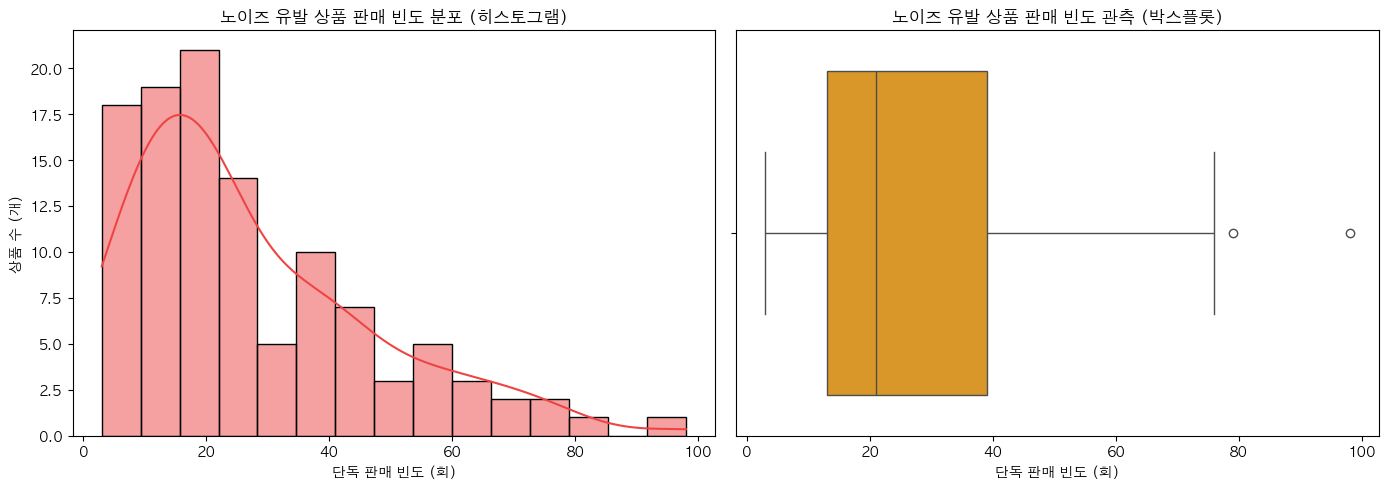

In [9]:
# 노이즈성 페어 109개의 판매 빈도 확인하기 
import os
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns

# ==========================================
# 0. 경로 및 환경 설정
# ==========================================
ROOT = r"/Users/hajiyoon/workspace/"
B2_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_상품단위변환전.parquet").strip()
B3_PATH = os.path.join(ROOT, "data", "processed", "B3_OLN_ODR_DLVR.parquet").strip()

# 기존 메모리의 final_npd, item_dict 변수를 공유합니다.
npd_list_qc = list(final_npd)

print("⏳ [1/3] Polars Lazy 파이프라인으로 노이즈 페어 상품 데이터 집계 중...")

# ==========================================
# 1. 퀵커머스 장바구니 및 페어 연산 파이프라인 (Lazy)
# ==========================================
b3_lazy = pl.scan_parquet(B3_PATH)
b3_keys = b3_lazy.with_columns([
    (pl.col("영업일자").cast(pl.Utf8) + "_" + pl.col("점포코드").cast(pl.Utf8) + "_" + 
     pl.col("POS번호").cast(pl.Utf8) + "_" + pl.col("거래번호").cast(pl.Utf8)).alias("거래_고유키")
]).select("거래_고유키").unique()

b2_lazy = pl.scan_parquet(B2_PATH)
b2_online = b2_lazy.join(b3_keys, on="거래_고유키", how="inner").with_columns(
    pl.col("상품코드").cast(pl.Utf8).str.strip_chars()
)

b3_npd_only = b2_online.filter(pl.col("상품코드").is_in(npd_list_qc)).select(["거래_고유키", "상품코드"]).unique()

# 상품별 단독 판매 빈도 (지모수) 계산
b3_item_counts = b3_npd_only.group_by("상품코드").agg(pl.len().alias("item_count"))

# 셀프 조인을 통한 조합 생성 및 [Support >= 3] 필터링
b3_pairs = b3_npd_only.join(b3_npd_only, on="거래_고유키", how="inner").filter(pl.col("상품코드") < pl.col("상품코드_right"))
b3_pair_counts = b3_pairs.group_by(["상품코드", "상품코드_right"]).agg(pl.len().alias("Support")).filter(pl.col("Support") >= 3)

# 지모수 결합
b3_N_lift = 12591
b3_pair_counts = b3_pair_counts.join(b3_item_counts, on="상품코드", how="left").rename({"item_count": "count_A"})
b3_pair_counts = b3_pair_counts.join(b3_item_counts, left_on="상품코드_right", right_on="상품코드", how="left").rename({"item_count": "count_B"})

# Lift 계산 및 과장 노이즈 페어 [Lift >= 50] 최종 필터링 후 수집
noise_pairs_lazy = b3_pair_counts.with_columns(
    (pl.col("Support") * b3_N_lift / (pl.col("count_A") * pl.col("count_B"))).alias("Lift")
).filter(pl.col("Lift") >= 50.0)

df_noise_pairs = noise_pairs_lazy.collect().to_pandas()

# ==========================================
# 2. 노이즈 상품들의 고유 판매 빈도(Frequency) 추출 및 정제
# ==========================================
print("⏳ [2/3] 노이즈 결합 품목들의 고유 판매 빈도 분포 추출 중...")

# 페어 내 상품 A와 상품 B의 빈도 데이터를 결합하여 고유 상품 기준으로 단일화
codes_A = df_noise_pairs[["상품코드", "count_A"]].rename(columns={"상품코드": "상품코드", "count_A": "판매빈도"})
codes_B = df_noise_pairs[["상품코드_right", "count_B"]].rename(columns={"상품코드_right": "상품코드", "count_B": "판매빈도"})

df_noise_items = pd.concat([codes_A, codes_B]).drop_duplicates(subset=["상품코드"]).reset_index(drop=True)
df_noise_items["상품명"] = df_noise_items["상품코드"].map(item_dict).fillna(df_noise_items["상품코드"])

# ==========================================
# 3. 기술통계량 및 세부 분위수 출력
# ==========================================
print("\n" + "="*60)
print("📊 [분석 결과] 노이즈 유발 상품들의 단독 판매 빈도 기술통계량")
print("="*60)
print(df_noise_items["판매빈도"].describe())
print("="*60)

print("\n💡 최소 판매 빈도 제약 조건 설정을 위한 세부 분위수:")
for q in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95]:
    print(f"   - 상위 {int((1-q)*100)}% 컷오프 지점 (하위 {int(q*100)}%): {df_noise_items['판매빈도'].quantile(q):.1f}회")
print("="*60)

print("\n🚨 분모를 축소시켜 Lift를 왜곡한 초희귀 상품 Top 10 명단:")
print(df_noise_items.sort_values(by="판매빈도").head(10)[["상품명", "판매빈도"]].to_string(index=False))
print("="*60 + "\n")

# ==========================================
# 4. 분포 시각화 챠트 가동 (히스토그램 & 박스플롯)
# ==========================================
print("⏳ [3/3] 분포 시각화 그래프 플롯 생성 중...")
plt.rc('font', family='AppleGothic') # MacOS 한글 깨짐 방지 서체 설정
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램 & 커널밀도추정(KDE)
sns.histplot(df_noise_items["판매빈도"], kde=True, bins=15, color='#EF4444', ax=axes[0])
axes[0].set_title("노이즈 유발 상품 판매 빈도 분포 (히스토그램)")
axes[0].set_xlabel("단독 판매 빈도 (회)")
axes[0].set_ylabel("상품 수 (개)")

# 박스플롯
sns.boxplot(x=df_noise_items["판매빈도"], color='#F59E0B', ax=axes[1])
axes[1].set_title("노이즈 유발 상품 판매 빈도 관측 (박스플롯)")
axes[1].set_xlabel("단독 판매 빈도 (회)")

plt.tight_layout()
plt.show()

In [11]:
import polars as pl

# ==========================================
# 1. 커널 내 사전 데이터를 활용한 Polars 매핑 딕셔너리 최적화
# ==========================================
# 상품코드를 기준으로 한 번에 매핑할 수 있도록 전처리 사전을 재구성합니다.
ip_code_dict = {code: "O" if is_ip_collab(name) else "X" for code, name in item_dict.items()}
cat_code_dict = {code: cat_dict.get(name, "알수없음") for code, name in item_dict.items()}

# ==========================================
# 2. 기저 페어 데이터 추출 파이프라인 (100% Lazy Mode)
# ==========================================
b3_lazy = pl.scan_parquet(B3_PATH)
b3_keys = b3_lazy.with_columns([
    (pl.col("영업일자").cast(pl.Utf8) + "_" + pl.col("점포코드").cast(pl.Utf8) + "_" + 
     pl.col("POS번호").cast(pl.Utf8) + "_" + pl.col("거래번호").cast(pl.Utf8)).alias("거래_고유키")
]).select("거래_고유키").unique()

b2_lazy = pl.scan_parquet(B2_PATH)
b2_online = b2_lazy.join(b3_keys, on="거래_고유키", how="inner").with_columns(
    pl.col("상품코드").cast(pl.Utf8).str.strip_chars()
)

npd_list_qc = list(final_npd)
b3_npd_only = b2_online.filter(pl.col("상품코드").is_in(npd_list_qc)).select(["거래_고유키", "상품코드"]).unique()
b3_item_counts = b3_npd_only.group_by("상품코드").agg(pl.len().alias("item_count"))

b3_pairs = b3_npd_only.join(b3_npd_only, on="거래_고유키", how="inner").filter(pl.col("상품코드") < pl.col("상품코드_right"))
b3_pair_counts = b3_pairs.group_by(["상품코드", "상품코드_right"]).agg(pl.len().alias("Support"))

# 고정 영수증 모수 N = 12,591 적용 및 Lift >= 1.5 통합 필터링
b3_N_lift = 12591
b3_pair_counts = b3_pair_counts.join(b3_item_counts, on="상품코드", how="left").rename({"item_count": "count_A"})
b3_pair_counts = b3_pair_counts.join(b3_item_counts, left_on="상품코드_right", right_on="상품코드", how="left").rename({"item_count": "count_B"})

pairs_base = b3_pair_counts.with_columns(
    (pl.col("Support") * b3_N_lift / (pl.col("count_A") * pl.col("count_B"))).alias("Lift")
).filter(pl.col("Lift") >= 1.5).collect()

# ==========================================
# 3. 요청 정보 매핑 및 컬럼명 변경 사양 동시 적용
# ==========================================
pairs_mapped = pairs_base.with_columns([
    pl.col("상품코드").replace(item_dict, default=pl.col("상품코드")).alias("상품명_A"),
    pl.col("상품코드_right").replace(item_dict, default=pl.col("상품코드_right")).alias("상품명_B"),
    pl.col("상품코드").replace(cat_code_dict, default="알수없음").alias("카테고리_A"),
    pl.col("상품코드_right").replace(cat_code_dict, default="알수없음").alias("카테고리_B"),
    pl.col("상품코드").replace(ip_code_dict, default="X").alias("IP여부_A"),
    pl.col("상품코드_right").replace(ip_code_dict, default="X").alias("IP여부_B")
]).rename({
    "count_A": "상품_A 단독 판매 빈도",
    "count_B": "상품_B 단독 판매 빈도"
})

# 출력 표준 컬럼 레이아웃 강제 지정
target_columns = [
    "상품명_A", "상품명_B", "카테고리_A", "카테고리_B", 
    "Support", "Lift", "상품_A 단독 판매 빈도", "상품_B 단독 판매 빈도", 
    "IP여부_A", "IP여부_B"
]
pairs_mapped = pairs_mapped.select(target_columns)

# ==========================================
# 4. 세 가지 페어 그룹 분리 정의
# ==========================================
group_A = pairs_mapped.filter(pl.col("Support") >= 3)
group_B = pairs_mapped.filter(pl.col("Support") == 2)
group_C = pairs_mapped.filter((pl.col("Support") >= 3) & (pl.col("Lift") >= 50.0))

# ==========================================
# 5. 그룹별 요약 통계 집계 및 출력 함수
# ==========================================
# ==========================================
# 5. 그룹별 요약 통계 집계 및 출력 함수 (오류 수정 버전)
# ==========================================
def display_group_summary(df, group_name):
    if len(df) == 0:
        print(f"\n📊 {group_name} 요약 통계: 조건 만족 데이터 없음")
        return
    
    # 💡 핵심 수정: 각 수식 뒤에 .alias()를 명시하여 컬럼명 중복 충돌을 원천 차단합니다.
    summary = df.select([
        pl.col("Support").mean().alias("avg_support"),
        pl.col("Lift").mean().alias("avg_lift"),
        pl.col("상품_A 단독 판매 빈도").mean().alias("avg_freq_a"),
        pl.col("상품_B 단독 판매 빈도").mean().alias("avg_freq_b"),
        (((pl.col("IP여부_A") == "O") | (pl.col("IP여부_B") == "O")).sum() / pl.len() * 100).alias("ip_ratio"),
        ((pl.col("카테고리_A") == pl.col("카테고리_B")).sum() / pl.len() * 100).alias("same_cat_ratio"),
        ((pl.col("카테고리_A") != pl.col("카테고리_B")).sum() / pl.len() * 100).alias("diff_cat_ratio")
    ]).row(0)
    
    print(f"\n📊 {group_name} 요약 통계 (총 {len(df):,}개 페어)")
    print(f"  - 평균 Support: {summary[0]:.2f}회")
    print(f"  - 평균 Lift: {summary[1]:.4f}")
    print(f"  - 평균 단독 판매 빈도 (A): {summary[2]:.2f}회")
    print(f"  - 평균 단독 판매 빈도 (B): {summary[3]:.2f}회")
    print(f"  - IP/콜라보 페어 비율: {summary[4]:.2f}% (둘 중 최소 하나 포함)")
    print(f"  - 동일 카테고리 내 페어 비율: {summary[5]:.2f}%")
    print(f"  - 다른 카테고리 간 페어 비율: {summary[6]:.2f}%")

print("="*60 + "\n[작업 1] 각 조건 그룹별 요약 통계 보고서\n" + "="*60)
display_group_summary(group_A, "그룹 A (Support >= 3, Lift >= 1.5)")
display_group_summary(group_B, "그룹 B (Support == 2, Lift >= 1.5)")
display_group_summary(group_C, "그룹 C (Support >= 3, Lift >= 50.0)")

# ==========================================
# 6. 난수 고정 기반 그룹별 샘플 리스트 출력
# ==========================================
print("\n" + "="*60 + "\n[작업 2] 도메인 검증용 그룹별 샘플 내역\n" + "="*60)

# 그룹 A: 랜덤 20개 샘플 (안전 슬라이싱 포함)
sample_A = group_A.sample(n=min(20, len(group_A)), seed=42) if len(group_A) > 0 else group_A
print(f"\n👑 그룹 A 랜덤 샘플 20개 (공통 통과, random_state=42):")
print(sample_A.to_pandas().to_string(index=False))

# 그룹 B: 랜덤 20개 샘플 (Support 3 장벽 탈락 페어)
sample_B = group_B.sample(n=min(20, len(group_B)), seed=42) if len(group_B) > 0 else group_B
print(f"\n⭐ 그룹 B 랜덤 샘플 20개 (Support 3 미만 탈락 구간, random_state=42):")
print(sample_B.to_pandas().to_string(index=False))

# 그룹 C: 조건 만족 전수 출력 (109개 대상)
print(f"\n🚨 그룹 C 전체 리스트 (노이즈 의심 페어 - 총 {len(group_C)}개):")
print(group_C.to_pandas().to_string(index=False))

/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_36412/3898566080.py:44: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)
  pl.col("상품코드").replace(item_dict, default=pl.col("상품코드")).alias("상품명_A"),
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_36412/3898566080.py:45: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)
  pl.col("상품코드_right").replace(item_dict, default=pl.col("상품코드_right")).alias("상품명_B"),
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_36412/3898566080.py:46: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)
  pl.col("상품코드").replace(cat_code_dict, default="알수없음").alias("카테고리_

[작업 1] 각 조건 그룹별 요약 통계 보고서

📊 그룹 A (Support >= 3, Lift >= 1.5) 요약 통계 (총 409개 페어)
  - 평균 Support: 7.13회
  - 평균 Lift: 60.8710
  - 평균 단독 판매 빈도 (A): 135.80회
  - 평균 단독 판매 빈도 (B): 80.59회
  - IP/콜라보 페어 비율: 44.25% (둘 중 최소 하나 포함)
  - 동일 카테고리 내 페어 비율: 57.21%
  - 다른 카테고리 간 페어 비율: 42.79%

📊 그룹 B (Support == 2, Lift >= 1.5) 요약 통계 (총 510개 페어)
  - 평균 Support: 2.00회
  - 평균 Lift: 67.2478
  - 평균 단독 판매 빈도 (A): 90.44회
  - 평균 단독 판매 빈도 (B): 66.43회
  - IP/콜라보 페어 비율: 36.47% (둘 중 최소 하나 포함)
  - 동일 카테고리 내 페어 비율: 36.27%
  - 다른 카테고리 간 페어 비율: 63.73%

📊 그룹 C (Support >= 3, Lift >= 50.0) 요약 통계 (총 109개 페어)
  - 평균 Support: 9.21회
  - 평균 Lift: 201.5829
  - 평균 단독 판매 빈도 (A): 34.89회
  - 평균 단독 판매 빈도 (B): 31.15회
  - IP/콜라보 페어 비율: 53.21% (둘 중 최소 하나 포함)
  - 동일 카테고리 내 페어 비율: 78.90%
  - 다른 카테고리 간 페어 비율: 21.10%

[작업 2] 도메인 검증용 그룹별 샘플 내역

👑 그룹 A 랜덤 샘플 20개 (공통 통과, random_state=42):
                상품명_A                   상품명_B 카테고리_A 카테고리_B  Support       Lift  상품_A 단독 판매 빈도  상품_B 단독 판매 빈도 IP여부_A IP여부_B
  KBO)롯데자이언츠거인단팥빵100g      PB)

/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_36412/3898566080.py:49: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)
  pl.col("상품코드_right").replace(ip_code_dict, default="X").alias("IP여부_B")


In [12]:
# 데이터에서 비식품 상품 제거하기
import os
import polars as pl

# ==========================================
# 0. 경로 설정 (기존 환경 경로 유지)
# ==========================================
ROOT = r"/Users/hajiyoon/workspace/"
B2_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_상품단위변환전.parquet").strip()
B4_PATH = os.path.join(ROOT, "data", "processed", "B4_ITEM_DV_INFO.parquet").strip()

# 정제된 데이터를 저장할 신규 경로 (안전을 위해 백업용 신규 파일로 저장 후 교체를 권장합니다)
B2_CLEANED_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_정제완료.parquet")

print("⏳ [1/3] 제거 대상 비식품 상품명 마스터 리스트 파싱 중...")

# ==========================================
# 1. 제거 대상 상품명 리스트 정리 (전달해주신 블록 공백 정제)
# ==========================================
raw_exclude_text = """
1뚱랑이)미니캐리어(핑크베이비
1뚱랑이)미니캐리어(핑크베이비)
1빵빵이)스마트폰거치대
1빵빵이)스마트폰거치대set
1빵빵이)태블릿파우치_네컷
1빵빵이)태블릿파우치_네컷set
1빵빵이)태블릿파우치_떡볶이
1빵빵이)태블릿파우치_떡볶이set
1테디베어)인형기획
1테디베어)인형기획
1테디베어)인형키링기획
1테디베어)인형키링기획
삼립)23년알찬피자호빵(찜기낱개
삼립)24년청기와타운매콤양념갈비호빵(찜기낱개)
삼립)25년감주통팥호빵(찜기낱개)
삼립)25년꿀고구마호빵(찜기낱개)
삼립)25년듬뿍피자호빵(찜기낱개)
삼립)25년생생야채호빵(찜기낱개)
삼립)25년정통단팥호빵(찜기낱개)
삼립)25년흑당단팥호빵(찜기낱개)
25설)몽탄우대갈비선물세트 
25설)삼진어묵프리미엄세트
25설)삼진어묵프리미엄세트
25설)이금선수산식품명인실속젓갈6종선물세트
25설)이금선수산식품명인실속젓갈6종선물세트
2디즈니)토이스토리수납함
2디즈니)토이스토리수납함set
2랏소베어)랜덤키링
2랏소베어)랜덤키링set
2랏소베어)마우스패드
2랏소베어)마우스패드set
2랏소베어)봉제키링
2랏소베어)봉제키링set
2랏소베어)얼굴쿠션
2랏소베어)얼굴쿠션set
2랏소베어)얼굴파우치
2랏소베어)얼굴파우치set
2산리오)네컷자석프레임기획(헬로키티
2산리오)네컷자석프레임기획(헬로키티)
2산리오)담요기획(헬로키티
2산리오)담요기획(헬로키티)
2산리오)마우스패드기획(시나모롤
2산리오)마우스패드기획(시나모롤)
2산리오)미니타포린백기획(마이멜로디
2산리오)미니타포린백기획(마이멜로디)
2산리오)손잡이텀블러기획(헬로키티
2산리오)손잡이텀블러기획(헬로키티)
2산리오)엠보스티커기획(시나모롤
2산리오)엠보스티커기획(시나모롤)
2산리오)인형키링기획
2산리오)인형키링기획
2산리오)퀼팅파우치기획(시나모롤
2산리오)퀼팅파우치기획(시나모롤)
2산리오)키캡키링기획(쿠로미
2산리오)키캡키링기획(쿠로미)
2산리오)투명파우치기획(쿠로미
2산리오)투명파우치기획(쿠로미)
2산리오)핸드타올기획(헬로키티
2산리오)핸드타올기획(헬로키티)
2유앤)산리오미니큐브(20입
2유앤)산리오미니큐브(20입)90g
3롯데)산리오3입기획
3롯데)산리오3입기획
3롯데)이정후포토카드4입기획
3롯데)이정후포토카드4입기획
3블루밍)러그
3블루밍)러그set
3블루밍)미니뿌인형키링set_브라운
3블루밍)미니뿌인형키링set_브라운
3블루밍)미니뿌인형키링set_화이트
3블루밍)미니뿌인형키링set_화이트
3블루밍)미니파우치
3블루밍)미니파우치set
3블루밍)스마트톡
3블루밍)스마트톡set
3블루밍)스티커기획
3블루밍)스티커기획set
3블루밍)자석카드지갑
3블루밍)자석카드지갑set
3빼빼로)말랑이기획
3빼빼로)말랑이기획
3산리오)동전지갑6입
3산리오)동전지갑6입
4산리오)공병
4산리오)공병set
4산리오)모둠쇼핑백(대
4산리오)모둠쇼핑백(대)
4산리오)모둠쇼핑백(소
4산리오)모둠쇼핑백(소)
4산리오)카드케이스
4산리오)카드케이스set
5해티)에코백
5해티)에코백
BIG 비엔나와 국내산 불고기를 담은 도시락
M_주사위껌미니보드게임
M_주사위껌미니보드게임
프로엠)NCTWISH기획세트
APP프로엠)NCTWISH기획세트
APP프로엠)NCTWISH기획세트
프로엠)NCTWISH기획세트
PB커피 카라멜마끼아또 등 5종
SF9화보매거진기획set
APP)SF9화보매거진기획set
V_1헬로키티)루프손잡이텀블러
V_1헬로키티)루프손잡이텀블러set
V_1헬로키티)사각키캡키링
V_1헬로키티)사각키캡키링set
V_1헬로키티)손잡이빨대텀블러
V_1헬로키티)손잡이빨대텀블러set
V_1헬로키티)손잡이수납파우치
V_1헬로키티)손잡이수납파우치set
V_1헬로키티)케익상자선물세트
V_1헬로키티)케익상자선물세트set
XXXL 졸음 번쩍껌 킹
여리수)기프트박스(소
여리수)기프트박스(소)
내몸애
다방커피오리지널헤이즐넛
삼립)단팥호빵(찜기낱개)
선우)딸기호랑이인형키링세트
선우)딸기호랑이인형키링세트
APP랏소베어)랜덤키링
APP랏소베어)랜덤키링set
맛있는 큰밥
동서)모카골드춘식이기획200T
★몽뜨)심쿵
★몽뜨)심쿵
★몽뜨)앤틱스타
APP블루밍)미니뿌인형키링set_브라운
APP블루밍)미니뿌인형키링set_브라운
APP블루밍)미니뿌인형키링set_화이트
APP블루밍)미니뿌인형키링set_화이트
★미루)골드벨(대)
★미루)골드벨(소)
★미루)골든트리
★미루)골든트리
★미루)그린라이트
★미루)그린라이트
★미루)러브로즈
★미루)러브로즈
★미루)러브로즈부케
★미루)러브로즈부케
★미루)러브미
★미루)러브미
★미루)러브밸리즈
★미루)러브스토리
★미루)러브스토리
★미루)러브스토리(미니
★미루)러브스토리(미니)
★미루)러브프렌즈
★미루)러브하우스
★미루)러브하우스
★미루)러브하트
★미루)러브하트
★미루)로맨틱(중)
★미루)로즈마리 
★미루)로즈원
★미루)물망초
★미루)베스트바구니 
★미루)베스트바구니
★미루)블링블링바구니
★미루)블링블링바구니 
★미루)블링블링바구니
★미루)빅하트
★미루)사각손잡이
★미루)사각손잡이
★미루)사랑비
★미루)사랑의원형볼
★미루)사랑의원형볼
★미루)사랑의프로포즈
★미루)원형부케
★미루)초코렛팩토리
★미루)초코렛팩토리
★미루)추억의책가방
★미루)추억의책가방
★미루)큐리티러브
★미루)토이페페
★미루)파스텔페페
★미루)페페플라워(소
★미루)페페플라워(소)
★미루)페페플라워(중
★미루)페페플라워(중)
★미루)프로포즈
★미루)프로포즈
★미루)플라워가든
★미루)플라워가든
★미루)해피토이
★미루)해피토이
분자
OKF)뷰티콜라겐
OKF)뷰티콜라겐350ml
농심)브레드이발소 스티커기획팩
농심)브레드이발소 스티커기획팩
★블링블링바구니
★블링블링바구니
APP)산리오인형키링기획
APP)산리오인형키링기획
여리수)선물박스(중
여리수)선물박스(중)
부창제과)소금우유호빵(찜기낱개)
소주류 (참이슬, 진로, 새로, 처음처럼 등)
여리수)쇼핑백세트(소
여리수)쇼핑백세트(소)
수피마티셔츠
프로엠)시나모롤인형키링(단품
프로엠)시나모롤인형키링(단품)
드림)시크릿주토피아
시크릿주토피아2
드림)시크릿주토피아2
아삭한 샐러드
안유성 명장 콜라보 4종
앙트레
야구장 크림
해티)에코백(단품
해티)에코백(단품)
엔요
★여리수)기프트머그컵
★여리수)레인보우캔디
★여리수)레인보우캔디
★여리수)로망스(중
★여리수)로망스(중)
★여리수)블링블링바구니
★여리수)블링블링바구니
★여리수)스윗원형볼
★여리수)스윗원형볼
★여리수)에이스부케
★여리수)에이스부케30000
★여리수)엔드리스하트
★여리수)여행을떠나요(중
★여리수)여행을떠나요(중)
★여리수)지관바구니25000
★여리수)피규어디스펜서
★여리수)하리보미니캐리어
★여리수)하리보미니캐리어
★여리수)하트로쉐플라워
★여리수)하트로쉐플라워
★여리수)하트부케
★여리수)하트부케12000
올데이온웜크루넥
자이언츠 월드컵
제로모히또제로카페인
여리수)젤리핑핸드폰가방(소
여리수)젤리핑핸드폰가방(소)
여리수)젤리핑핸드폰가방(중
여리수)젤리핑핸드폰가방(중)
농심)주토피아키링기획팩
농심)주토피아키링기획팩
중형캐리어_시나모롤(단품
중형캐리어_시나모롤(단품)
현성)즉석라면 용기
쿡인페이퍼)즉석라면용기
삼양휴텍)즉석라면원형용기(특수점전용)
골든)카발란디스틸러리셀렉트
캐치티니핑 블루핑크
프로엠)쿠로미인형키링(단품
프로엠)쿠로미인형키링(단품)
쿠로미키링(단품
쿠로미키링(단품)
테디베어 인형 세트
프로엠)테디베어인형(단품
프로엠)테디베어인형(단품)
APP)테디베어인형기획
APP)테디베어인형기획
스위트)트롤리어드벤트캘린더603g
티처스2 티셔츠 4종
파울라너바이스, 하이네켄, 마! 비어라 (3종)
롯데)허쉬키세스사각돌출케이스
롯데)허쉬키세스사각돌출케이스208g
롯데)허쉬키세스사각틴캔
롯데)허쉬키세스사각틴캔130g
롯데)허쉬키세스handbag케이스
롯데)허쉬키세스핸드백케이스156g
APP)헬로키티손잡이텀블러기획
APP)헬로키티손잡이텀블러기획
부창제과)호두단팥호빵(찜기낱개)
"""

exclude_names = set([line.strip() for line in raw_exclude_text.strip().split("\n") if line.strip()])

# ==========================================
# 2. 제거 대상 상품들의 '상품코드' 매핑 추적
# ==========================================
print("⏳ [2/3] item_dict 및 마스터 메타데이터에서 제거 대상 상품코드 추출 중...")

# 현재 활성화된 item_dict가 있다면 역추적하여 코드를 수집합니다.
exclude_codes = [code for code, name in item_dict.items() if name.strip() in exclude_names]

# 혹시 텍스트 공백 불일치로 누락되는 건을 방지하기 위해 B4 파일에서도 추가 교차 확인합니다.
b4_df = pl.read_parquet(B4_PATH)
if "ITEM_CD" in b4_df.columns:
    b4_df = b4_df.rename({"ITEM_CD": "상품코드", "ITEM_NM": "상품명"})

# 문자열을 전처리하여 매칭 확률을 극대화합니다.
b4_filtered_codes = b4_df.filter(
    pl.col("상품명").str.strip_chars().is_in(list(exclude_names))
).select("상품코드").to_series().to_list()

# 최종 제거 타겟 상품코드 세트 확정
final_exclude_codes = list(set(exclude_codes + b4_filtered_codes))
print(f"🎯 매핑 완료: 총 {len(final_exclude_codes):,}개의 비식품 상품코드가 격리되었습니다.")

# ==========================================
# 3. 오프라인 & 퀵커머스 공통 원천 마스터 필터링 수행 및 재저장
# ==========================================
print("\n⏳ [3/3] B2 마스터 Parquet 파일에서 해당 상품 데이터 제거 중...")

# 100% Lazy 모드로 메모리 점유 최소화하여 필터링 적용
b2_lazy_clean = pl.scan_parquet(B2_PATH).filter(
    ~pl.col("상품코드").cast(pl.Utf8).str.strip_chars().is_in(final_exclude_codes)
)

# 데이터프레임 강제 디스크 쓰기 수행
b2_lazy_clean.sink_parquet(B2_CLEANED_PATH)
print(f"✅ 데이터 정제 완료 및 물리 파일 저장 성공")
print(f"   ↳ 정제된 신규 파일 경로: {B2_CLEANED_PATH}")

# ==========================================
# 4. 메모리 내 글로벌 변수 동시 갱신 (네트워크 드로잉 연동용)
# ==========================================
# 현재 주피터 세션 내의 final_npd(NPD 목록)와 item_dict에서도 비식품 품목을 원천 삭제합니다.
final_npd = set(list(final_npd)) - set(final_exclude_codes)
for code in final_exclude_codes:
    item_dict.pop(code, None)

print(f"✅ 주피터 커널 메모리 동기화 완료 (갱신된 순수 식품 NPD 수: {len(final_npd):,}개)")
print("👉 이제 깨끗해진 데이터를 기반으로 최종 네트워크 시각화(HTML) 코드를 가동할 준비가 되었습니다.")

⏳ [1/3] 제거 대상 비식품 상품명 마스터 리스트 파싱 중...
⏳ [2/3] item_dict 및 마스터 메타데이터에서 제거 대상 상품코드 추출 중...
🎯 매핑 완료: 총 214개의 비식품 상품코드가 격리되었습니다.

⏳ [3/3] B2 마스터 Parquet 파일에서 해당 상품 데이터 제거 중...
✅ 데이터 정제 완료 및 물리 파일 저장 성공
   ↳ 정제된 신규 파일 경로: /Users/hajiyoon/workspace/data/processed/pos_data_food_final_정제완료.parquet
✅ 주피터 커널 메모리 동기화 완료 (갱신된 순수 식품 NPD 수: 2,337개)
👉 이제 깨끗해진 데이터를 기반으로 최종 네트워크 시각화(HTML) 코드를 가동할 준비가 되었습니다.


In [13]:
import os
import polars as pl

# ==========================================
# 0. 경로 설정
# ==========================================
ROOT = r"/Users/hajiyoon/workspace/"
OUTPUT_BASE_PAIRS_S2 = os.path.join(ROOT, "quick_commerce_base_pairs_s2.parquet")
OUTPUT_BASE_PAIRS_S2_CLEANED = os.path.join(ROOT, "quick_commerce_base_pairs_s2_정제완료.parquet")

print("⏳ 퀵커머스 페어 집계 파일에서 비식품 노이즈 라인 스크리닝 중...")

# ==========================================
# 1. 상품코드 및 상품코드_right 양쪽 모두에서 비식품 제거 (Lazy Mode)
# ==========================================
# 두 상품 중 하나라도 비식품 코드가 포함되어 있다면 네트워크 연결선에서 제외합니다.
pairs_lazy_clean = pl.scan_parquet(OUTPUT_BASE_PAIRS_S2).filter(
    (~pl.col("상품코드").cast(pl.Utf8).str.strip_chars().is_in(final_exclude_codes)) &
    (~pl.col("상품코드_right").cast(pl.Utf8).str.strip_chars().is_in(final_exclude_codes))
)

# 💡 정제된 퀵커머스 페어 데이터 디스크 물리 저장
pairs_lazy_clean.sink_parquet(OUTPUT_BASE_PAIRS_S2_CLEANED)

print(f"✅ 퀵커머스 집계 데이터 정제가 완료되었습니다.")
print(f"   ↳ 정제된 신규 페어 파일: {OUTPUT_BASE_PAIRS_S2_CLEANED}")

⏳ 퀵커머스 페어 집계 파일에서 비식품 노이즈 라인 스크리닝 중...
✅ 퀵커머스 집계 데이터 정제가 완료되었습니다.
   ↳ 정제된 신규 페어 파일: /Users/hajiyoon/workspace/quick_commerce_base_pairs_s2_정제완료.parquet


## 퀵커머스 기준 결정 후, 네트워크 그리기

In [15]:
import os
import pandas as pd
import networkx as nx
import polars as pl

# ==========================================
# 0. 경로 설정 및 정제 데이터 로드
# ==========================================
ROOT = r"/Users/hajiyoon/workspace/"
OUTPUT_BASE_PAIRS_S2_CLEANED = os.path.join(ROOT, "711project", "퀵커머스 데이터 EDA", "quick_commerce_base_pairs_s2_정제완료.parquet")
print("⏳ 정제된 최종 페어 데이터를 로드하여 네트워크 분석을 시작합니다...")
pairs_df = pl.read_parquet(OUTPUT_BASE_PAIRS_S2_CLEANED).to_pandas()

# ==========================================
# 1. NetworkX 그래프 빌드
# ==========================================
G_final = nx.Graph()

for _, row in pairs_df.iterrows():
    code_A = str(row["상품코드"]).strip()
    code_B = str(row["상품코드_right"]).strip()
    
    # item_dict 사전을 활용해 상품명으로 변환하여 에지 연결
    name_A = item_dict.get(code_A, code_A)
    name_B = item_dict.get(code_B, code_B)
    
    G_final.add_edge(name_A, name_B, weight=row["Support"], lift=row["Lift"])

# ==========================================
# 2. 네트워크 기본 토폴로지 지표 연산
# ==========================================
nodes_cnt = G_final.number_of_nodes()
edges_cnt = G_final.number_of_edges()
density = nx.density(G_final)

# ==========================================
# 3. 중심성 산출 및 q90(상위 10%) 기준점 정의
# ==========================================
deg_cent = nx.degree_centrality(G_final)
bet_cent = nx.betweenness_centrality(G_final, normalized=True)

deg_series = pd.Series(list(deg_cent.values()))
bet_series = pd.Series(list(bet_cent.values()))

thresh_deg = deg_series.quantile(0.90) if not deg_series.empty else 0
thresh_bet = bet_series.quantile(0.90) if not bet_series.empty else 0

# ==========================================
# 4. 4대 허브 유형별 노드 분류 및 카운팅
# ==========================================
a_cnt, b_cnt, c_cnt, d_cnt = 0, 0, 0, 0
a_nodes, b_nodes, c_nodes = [], [], []

for node in G_final.nodes():
    d_val = deg_cent[node]
    b_val = bet_cent[node]
    
    is_high_deg = d_val >= thresh_deg
    is_high_bet = b_val >= thresh_bet
    
    if is_high_deg and is_high_bet:
        a_cnt += 1
        a_nodes.append(node)
    elif is_high_deg and not is_high_bet:
        b_cnt += 1
        b_nodes.append(node)
    elif not is_high_deg and is_high_bet:
        c_cnt += 1
        c_nodes.append(node)
    else:
        d_cnt += 1

# ==========================================
# 5. 결과 리포트 출력
# ==========================================
print("\n" + "="*60)
print("📊 [최종 확정 조건] 퀵커머스 네트워크 기초 통계 리포트")
print("="*60)
print(f"📌 1. 네트워크 기본 규모")
print(f"  - 총 노드 수 (상품 수) : {nodes_cnt:,}개")
print(f"  - 총 엣지 수 (연결선 수): {edges_cnt:,}개")
print(f"  - 네트워크 밀도       : {density:.6f}")
print(f"  - 연결중심성 상위 10% 기준점 : {thresh_deg:.4f}")
print(f"  - 매개중심성 상위 10% 기준점 : {thresh_bet:.4f}")
print("-" * 60)
print(f"📌 2. 4대 허브 유형별 분포 현황")
print(f"  - A유형 (진짜 핵심 허브 - 둘 다 상위 10%): {a_cnt:^3}개 ({a_cnt/nodes_cnt*100:.2f}%)")
print(f"  - B유형 (인기 허브 - 연결만 상위 10%)    : {b_cnt:^3}개 ({b_cnt/nodes_cnt*100:.2f}%)")
print(f"  - C유형 (숨은 허브 - 매개만 상위 10%)    : {c_cnt:^3}개 ({c_cnt/nodes_cnt*100:.2f}%)")
print(f"  - D유형 (일반 노드 - 상위 10% 미만)      : {d_cnt:^3}개 ({d_cnt/nodes_cnt*100:.2f}%)")
print(f"  - 허브 합계 (A + B + C)                  : {a_cnt+b_cnt+c_cnt:^3}개 ({(a_cnt+b_cnt+c_cnt)/nodes_cnt*100:.2f}%)")
print(f"  - 실제 허브 대 나머지 비율               : 1 : {d_cnt/(a_cnt+b_cnt+c_cnt):.2f}")
print("="*60)

# 주요 핵심 허브 명단 선행 확인
print("\n👑 [참고] A유형(진짜 핵심 허브) 상품 명단 (일부):")
for idx, name in enumerate(a_nodes[:10]):
    print(f"  {idx+1}. {name}")
print("="*60)

⏳ 정제된 최종 페어 데이터를 로드하여 네트워크 분석을 시작합니다...

📊 [최종 확정 조건] 퀵커머스 네트워크 기초 통계 리포트
📌 1. 네트워크 기본 규모
  - 총 노드 수 (상품 수) : 331개
  - 총 엣지 수 (연결선 수): 914개
  - 네트워크 밀도       : 0.016735
  - 연결중심성 상위 10% 기준점 : 0.0394
  - 매개중심성 상위 10% 기준점 : 0.0181
------------------------------------------------------------
📌 2. 4대 허브 유형별 분포 현황
  - A유형 (진짜 핵심 허브 - 둘 다 상위 10%): 26 개 (7.85%)
  - B유형 (인기 허브 - 연결만 상위 10%)    :  8 개 (2.42%)
  - C유형 (숨은 허브 - 매개만 상위 10%)    :  8 개 (2.42%)
  - D유형 (일반 노드 - 상위 10% 미만)      : 289개 (87.31%)
  - 허브 합계 (A + B + C)                  : 42 개 (12.69%)
  - 실제 허브 대 나머지 비율               : 1 : 6.88

👑 [참고] A유형(진짜 핵심 허브) 상품 명단 (일부):
  1. 롯데)고기(肉)올인원도시락
  2. 해태)구운버터옥수수60g
  3. 크라운)비엔나야채타임60g
  4. 롯데)7찬도시락
  5. 롯데)햄참치샐러드샌드
  6. 이스타)도쿠시마라면큰컵
  7. 롯데)맛장우삼각더커진비빔참치
  8. PB)K리그슛!팅클별매콤달콤60g
  9. CJ)맥스봉고소한치즈후랑크65g
  10. 한도초과)고민할필요없는도시락


In [22]:
import os
import pandas as pd
import networkx as nx
import polars as pl
from pyvis.network import Network

# ==========================================
# 0. 경로 설정 및 정제 데이터 로드
# ==========================================
ROOT = r"/Users/hajiyoon/workspace/"
B2_CLEANED_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_정제완료.parquet")
OUTPUT_BASE_PAIRS_S2_CLEANED = os.path.join(ROOT, "711project", "퀵커머스 데이터 EDA", "quick_commerce_base_pairs_s2_정제완료.parquet")
HTML_OUTPUT_PATH = os.path.join(ROOT, "quick_commerce_network_final.html")

print("⏳ [1/4] 정제된 페어 데이터 및 전역 대중성 빈도 집계 중...")
pairs_df = pl.read_parquet(OUTPUT_BASE_PAIRS_S2_CLEANED).to_pandas()

b2_freq_df = pl.scan_parquet(B2_CLEANED_PATH).group_by("상품코드").agg(pl.len().alias("total_freq")).collect().to_pandas()
b2_freq_df["상품코드"] = b2_freq_df["상품코드"].astype(str).str.strip()
global_freq_dict = dict(zip(b2_freq_df["상품코드"], b2_freq_df["total_freq"]))

# ==========================================
# 1. NetworkX 기초 그래프 객체 빌드
# ==========================================
print("⏳ [2/4] NetworkX 구조 모델링 및 3대 중심성 연산 중...")
G = nx.Graph()

for _, row in pairs_df.iterrows():
    code_A = str(row["상품코드"]).strip()
    code_B = str(row["상품코드_right"]).strip()
    
    name_A = item_dict.get(code_A, code_A)
    name_B = item_dict.get(code_B, code_B)
    
    G.add_edge(name_A, name_B, weight=row["Support"], lift=row["Lift"], code_A=code_A, code_B=code_B)

deg_cent = nx.degree_centrality(G)
bet_cent = nx.betweenness_centrality(G, normalized=True)

deg_series = pd.Series(list(deg_cent.values()))
bet_series = pd.Series(list(bet_cent.values()))

thresh_deg = deg_series.quantile(0.90) if not deg_series.empty else 0
thresh_bet = bet_series.quantile(0.90) if not bet_series.empty else 0

# ==========================================
# 2. PyVis 인터랙티브 시각화 객체 매핑 및 스타일링
# ==========================================
print("⏳ [3/4] 4대 허브 유형별 디자인 가이드라인 투영 중...")
net = Network(height="1000px", width="1000px", bgcolor="#ffffff", font_color="#333333", notebook=False)

for node in G.nodes():
    d_val = deg_cent[node]
    b_val = bet_cent[node]
    
    node_code = None
    for _, _, d in G.edges(node, data=True):
        if item_dict.get(d['code_A']) == node or d['code_A'] == node:
            node_code = d['code_A']
            break
        elif item_dict.get(d['code_B']) == node or d['code_B'] == node:
            node_code = d['code_B']
            break

    raw_freq = global_freq_dict.get(node_code, 0)
    node_size = max(12, min(55, raw_freq * 0.005))
    
    is_high_deg = d_val >= thresh_deg
    is_high_bet = b_val >= thresh_bet
    
    if is_high_deg and is_high_bet:
        node_shape = "star"
        node_color = "#EAB308"
        node_label = f"{node} ⭐"
    elif is_high_deg and not is_high_bet:
        node_shape = "dot"
        node_color = "#EF4444"
        node_label = f"{node} 🔴"
    elif not is_high_deg and is_high_bet:
        node_shape = "dot"
        node_color = "#3B82F6"
        node_label = f"{node} 🔵"
    else:
        node_shape = "dot"
        node_color = "#10B981"
        node_label = node

    node_tooltip = f"상품명: {node}\n연결중심성: {d_val:.4f}\n매개중심성: {b_val:.4f}\n전체판매빈도: {raw_freq:,}회"
    net.add_node(node, label=node_label, size=node_size, color=node_color, shape=node_shape, title=node_tooltip)

for u, v, data in G.edges(data=True):
    edge_width = data["weight"]
    edge_tooltip = f"동반구매 빈도(Support): {data['weight']}회\n향상도(Lift): {data['lift']:.2f}"
    net.add_edge(u, v, value=edge_width, title=edge_tooltip, color="#CBD5E1")

# ==========================================
# 3. 💡 해결점: 자바스크립트 옵션에 configure 설정을 직접 주입
# ==========================================
# 별도의 메서드 호출 없이 상위 JSON 트리 구조에 직접 제어 옵션을 할당하여 에러를 방지합니다.
vis_options = """
var options = {
  "configure": {
    "enabled": true,
    "filter": ["physics"]
  },
  "nodes": {
    "borderWidth": 1.5,
    "borderWidthSelected": 3,
    "font": { "size": 13, "face": "AppleGothic", "align": "center" },
    "avoidOverlap": 1
  },
  "edges": {
    "color": { "inherit": false, "color": "#e2e8f0", "highlight": "#3b82f6" },
    "smooth": { "type": "continuous" }
  },
  "interaction": {
    "hover": true,
    "selectConnectedEdges": true,
    "navigationButtons": true,
    "dragNodes": true
  },
  "physics": {
    "barnesHut": {
      "gravitationalConstant": -50000,
      "centralGravity": 0.01,
      "springLength": 280,
      "springConstant": 0.01,
      "damping": 0.3
    },
    "minVelocity": 0.75
  }
}
"""
net.set_options(vis_options)

# ==========================================
# 4. HTML 파일 출력
# ==========================================
print(f"💾 [4/4] 최종 HTML 파일을 드라이브에 저장 중... 경로: {HTML_OUTPUT_PATH}")
net.save_graph(HTML_OUTPUT_PATH)

print("\n" + "="*60)
print("✅ [네트워크 웹 지도 생성 완료] 코드가 오류 없이 성공적으로 집행되었습니다.")
print(f"👉 파일 저장 경로: {HTML_OUTPUT_PATH}")
print("="*60)

⏳ [1/4] 정제된 페어 데이터 및 전역 대중성 빈도 집계 중...
⏳ [2/4] NetworkX 구조 모델링 및 3대 중심성 연산 중...
⏳ [3/4] 4대 허브 유형별 디자인 가이드라인 투영 중...
💾 [4/4] 최종 HTML 파일을 드라이브에 저장 중... 경로: /Users/hajiyoon/workspace/quick_commerce_network_final.html

✅ [네트워크 웹 지도 생성 완료] 코드가 오류 없이 성공적으로 집행되었습니다.
👉 파일 저장 경로: /Users/hajiyoon/workspace/quick_commerce_network_final.html


## 퀵커머스 ip,pb, 브랜드 여부 포함

In [23]:
import os
import pandas as pd
import networkx as nx
import polars as pl
from pyvis.network import Network

# ==========================================
# 0. 경로 설정 및 정제 데이터 로드
# ==========================================
ROOT = r"/Users/hajiyoon/workspace/"
B2_CLEANED_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_정제완료.parquet")
TARGET_PROD_XLSX = os.path.join(ROOT, "data", "processed", "target_product_cleaned.xlsx")

# 💡 사용자가 지정한 최신 정제 완료 페어 경로 반영
OUTPUT_BASE_PAIRS_S2_CLEANED = os.path.join(ROOT, "711project", "퀵커머스 데이터 EDA", "quick_commerce_base_pairs_s2_정제완료.parquet")
HTML_OUTPUT_PATH = os.path.join(ROOT, "711project", "퀵커머스 데이터 EDA", "quick_commerce_network_final.html")

print("⏳ [1/5] 정제된 페어 데이터 로드 및 신규 상품 속성(PB/IP) 마핑 중...")

# 1. 퀵커머스 페어 데이터프레임 로드
pairs_df = pl.read_parquet(OUTPUT_BASE_PAIRS_S2_CLEANED).to_pandas()

# 2. 💡 [신규 추가] target_product_cleaned.xlsx 마스터 로드 및 사전화
prod_meta_df = pd.read_excel(TARGET_PROD_XLSX)

# 컬럼명 표준화 (ITEM_CD 구조일 경우 상품코드로 통일)
if "ITEM_CD" in prod_meta_df.columns:
    prod_meta_df = prod_meta_df.rename(columns={"ITEM_CD": "상품코드"})
prod_meta_df["상품코드"] = prod_meta_df["상품코드"].astype(str).str.strip()

# 'y' 또는 'Y'인 상품코드를 세트(Set)로 격리하여 탐색 속도 극대화
pb_set = set(prod_meta_df[prod_meta_df["PB_YN"].str.lower() == "y"]["상품코드"].tolist())
ip_brand_set = set(prod_meta_df[prod_meta_df["IP_BRAND_YN"].str.lower() == "y"]["상품코드"].tolist())

# 3. 단독 판매 빈도 산출 (Polars Lazy 파이프라인)
b2_freq_df = pl.scan_parquet(B2_CLEANED_PATH).group_by("상품코드").agg(pl.len().alias("total_freq")).collect().to_pandas()
b2_freq_df["상품코드"] = b2_freq_df["상품코드"].astype(str).str.strip()
global_freq_dict = dict(zip(b2_freq_df["상품코드"], b2_freq_df["total_freq"]))

# ==========================================
# 1. NetworkX 기초 그래프 객체 빌드
# ==========================================
print("⏳ [2/5] NetworkX 구조 모델링 및 3대 중심성 연산 중...")
G = nx.Graph()

for _, row in pairs_df.iterrows():
    code_A = str(row["상품코드"]).strip()
    code_B = str(row["상품코드_right"]).strip()
    
    name_A = item_dict.get(code_A, code_A)
    name_B = item_dict.get(code_B, code_B)
    
    G.add_edge(name_A, name_B, weight=row["Support"], lift=row["Lift"], code_A=code_A, code_B=code_B)

deg_cent = nx.degree_centrality(G)
bet_cent = nx.betweenness_centrality(G, normalized=True)

deg_series = pd.Series(list(deg_cent.values()))
bet_series = pd.Series(list(bet_cent.values()))

thresh_deg = deg_series.quantile(0.90) if not deg_series.empty else 0
thresh_bet = bet_series.quantile(0.90) if not bet_series.empty else 0

# ==========================================
# 2. PyVis 인터랙티브 시각화 객체 매핑 및 스타일링
# ==========================================
print("⏳ [3/5] 4대 허브 유형별 디자인 가이드라인 및 확장 속성 투영 중...")
net = Network(height="1000px", width="1000px", bgcolor="#ffffff", font_color="#333333", notebook=False)

for node in G.nodes():
    d_val = deg_cent[node]
    b_val = bet_cent[node]
    
    # 연결선 역추적을 통한 상품코드 도출
    node_code = None
    for _, _, d in G.edges(node, data=True):
        if item_dict.get(d['code_A']) == node or d['code_A'] == node:
            node_code = d['code_A']
            break
        elif item_dict.get(d['code_B']) == node or d['code_B'] == node:
            node_code = d['code_B']
            break

    # 판매 빈도 크기 스케일링
    raw_freq = global_freq_dict.get(node_code, 0)
    node_size = max(12, min(55, raw_freq * 0.005))
    
    # 💡 [신규 추가] 현재 노드 상품의 PB 여부 및 IP 브랜드 여부 판별
    is_pb_status = "O" if node_code in pb_set else "X"
    is_ip_brand_status = "O" if node_code in ip_brand_set else "X"
    
    # 4대 허브 판별 규칙
    is_high_deg = d_val >= thresh_deg
    is_high_bet = b_val >= thresh_bet
    
    if is_high_deg and is_high_bet:
        node_shape = "star"
        node_color = "#EAB308"
        node_label = f"{node} ⭐"
    elif is_high_deg and not is_high_bet:
        node_shape = "dot"
        node_color = "#EF4444"
        node_label = f"{node} 🔴"
    elif not is_high_deg and is_high_bet:
        node_shape = "dot"
        node_color = "#3B82F6"
        node_label = f"{node} 🔵"
    else:
        node_shape = "dot"
        node_color = "#10B981"
        node_label = node

    # 💡 [신규 추가] 마우스 오버 툴팁 내에 PB 및 IP_BRAND 정보 포맷팅 결합
    node_tooltip = (
        f"상품명: {node}\n"
        f"연결중심성: {d_val:.4f}\n"
        f"매개중심성: {b_val:.4f}\n"
        f"전체판매빈도: {raw_freq:,}회\n"
        f"-------------------------\n"
        f"▶ PB 상품 여부: {is_pb_status}\n"
        f"▶ IP 브랜드 여부: {is_ip_brand_status}"
    )
    net.add_node(node, label=node_label, size=node_size, color=node_color, shape=node_shape, title=node_tooltip)

for u, v, data in G.edges(data=True):
    edge_width = data["weight"]
    edge_tooltip = f"동반구매 빈도(Support): {data['weight']}회\n향상도(Lift): {data['lift']:.2f}"
    net.add_edge(u, v, value=edge_width, title=edge_tooltip, color="#CBD5E1")

# ==========================================
# 3. 인터랙션 및 겹침 방지 물리 엔진 설정 (Configure 통합형)
# ==========================================
vis_options = """
var options = {
  "configure": {
    "enabled": true,
    "filter": ["physics"]
  },
  "nodes": {
    "borderWidth": 1.5,
    "borderWidthSelected": 3,
    "font": { "size": 13, "face": "AppleGothic", "align": "center" },
    "avoidOverlap": 1
  },
  "edges": {
    "color": { "inherit": false, "color": "#e2e8f0", "highlight": "#3b82f6" },
    "smooth": { "type": "continuous" }
  },
  "interaction": {
    "hover": true,
    "selectConnectedEdges": true,
    "navigationButtons": true,
    "dragNodes": true
  },
  "physics": {
    "barnesHut": {
      "gravitationalConstant": -50000,
      "centralGravity": 0.01,
      "springLength": 280,
      "springConstant": 0.01,
      "damping": 0.3
    },
    "minVelocity": 0.75
  }
}
"""
net.set_options(vis_options)

# ==========================================
# 4. HTML 파일 출력
# ==========================================
print(f"💾 [4/5] 지정된 경로에 인터랙티브 웹 지도 저장 중...")
os.makedirs(os.path.dirname(HTML_OUTPUT_PATH), exist_ok=True)
net.save_graph(HTML_OUTPUT_PATH)

print("\n" + "="*60)
print("✅ [업데이트 완료] 신규 속성이 융합된 네트워크 지도가 빌드되었습니다.")
print(f"  - 총 노드 수: {G.number_of_nodes()}개")
print(f"  - 총 엣지 수: {G.number_of_edges()}개")
print(f"👉 저장된 HTML 파일 위치를 확인하세요:")
print(f"   ↳ {HTML_OUTPUT_PATH}")
print("="*60)

⏳ [1/5] 정제된 페어 데이터 로드 및 신규 상품 속성(PB/IP) 마핑 중...
⏳ [2/5] NetworkX 구조 모델링 및 3대 중심성 연산 중...
⏳ [3/5] 4대 허브 유형별 디자인 가이드라인 및 확장 속성 투영 중...
💾 [4/5] 지정된 경로에 인터랙티브 웹 지도 저장 중...

✅ [업데이트 완료] 신규 속성이 융합된 네트워크 지도가 빌드되었습니다.
  - 총 노드 수: 331개
  - 총 엣지 수: 914개
👉 저장된 HTML 파일 위치를 확인하세요:
   ↳ /Users/hajiyoon/workspace/711project/퀵커머스 데이터 EDA/quick_commerce_network_final.html


In [24]:
import os
import pandas as pd
import networkx as nx
import polars as pl
import numpy as np

# ==========================================
# 0. 경로 설정 및 정제 데이터 로드
# ==========================================
ROOT = r"/Users/hajiyoon/workspace/"
TARGET_PROD_XLSX = os.path.join(ROOT, "data", "processed", "target_product_cleaned.xlsx")
OUTPUT_BASE_PAIRS_S2_CLEANED = os.path.join(ROOT, "711project", "퀵커머스 데이터 EDA", "quick_commerce_base_pairs_s2_정제완료.parquet")

print("⏳ [1/3] 정제 페어 데이터 및 상품 매스터 속성 정밀 결합 중...")

# 1. 데이터 로드 및 전처리
pairs_df = pl.read_parquet(OUTPUT_BASE_PAIRS_S2_CLEANED).to_pandas()
prod_meta_df = pd.read_excel(TARGET_PROD_XLSX)

if "ITEM_CD" in prod_meta_df.columns:
    prod_meta_df = prod_meta_df.rename(columns={"ITEM_CD": "상품코드"})
prod_meta_df["상품코드"] = prod_meta_df["상품코드"].astype(str).str.strip()

# 속성 매핑을 위한 딕셔너리 빌드 (대소문자 정제 포함)
pb_map = dict(zip(prod_meta_df["상품코드"], prod_meta_df["PB_YN"].astype(str).str.lower() == "y"))
ip_map = dict(zip(prod_meta_df["상품코드"], prod_meta_df["IP_BRAND_YN"].astype(str).str.lower() == "y"))

# ==========================================
# 1. NetworkX 그래프 생성 및 노드 속성 주입
# ==========================================
G_analysis = nx.Graph()

for _, row in pairs_df.iterrows():
    code_A = str(row["상품코드"]).strip()
    code_B = str(row["상품코드_right"]).strip()
    
    name_A = item_dict.get(code_A, code_A)
    name_B = item_dict.get(code_B, code_B)
    
    # 에지 추가
    G_analysis.add_edge(name_A, name_B, weight=row["Support"], lift=row["Lift"])
    
    # 노드 속성 실시간 주입 (기존 커널의 cat_code_dict 활용)
    G_analysis.nodes[name_A]["code"] = code_A
    G_analysis.nodes[name_A]["is_pb"] = pb_map.get(code_A, False)
    G_analysis.nodes[name_A]["is_ip"] = ip_map.get(code_A, False)
    G_analysis.nodes[name_A]["category"] = cat_code_dict.get(code_A, "알수없음")
    
    G_analysis.nodes[name_B]["code"] = code_B
    G_analysis.nodes[name_B]["is_pb"] = pb_map.get(code_B, False)
    G_analysis.nodes[name_B]["is_ip"] = ip_map.get(code_B, False)
    G_analysis.nodes[name_B]["category"] = cat_code_dict.get(code_B, "알수없음")

# ==========================================
# 2. 구조 및 거시 토폴로지 분석 계산
# ==========================================
print("⏳ [2/3] 거시 토폴로지 지표 및 4대 허브 프로파일링 스크리닝 중...")
nodes_cnt = G_analysis.number_of_nodes()
edges_cnt = G_analysis.number_of_edges()
density = nx.density(G_analysis)
avg_clustering = nx.average_clustering(G_analysis)
connected_components = nx.number_connected_components(G_analysis)

# 지표 스코어 산출
deg_cent = nx.degree_centrality(G_analysis)
bet_cent = nx.betweenness_centrality(G_analysis, normalized=True)
deg_series = pd.Series(list(deg_cent.values()))
bet_series = pd.Series(list(bet_cent.values()))
thresh_deg = deg_series.quantile(0.90)
thresh_bet = bet_series.quantile(0.90)

# ==========================================
# 3. 4대 허브 유형별 속성 크로스 집계
# ==========================================
hub_profiles = {"A": [], "B": [], "C": [], "D": []}

for node in G_analysis.nodes():
    d_val = deg_cent[node]
    b_val = bet_cent[node]
    attrs = G_analysis.nodes[node]
    
    is_high_deg = d_val >= thresh_deg
    is_high_bet = b_val >= thresh_bet
    
    node_info = {
        "name": node,
        "is_pb": attrs.get("is_pb", False),
        "is_ip": attrs.get("is_ip", False),
        "category": attrs.get("category", "알수없음")
    }
    
    if is_high_deg and is_high_bet:
        hub_profiles["A"].append(node_info)
    elif is_high_deg and not is_high_bet:
        hub_profiles["B"].append(node_info)
    elif not is_high_deg and is_high_bet:
        hub_profiles["C"].append(node_info)
    else:
        hub_profiles["D"].append(node_info)

# ==========================================
# 4. 에지(연결선) 속성 및 조합 결합 분석
# ==========================================
print("⏳ [3/3] 에지 인터랙션 및 카테고리 믹스 매트릭스 도출 중...")
cross_cat_count = 0
pb_pb_count, pb_nb_count, nb_nb_count = 0, 0, 0
ip_ip_count, ip_nb_count, nb_ip_count = 0, 0, 0 # IP 결합 패턴용

for u, v, data in G_analysis.edges(data=True):
    cat_u = G_analysis.nodes[u].get("category")
    cat_v = G_analysis.nodes[v].get("category")
    
    if cat_u != cat_v:
        cross_cat_count += 1
        
    pb_u = G_analysis.nodes[u].get("is_pb")
    pb_v = G_analysis.nodes[v].get("is_pb")
    
    if pb_u and pb_v:
        pb_pb_count += 1
    elif (pb_u and not pb_v) or (not pb_u and pb_v):
        pb_nb_count += 1
    else:
        nb_nb_count += 1

# ==========================================
# 5. 심층 구조 분석 결과 보고서 출력
# ==========================================
print("\n" + "="*80)
print("📊 퀵커머스 장바구니 네트워크 심층 분석 결과 보고서 ($Support \ge 2$)")
print("="*80)

print(f"[PART 1. 거시적 네트워크 구조 지표]")
print(f"  - 전체 노드 수 (상품 수)       : {nodes_cnt}개")
print(f"  - 전체 엣지 수 (연결 관계 수)   : {edges_cnt}개")
print(f"  - 네트워크 밀도 (Density)      : {density:.5f}")
print(f"  - 평균 군집 계수 (Clustering)  : {avg_clustering:.5f}")
print(f"  - 독립 컴포넌트(파편 그래프) 수: {connected_components}개")
print("-" * 80)

print(f"[PART 2. 4대 허브 유형별 PB / IP 상품 세부 프로필]")
for h_type, items in hub_profiles.items():
    t_cnt = len(items)
    if t_cnt == 0:
        print(f"  - {h_type}유형 허브: 존재하지 않음")
        continue
    
    pb_cnt = sum(1 for x in items if x["is_pb"])
    ip_cnt = sum(1 for x in items if x["is_ip"])
    
    # 카테고리 분포 요약
    cats = pd.Series([x["category"] for x in items]).value_counts()
    top_cat = cats.index[0] if not cats.empty else "없음"
    top_cat_cnt = cats.values[0] if not cats.empty else 0
    
    type_nm = {
        "A": "진짜 핵심 허브 (Degree & Betweenness 상위 10%)",
        "B": "인기 중심 허브 (Degree 상위 10%)",
        "C": "숨은 매개 허브 (Betweenness 상위 10%)",
        "D": "일반 상품 노드 (상위 10% 미만)"
    }[h_type]
    
    print(f"  💡 {h_type}유형 : {type_nm}")
    print(f"    · 총 노드 수 : {t_cnt}개 (비율: {t_cnt/nodes_cnt*100:.2f}%)")
    print(f"    · PB 상품 수 : {pb_cnt}개 (내부 비율: {pb_cnt/t_cnt*100:.2f}%)")
    print(f"    · IP 상품 수 : {ip_cnt}개 (내부 비율: {ip_cnt/t_cnt*100:.2f}%)")
    print(f"    · 최다 카테고리: {top_cat} ({top_cat_cnt}개)")
    print(f"    · 소속 상품 샘플: {', '.join([x['name'] for x in items[:3]])} ...")
    print("    " + "."*70)

print("-" * 80)
print(f"[PART 3. 에지(Edge) 연결선 결합 패턴 및 크로스 분석]")
print(f"  - 교차 카테고리(Cross-Category) 연결선 수 : {cross_cat_count}개 (전체의 {cross_cat_count/edges_cnt*100:.2f}%)")
print(f"  - 동일 카테고리(Intra-Category) 연결선 수 : {edges_cnt - cross_cat_count}개 (전체의 {(edges_cnt - cross_cat_count)/edges_cnt*100:.2f}%)")
print(f"  - PB 상품 간 결합 구조 비율 분석:")
print(f"    · PB ↔ PB (자사 상품 간 시너지)         : {pb_pb_count}개 ({pb_pb_count/edges_cnt*100:.2f}%)")
print(f"    · PB ↔ NB (자사-일반 상품 간 연계)      : {pb_nb_count}개 ({pb_nb_count/edges_cnt*100:.2f}%)")
print(f"    · NB ↔ NB (일반 상품 간 독립 결합)      : {nb_nb_count}개 ({nb_nb_count/edges_cnt*100:.2f}%)")
print("="*80)

<>:130: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:130: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_36412/820057664.py:130: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  print("📊 퀵커머스 장바구니 네트워크 심층 분석 결과 보고서 ($Support \ge 2$)")


⏳ [1/3] 정제 페어 데이터 및 상품 매스터 속성 정밀 결합 중...
⏳ [2/3] 거시 토폴로지 지표 및 4대 허브 프로파일링 스크리닝 중...
⏳ [3/3] 에지 인터랙션 및 카테고리 믹스 매트릭스 도출 중...

📊 퀵커머스 장바구니 네트워크 심층 분석 결과 보고서 ($Support \ge 2$)
[PART 1. 거시적 네트워크 구조 지표]
  - 전체 노드 수 (상품 수)       : 331개
  - 전체 엣지 수 (연결 관계 수)   : 914개
  - 네트워크 밀도 (Density)      : 0.01674
  - 평균 군집 계수 (Clustering)  : 0.27362
  - 독립 컴포넌트(파편 그래프) 수: 20개
--------------------------------------------------------------------------------
[PART 2. 4대 허브 유형별 PB / IP 상품 세부 프로필]
  💡 A유형 : 진짜 핵심 허브 (Degree & Betweenness 상위 10%)
    · 총 노드 수 : 26개 (비율: 7.85%)
    · PB 상품 수 : 17개 (내부 비율: 65.38%)
    · IP 상품 수 : 8개 (내부 비율: 30.77%)
    · 최다 카테고리: 스낵류 (7개)
    · 소속 상품 샘플: 롯데)고기(肉)올인원도시락, 해태)구운버터옥수수60g, 크라운)비엔나야채타임60g ...
    ......................................................................
  💡 B유형 : 인기 중심 허브 (Degree 상위 10%)
    · 총 노드 수 : 8개 (비율: 2.42%)
    · PB 상품 수 : 7개 (내부 비율: 87.50%)
    · IP 상품 수 : 2개 (내부 비율: 25.00%)
    · 최다 카테고리: 샌드위치 (3개)
    · 소속 상품 샘플: 롯데)칠리불새버거, 롯데)햄치즈에그토스트샌드, 한도

In [28]:
# csv에 저장하기
import os
import pandas as pd
import networkx as nx
import polars as pl

# ==========================================
# 0. 경로 설정 및 정제 데이터 로드
# ==========================================
ROOT = r"/Users/hajiyoon/workspace/"
TARGET_PROD_XLSX = os.path.join(ROOT, "data", "processed", "target_product_cleaned.xlsx")

# 최신 퀵커머스 정제 완료 페어 파일 경로
OUTPUT_BASE_PAIRS_S2_CLEANED = os.path.join(ROOT, "711project", "퀵커머스 데이터 EDA", "quick_commerce_base_pairs_s2_정제완료.parquet")

# 최종 CSV 결과물 저장 경로
CSV_OUTPUT_PATH = os.path.join(ROOT, "711project", "퀵커머스 데이터 EDA", "quick_commerce_product_centrality_matrix.csv")

print("⏳ [1/4] 정제 페어 데이터 및 최신 상품 마스터 속성(PB/IP) 로드 중...")

# 1. 데이터 로드 및 속성 매핑 사전 구축
pairs_df = pl.read_parquet(OUTPUT_BASE_PAIRS_S2_CLEANED).to_pandas()
prod_meta_df = pd.read_excel(TARGET_PROD_XLSX)

if "ITEM_CD" in prod_meta_df.columns:
    prod_meta_df = prod_meta_df.rename(columns={"ITEM_CD": "상품코드"})
prod_meta_df["상품코드"] = prod_meta_df["상품코드"].astype(str).str.strip()

# 속성 역추적을 위한 매핑 딕셔너리 빌드 (대소문자 무관하게 y/Y 판단)
pb_map = dict(zip(prod_meta_df["상품코드"], prod_meta_df["PB_YN"].astype(str).str.lower() == "y"))
ip_map = dict(zip(prod_meta_df["상품코드"], prod_meta_df["IP_BRAND_YN"].astype(str).str.lower() == "y"))

# ==========================================
# 1. NetworkX 그래프 생성
# ==========================================
print("⏳ [2/4] NetworkX 그래프 모델링 생성 중...")
G_qc = nx.Graph()

for _, row in pairs_df.iterrows():
    code_A = str(row["상품코드"]).strip()
    code_B = str(row["상품코드_right"]).strip()
    
    name_A = item_dict.get(code_A, code_A)
    name_B = item_dict.get(code_B, code_B)
    
    # 그래프 에지 연결 및 상품코드 보존
    G_qc.add_edge(name_A, name_B, weight=row["Support"], lift=row["Lift"])
    G_qc.nodes[name_A]["code"] = code_A
    G_qc.nodes[name_B]["code"] = code_B

# ==========================================
# 2. 전역 중심성 연산 및 상위 10% 임계점 도출
# ==========================================
print("⏳ [3/4] 연결중심성 및 매개중심성 정밀 연산 중...")
deg_cent = nx.degree_centrality(G_qc)
bet_cent = nx.betweenness_centrality(G_qc, normalized=True)

deg_series = pd.Series(list(deg_cent.values()))
bet_series = pd.Series(list(bet_cent.values()))

thresh_deg = deg_series.quantile(0.90) if not deg_series.empty else 0
thresh_bet = bet_series.quantile(0.90) if not bet_series.empty else 0

# ==========================================
# 3. 상품별 마스터 매트릭스 데이터프레임 빌드
# ==========================================
matrix_data = []

for node in G_qc.nodes():
    node_code = G_qc.nodes[node].get("code", "")
    
    d_val = deg_cent[node]
    b_val = bet_cent[node]
    
    # 두 중심성이 모두 상위 10% 이상인지 판별 (A유형 허브 조건)
    is_high_deg = d_val >= thresh_deg
    is_high_bet = b_val >= thresh_bet
    is_core_hub = "Y" if (is_high_deg and is_high_bet) else "N"
    
    # 비즈니스 속성 매핑 (O/X 처리)
    is_pb = "O" if pb_map.get(node_code, False) else "X"
    is_ip = "O" if ip_map.get(node_code, False) else "X"
    
    # 카테고리 정보 추출
    category_nm = cat_code_dict.get(node_code, "알수없음")
    
    matrix_data.append({
        "상품코드": node_code,
        "상품명": node,
        "중분류카테고리": category_nm,
        "연결중심성": round(d_val, 6),
        "매개중심성": round(b_val, 6),
        "핵심허브여부_상위10%": is_core_hub,
        "PB여부": is_pb,
        "IP브랜드여부": is_ip
    })

# 데이터프레임 변환 후 중심성 순 정렬
result_matrix_df = pd.DataFrame(matrix_data)
result_matrix_df = result_matrix_df.sort_values(by=["연결중심성", "매개중심성"], ascending=False).reset_index(drop=True)

# ==========================================
# 4. CSV 파일 출력 및 검증 리포트
# ==========================================
print(f"💾 [4/4] 최종 퀵커머스 마스터 매트릭스를 CSV로 내보내는 중...")
os.makedirs(os.path.dirname(CSV_OUTPUT_PATH), exist_ok=True)
result_matrix_df.to_csv(CSV_OUTPUT_PATH, index=False, encoding="utf-8-sig")

print("\n" + "="*80)
print("✅ [CSV 생성 완료] 퀵커머스 데이터 매트릭스 빌드가 종료되었습니다.")
print(f"  - 총 저장된 상품(노드) 수: {len(result_matrix_df):,}개")
print(f"  - 이 중 핵심 허브(A유형) 수: {sum(result_matrix_df['핵심허브여부_상위10%'] == 'Y')}개")
print(f"👉 파일 저장 위치:")
print(f"   ↳ {CSV_OUTPUT_PATH}")
print("="*80)

⏳ [1/4] 정제 페어 데이터 및 최신 상품 마스터 속성(PB/IP) 로드 중...
⏳ [2/4] NetworkX 그래프 모델링 생성 중...
⏳ [3/4] 연결중심성 및 매개중심성 정밀 연산 중...
💾 [4/4] 최종 퀵커머스 마스터 매트릭스를 CSV로 내보내는 중...

✅ [CSV 생성 완료] 퀵커머스 데이터 매트릭스 빌드가 종료되었습니다.
  - 총 저장된 상품(노드) 수: 331개
  - 이 중 핵심 허브(A유형) 수: 26개
👉 파일 저장 위치:
   ↳ /Users/hajiyoon/workspace/711project/퀵커머스 데이터 EDA/quick_commerce_product_centrality_matrix.csv


# 오프라인 포스 네트워크

In [ ]:
# 오프라인 네트워크 그리기

import os
import pandas as pd
import networkx as nx
import polars as pl
from pyvis.network import Network

# ==========================================
# 0. 경로 설정 및 파일 로드
# ==========================================
ROOT = r"/Users/hajiyoon/workspace/"
B2_CLEANED_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_정제완료.parquet")
TARGET_PROD_XLSX = os.path.join(ROOT, "data", "processed", "target_product_cleaned.xlsx")
HTML_OUTPUT_PATH = os.path.join(ROOT, "711project", "오프라인 포스 데이터 분석", "offline_pos_network_final.html")

print("⏳ [1/5] 대용량 오프라인 POS 데이터 기반 고속 Lazy 페어 연산 및 모수 산출 시작...")

# 1. PB / IP 브랜드 매스터 데이터 로드 및 사전화
prod_meta_df = pd.read_excel(TARGET_PROD_XLSX)
if "ITEM_CD" in prod_meta_df.columns:
    prod_meta_df = prod_meta_df.rename(columns={"ITEM_CD": "상품코드"})
prod_meta_df["상품코드"] = prod_meta_df["상품코드"].astype(str).str.strip()

pb_set = set(prod_meta_df[prod_meta_df["PB_YN"].str.lower() == "y"]["상품코드"].tolist())
ip_brand_set = set(prod_meta_df[prod_meta_df["IP_BRAND_YN"].str.lower() == "y"]["상품코드"].tolist())

# 2. Polars Lazy 엔진 기반 오프라인 총 영수증 수(N) 동적 계산
b2_lazy = pl.scan_parquet(B2_CLEANED_PATH)
N_offline = b2_lazy.select(pl.col("거래_고유키").n_unique()).collect().item()
print(f"   ↳ 분석 대상 전체 오프라인 영수증 모수(N) : {N_offline:,}건")

# 3. 메모리 내 순수 식품 NPD 리스트 연동 및 장바구니 추출
npd_list = list(final_npd)
b2_npd_lazy = b2_lazy.filter(pl.col("상품코드").is_in(npd_list)).select(["거래_고유키", "상품코드"]).unique()

# 상품별 단독 판매 빈도(지모수) 및 노드 스케일링용 빈도 사전 산출
b2_freq_df = b2_lazy.group_by("상품코드").agg(pl.len().alias("total_freq")).collect().to_pandas()
b2_freq_df["상품코드"] = b2_freq_df["상품코드"].astype(str).str.strip()
global_freq_dict = dict(zip(b2_freq_df["상품코드"], b2_freq_df["total_freq"]))

# 4. 셀프 조인을 통한 오프라인 페어링 연산 및 [Support >= 5] 기저 필터링
pairs_lazy = b2_npd_lazy.join(b2_npd_lazy, on="거래_고유키", how="inner").filter(pl.col("상품코드") < pl.col("상품코드_right"))
pair_counts_lazy = pairs_lazy.group_by(["상품코드", "상품코드_right"]).agg(pl.len().alias("Support")).filter(pl.col("Support") >= 5)

# 지모수 결합 및 [Lift >= 1.5] 최종 스크리닝 진행 후 Pandas 변환
b2_item_counts = b2_npd_lazy.group_by("상품코드").agg(pl.len().alias("item_count"))
pair_counts_lazy = pair_counts_lazy.join(b2_item_counts, on="상품코드", how="left").rename({"item_count": "count_A"})
pair_counts_lazy = pair_counts_lazy.join(b2_item_counts, left_on="상품코드_right", right_on="상품코드", how="left").rename({"item_count": "count_B"})

offline_pairs_df = pair_counts_lazy.with_columns(
    (pl.col("Support") * N_offline / (pl.col("count_A") * pl.col("count_B"))).alias("Lift")
).filter(pl.col("Lift") >= 1.5).collect().to_pandas()

print(f"🎯 페어 수집 완료: 총 {len(offline_pairs_df):,}개의 유효 연결선이 식별되었습니다.")

# ==========================================
# 1. NetworkX 구조 모델링 및 중심성 연산
# ==========================================
print("\n⏳ [2/5] NetworkX 오프라인 토폴로지 매핑 및 3대 중심성 스코어 연산 중...")
G = nx.Graph()

for _, row in offline_pairs_df.iterrows():
    code_A = str(row["상품코드"]).strip()
    code_B = str(row["상품코드_right"]).strip()
    
    name_A = item_dict.get(code_A, code_A)
    name_B = item_dict.get(code_B, code_B)
    
    G.add_edge(name_A, name_B, weight=row["Support"], lift=row["Lift"], code_A=code_A, code_B=code_B)

deg_cent = nx.degree_centrality(G)
bet_cent = nx.betweenness_centrality(G, normalized=True)

deg_series = pd.Series(list(deg_cent.values()))
bet_series = pd.Series(list(bet_cent.values()))

thresh_deg = deg_series.quantile(0.90) if not deg_series.empty else 0
thresh_bet = bet_series.quantile(0.90) if not bet_series.empty else 0

# ==========================================
# 2. PyVis 인터랙티브 객체 생성 및 4대 허브 스타일 바인딩
# ==========================================
print("⏳ [3/5] 4대 허브 유형 분류 및 PB / IP 속성 툴팁 결합 중...")
net = Network(height="1000px", width="1000px", bgcolor="#ffffff", font_color="#333333", notebook=False)

for node in G.nodes():
    d_val = deg_cent[node]
    b_val = bet_cent[node]
    
    node_code = None
    for _, _, d in G.edges(node, data=True):
        if item_dict.get(d['code_A']) == node or d['code_A'] == node:
            node_code = d['code_A']
            break
        elif item_dict.get(d['code_B']) == node or d['code_B'] == node:
            node_code = d['code_B']
            break

    # 판매 빈도 크기 스케일링 (최소 12 ~ 최대 55 안전장치 하한 보호)
    raw_freq = global_freq_dict.get(node_code, 0)
    node_size = max(12, min(55, raw_freq * 0.005))
    
    # 융합 비즈니스 속성 동적 매핑
    is_pb_status = "O" if node_code in pb_set else "X"
    is_ip_brand_status = "O" if node_code in ip_brand_set else "X"
    
    is_high_deg = d_val >= thresh_deg
    is_high_bet = b_val >= thresh_bet
    
    if is_high_deg and is_high_bet:
        node_shape = "star"
        node_color = "#EAB308"  # A유형: 노란색 별
        node_label = f"{node} ⭐"
    elif is_high_deg and not is_high_bet:
        node_shape = "dot"
        node_color = "#EF4444"  # B유형: 빨간색 원
        node_label = f"{node} 🔴"
    elif not is_high_deg and is_high_bet:
        node_shape = "dot"
        node_color = "#3B82F6"  # C유형: 파란색 원
        node_label = f"{node} 🔵"
    else:
        node_shape = "dot"
        node_color = "#10B981"  # D유형: 초록색 원
        node_label = node

    # 확장 속성이 결합된 인터랙티브 툴팁 구성
    node_tooltip = (
        f"상품명: {node}\n"
        f"연결중심성: {d_val:.4f}\n"
        f"매개중심성: {b_val:.4f}\n"
        f"오프라인 총 판매빈도: {raw_freq:,}회\n"
        f"-------------------------\n"
        f"▶ PB 상품 여부: {is_pb_status}\n"
        f"▶ IP 브랜드 상품 여부: {is_ip_brand_status}"
    )
    net.add_node(node, label=node_label, size=node_size, color=node_color, shape=node_shape, title=node_tooltip)

for u, v, data in G.edges(data=True):
    edge_width = data["weight"]
    edge_tooltip = f"동반구매 빈도(Support): {data['weight']}회\n향상도(Lift): {data['lift']:.2f}"
    net.add_edge(u, v, value=edge_width, title=edge_tooltip, color="#CBD5E1")

# ==========================================
# 3. 💡 업데이트 사양: 겹침 방지 및 configure 제어 내장 옵션
# ==========================================
vis_options = """
var options = {
  "configure": {
    "enabled": true,
    "filter": ["physics"]
  },
  "nodes": {
    "borderWidth": 1.5,
    "borderWidthSelected": 3,
    "font": { "size": 13, "face": "AppleGothic", "align": "center" },
    "avoidOverlap": 1
  },
  "edges": {
    "color": { "inherit": false, "color": "#e2e8f0", "highlight": "#3b82f6" },
    "smooth": { "type": "continuous" }
  },
  "interaction": {
    "hover": true,
    "selectConnectedEdges": true,
    "navigationButtons": true,
    "dragNodes": true
  },
  "physics": {
    "barnesHut": {
      "gravitationalConstant": -50000,
      "centralGravity": 0.01,
      "springLength": 280,
      "springConstant": 0.01,
      "damping": 0.3
    },
    "minVelocity": 0.75
  }
}
"""
net.set_options(vis_options)

# ==========================================
# 4. HTML 시각화 파일 저장 및 결과 출력
# ==========================================
print("⏳ [4/5] 오프라인 네트워크 구조 물리 파일 출력 및 저장 중...")
os.makedirs(os.path.dirname(HTML_OUTPUT_PATH), exist_ok=True)
net.save_graph(HTML_OUTPUT_PATH)

print("\n" + "="*60)
print("✅ [오프라인 네트워크 빌드 완료] 프로세스가 성공적으로 종료되었습니다.")
print(f"  - 총 노드(상품) 수: {G.number_of_nodes()}개")
print(f"  - 총 엣지(연결선) 수: {G.number_of_edges()}개")
print(f"  - 네트워크 밀도: {nx.density(G):.5f}")
print(f"👉 파일 저장 경로:")
print(f"   ↳ {HTML_OUTPUT_PATH}")
print("="*60)

⏳ [1/5] 대용량 오프라인 POS 데이터 기반 고속 Lazy 페어 연산 및 모수 산출 시작...
   ↳ 분석 대상 전체 오프라인 영수증 모수(N) : 40,022,803건
🎯 페어 수집 완료: 총 49,261개의 유효 연결선이 식별되었습니다.

⏳ [2/5] NetworkX 오프라인 토폴로지 매핑 및 3대 중심성 스코어 연산 중...
⏳ [3/5] 4대 허브 유형 분류 및 PB / IP 속성 툴팁 결합 중...
⏳ [4/5] 오프라인 네트워크 구조 물리 파일 출력 및 저장 중...

✅ [오프라인 네트워크 빌드 완료] 프로세스가 성공적으로 종료되었습니다.
  - 총 노드(상품) 수: 1438개
  - 총 엣지(연결선) 수: 49226개
  - 네트워크 밀도: 0.04764
👉 파일 저장 경로:
   ↳ /Users/hajiyoon/workspace/711project/오프라인 포스 데이터 분석/offline_pos_network_final.html


In [27]:
# 오프라인 네트워크 분석
import os
import pandas as pd
import networkx as nx
import polars as pl

# ==========================================
# 0. 경로 설정 및 마스터 속성 로드
# ==========================================
ROOT = r"/Users/hajiyoon/workspace/"
B2_CLEANED_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_정제완료.parquet")
TARGET_PROD_XLSX = os.path.join(ROOT, "data", "processed", "target_product_cleaned.xlsx")

print("⏳ [1/3] 대용량 오프라인 POS 데이터 고속 연산 및 속성 매핑 사전 구축 중...")

# 1. PB / IP 브랜드 속성 사전화
prod_meta_df = pd.read_excel(TARGET_PROD_XLSX)
if "ITEM_CD" in prod_meta_df.columns:
    prod_meta_df = prod_meta_df.rename(columns={"ITEM_CD": "상품코드"})
prod_meta_df["상품코드"] = prod_meta_df["상품코드"].astype(str).str.strip()

pb_map = dict(zip(prod_meta_df["상품코드"], prod_meta_df["PB_YN"].astype(str).str.lower() == "y"))
ip_map = dict(zip(prod_meta_df["상품코드"], prod_meta_df["IP_BRAND_YN"].astype(str).str.lower() == "y"))

# 2. Polars Lazy 엔진 기반 총 영수증 수(N) 및 기저 페어 데이터프레임 도출
b2_lazy = pl.scan_parquet(B2_CLEANED_PATH)
N_offline = b2_lazy.select(pl.col("거래_고유키").n_unique()).collect().item()

npd_list = list(final_npd)
b2_npd_lazy = b2_lazy.filter(pl.col("상품코드").is_in(npd_list)).select(["text_key" if "text_key" in b2_lazy.columns else "거래_고유키", "상품코드"]).unique()

b2_item_counts = b2_npd_lazy.group_by("상품코드").agg(pl.len().alias("item_count"))

pairs_lazy = b2_npd_lazy.join(b2_npd_lazy, on="거래_고유키", how="inner").filter(pl.col("상품코드") < pl.col("상품코드_right"))
pair_counts_lazy = pairs_lazy.group_by(["상품코드", "상품코드_right"]).agg(pl.len().alias("Support")).filter(pl.col("Support") >= 5)

pair_counts_lazy = pair_counts_lazy.join(b2_item_counts, on="상품코드", how="left").rename({"item_count": "count_A"})
pair_counts_lazy = pair_counts_lazy.join(b2_item_counts, left_on="상품코드_right", right_on="상품코드", how="left").rename({"item_count": "count_B"})

offline_pairs_df = pair_counts_lazy.with_columns(
    (pl.col("Support") * N_offline / (pl.col("count_A") * pl.col("count_B"))).alias("Lift")
).filter(pl.col("Lift") >= 1.5).collect().to_pandas()

# ==========================================
# 1. NetworkX 그래프 생성 및 이종 속성 주입
# ==========================================
print("⏳ [2/3] NetworkX 그래프 모델링 및 거시 토폴로지 지표 추출 중...")
G_offline_analysis = nx.Graph()

for _, row in offline_pairs_df.iterrows():
    code_A = str(row["상품코드"]).strip()
    code_B = str(row["상품코드_right"]).strip()
    
    name_A = item_dict.get(code_A, code_A)
    name_B = item_dict.get(code_B, code_B)
    
    G_offline_analysis.add_edge(name_A, name_B, weight=row["Support"], lift=row["Lift"])
    
    # 노드 메타 속성 주입
    G_offline_analysis.nodes[name_A]["code"] = code_A
    G_offline_analysis.nodes[name_A]["is_pb"] = pb_map.get(code_A, False)
    G_offline_analysis.nodes[name_A]["is_ip"] = ip_map.get(code_A, False)
    G_offline_analysis.nodes[name_A]["category"] = cat_code_dict.get(code_A, "알수없음")
    
    G_offline_analysis.nodes[name_B]["code"] = code_B
    G_offline_analysis.nodes[name_B]["is_pb"] = pb_map.get(code_B, False)
    G_offline_analysis.nodes[name_B]["is_ip"] = ip_map.get(code_B, False)
    G_offline_analysis.nodes[name_B]["category"] = cat_code_dict.get(code_B, "알수없음")

# ==========================================
# 2. 토폴로지 지표 및 구조 변수 산출
# ==========================================
nodes_cnt = G_offline_analysis.number_of_nodes()
edges_cnt = G_offline_analysis.number_of_edges()
density = nx.density(G_offline_analysis)
avg_clustering = nx.average_clustering(G_offline_analysis)
connected_components = nx.number_connected_components(G_offline_analysis)

deg_cent = nx.degree_centrality(G_offline_analysis)
bet_cent = nx.betweenness_centrality(G_offline_analysis, normalized=True)
deg_series = pd.Series(list(deg_cent.values()))
bet_series = pd.Series(list(bet_cent.values()))

thresh_deg = deg_series.quantile(0.90) if not deg_series.empty else 0
thresh_bet = bet_series.quantile(0.90) if not bet_series.empty else 0

# ==========================================
# 3. 4대 허브 유형별 속성 크로스 프로파일링
# ==========================================
print("⏳ [3/3] 허브 레이어 분석 및 비즈니스 매트릭스 교차 집계 중...")
hub_profiles = {"A": [], "B": [], "C": [], "D": []}

for node in G_offline_analysis.nodes():
    d_val = deg_cent[node]
    b_val = bet_cent[node]
    attrs = G_offline_analysis.nodes[node]
    
    is_high_deg = d_val >= thresh_deg
    is_high_bet = b_val >= thresh_bet
    
    node_info = {
        "name": node,
        "is_pb": attrs.get("is_pb", False),
        "is_ip": attrs.get("is_ip", False),
        "category": attrs.get("category", "알수없음")
    }
    
    if is_high_deg and is_high_bet:
        hub_profiles["A"].append(node_info)
    elif is_high_deg and not is_high_bet:
        hub_profiles["B"].append(node_info)
    elif not is_high_deg and is_high_bet:
        hub_profiles["C"].append(node_info)
    else:
        hub_profiles["D"].append(node_info)

# ==========================================
# 4. 에지 연결 구조 기반 비즈니스 시너지 분석
# ==========================================
cross_cat_count = 0
pb_pb_count, pb_nb_count, nb_nb_count = 0, 0, 0

for u, v, data in G_offline_analysis.edges(data=True):
    cat_u = G_offline_analysis.nodes[u].get("category")
    cat_v = G_offline_analysis.nodes[v].get("category")
    
    if cat_u != cat_v:
        cross_cat_count += 1
        
    pb_u = G_offline_analysis.nodes[u].get("is_pb")
    pb_v = G_offline_analysis.nodes[v].get("is_pb")
    
    if pb_u and pb_v:
        pb_pb_count += 1
    elif (pb_u and not pb_v) or (not pb_u and pb_v):
        pb_nb_count += 1
    else:
        nb_nb_count += 1

# ==========================================
# 5. 심층 구조 분석 결과 보고서 출력
# ==========================================
print("\n" + "="*80)
print("📊 오프라인 포스(POS) 데이터 네트워크 심층 분석 결과 보고서 ($Support \ge 5$)")
print("="*80)

print(f"[PART 1. 거시적 네트워크 구조 지표]")
print(f"  - 전체 노드 수 (상품 수)       : {nodes_cnt}개")
print(f"  - 전체 엣지 수 (연결 관계 수)   : {edges_cnt}개")
print(f"  - 네트워크 밀도 (Density)      : {density:.5f}")
print(f"  - 평균 군집 계수 (Clustering)  : {avg_clustering:.5f}")
print(f"  - 독립 컴포넌트(파편 그래프) 수: {connected_components}개")
print("-" * 80)

print(f"[PART 2. 4대 허브 유형별 PB / IP 상품 세부 프로필]")
for h_type, items in hub_profiles.items():
    t_cnt = len(items)
    if t_cnt == 0:
        print(f"  - {h_type}유형 허브: 조건 만족 노드 없음")
        continue
    
    pb_cnt = sum(1 for x in items if x["is_pb"])
    ip_cnt = sum(1 for x in items if x["is_ip"])
    
    cats = pd.Series([x["category"] for x in items]).value_counts()
    top_cat = cats.index[0] if not cats.empty else "없음"
    top_cat_cnt = cats.values[0] if not cats.empty else 0
    
    type_nm = {
        "A": "진짜 핵심 허브 (Degree & Betweenness 모두 상위 10%)",
        "B": "인기 중심 허브 (Degree만 상위 10%)",
        "C": "숨은 매개 허브 (Betweenness만 상위 10%)",
        "D": "일반 상품 노드 (상위 10% 미만)"
    }[h_type]
    
    print(f"  💡 {h_type}유형 : {type_nm}")
    print(f"    · 총 노드 수 : {t_cnt}개 (비율: {t_cnt/nodes_cnt*100:.2f}%)")
    print(f"    · PB 상품 수 : {pb_cnt}개 (내부 비율: {pb_cnt/t_cnt*100:.2f}%)")
    print(f"    · IP 상품 수 : {ip_cnt}개 (내부 비율: {ip_cnt/t_cnt*100:.2f}%)")
    print(f"    · 최다 카테고리: {top_cat} ({top_cat_cnt}개)")
    print(f"    · 소속 상품 샘플: {', '.join([x['name'] for x in items[:3]])} ...")
    print("    " + "."*70)

print("-" * 80)
print(f"[PART 3. 에지(Edge) 연결선 결합 패턴 및 크로스 분석]")
print(f"  - 교차 카테고리(Cross-Category) 연결선 수 : {cross_cat_count}개 (전체의 {cross_cat_count/edges_cnt*100:.2f}%)")
print(f"  - 동일 카테고리(Intra-Category) 연결선 수 : {edges_cnt - cross_cat_count}개 (전체의 {(edges_cnt - cross_cat_count)/edges_cnt*100:.2f}%)")
print(f"  - PB 상품 간 결합 구조 비율 분석:")
print(f"    · PB ↔ PB (자사 상품 간 시너지)         : {pb_pb_count}개 ({pb_pb_count/edges_cnt*100:.2f}%)")
print(f"    · PB ↔ NB (자사-일반 상품 간 연계)      : {pb_nb_count}개 ({pb_nb_count/edges_cnt*100:.2f}%)")
print(f"    · NB ↔ NB (일반 상품 간 독립 결합)      : {nb_nb_count}개 ({nb_nb_count/edges_cnt*100:.2f}%)")
print("="*80)

<>:144: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:144: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_36412/3853348053.py:144: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  print("📊 오프라인 포스(POS) 데이터 네트워크 심층 분석 결과 보고서 ($Support \ge 5$)")


⏳ [1/3] 대용량 오프라인 POS 데이터 고속 연산 및 속성 매핑 사전 구축 중...


/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_36412/3853348053.py:30: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  b2_npd_lazy = b2_lazy.filter(pl.col("상품코드").is_in(npd_list)).select(["text_key" if "text_key" in b2_lazy.columns else "거래_고유키", "상품코드"]).unique()


⏳ [2/3] NetworkX 그래프 모델링 및 거시 토폴로지 지표 추출 중...
⏳ [3/3] 허브 레이어 분석 및 비즈니스 매트릭스 교차 집계 중...

📊 오프라인 포스(POS) 데이터 네트워크 심층 분석 결과 보고서 ($Support \ge 5$)
[PART 1. 거시적 네트워크 구조 지표]
  - 전체 노드 수 (상품 수)       : 1438개
  - 전체 엣지 수 (연결 관계 수)   : 49226개
  - 네트워크 밀도 (Density)      : 0.04764
  - 평균 군집 계수 (Clustering)  : 0.43639
  - 독립 컴포넌트(파편 그래프) 수: 36개
--------------------------------------------------------------------------------
[PART 2. 4대 허브 유형별 PB / IP 상품 세부 프로필]
  💡 A유형 : 진짜 핵심 허브 (Degree & Betweenness 모두 상위 10%)
    · 총 노드 수 : 106개 (비율: 7.37%)
    · PB 상품 수 : 41개 (내부 비율: 38.68%)
    · IP 상품 수 : 4개 (내부 비율: 3.77%)
    · 최다 카테고리: 스낵류 (20개)
    · 소속 상품 샘플: 한도초과)의성마늘햄&고추장불고기, 롯데)삼겹살김치볶음밥삼각, 오리온)초코송이딸기45g ...
    ......................................................................
  💡 B유형 : 인기 중심 허브 (Degree만 상위 10%)
    · 총 노드 수 : 39개 (비율: 2.71%)
    · PB 상품 수 : 22개 (내부 비율: 56.41%)
    · IP 상품 수 : 9개 (내부 비율: 23.08%)
    · 최다 카테고리: 삼각김밥 (7개)
    · 소속 상품 샘플: PB)최강록의리얼웨지감자45g, 삼립)NEW상하이스파이시버거, 그린)맛장우맛자랑 

In [32]:
# csv로 저장하기
import os
import pandas as pd
import networkx as nx
import polars as pl

# ==========================================
# 0. 경로 설정 및 데이터 로드
# ==========================================
ROOT = r"/Users/hajiyoon/workspace/"
B2_CLEANED_PATH = os.path.join(ROOT, "data", "processed", "pos_data_food_final_정제완료.parquet")
TARGET_PROD_XLSX = os.path.join(ROOT, "data", "processed", "target_product_cleaned.xlsx")

# 최종 오프라인 CSV 결과물 저장 경로
CSV_OUTPUT_PATH = os.path.join(ROOT, "711project", "오프라인 포스 데이터 분석", "offline_pos_product_centrality_matrix.csv")

print("⏳ [1/4] 대용량 오프라인 POS 데이터 고속 연산 및 속성 사전 매핑 중...")

# 1. 속성 매스터 데이터프레임 로드 및 사전화 (대소문자 무관하게 y/Y 판단)
prod_meta_df = pd.read_excel(TARGET_PROD_XLSX)
if "ITEM_CD" in prod_meta_df.columns:
    prod_meta_df = prod_meta_df.rename(columns={"ITEM_CD": "상품코드"})
prod_meta_df["상품코드"] = prod_meta_df["상품코드"].astype(str).str.strip()

pb_map = dict(zip(prod_meta_df["상품코드"], prod_meta_df["PB_YN"].astype(str).str.lower() == "y"))
ip_map = dict(zip(prod_meta_df["상품코드"], prod_meta_df["IP_BRAND_YN"].astype(str).str.lower() == "y"))

# 2. Polars Lazy 엔진 기반 오프라인 총 영수증 수(N) 계산
b2_lazy = pl.scan_parquet(B2_CLEANED_PATH)
N_offline = b2_lazy.select(pl.col("거래_고유키").n_unique()).collect().item()

# 3. 셀프 조인을 통한 오프라인 페어링 연산 및 확정 기준 [Support >= 5, Lift >= 1.5] 스크리닝
npd_list = list(final_npd)
b2_npd_lazy = b2_lazy.filter(pl.col("상품코드").is_in(npd_list)).select(["거래_고유키", "상품코드"]).unique()

b2_item_counts = b2_npd_lazy.group_by("상품코드").agg(pl.len().alias("item_count"))

pairs_lazy = b2_npd_lazy.join(b2_npd_lazy, on="거래_고유키", how="inner").filter(pl.col("상품코드") < pl.col("상품코드_right"))
pair_counts_lazy = pairs_lazy.group_by(["상품코드", "상품코드_right"]).agg(pl.len().alias("Support")).filter(pl.col("Support") >= 5)

pair_counts_lazy = pair_counts_lazy.join(b2_item_counts, on="상품코드", how="left").rename({"item_count": "count_A"})
pair_counts_lazy = pair_counts_lazy.join(b2_item_counts, left_on="상품코드_right", right_on="상품코드", how="left").rename({"item_count": "count_B"})

offline_pairs_df = pair_counts_lazy.with_columns(
    (pl.col("Support") * N_offline / (pl.col("count_A") * pl.col("count_B"))).alias("Lift")
).filter(pl.col("Lift") >= 1.5).collect().to_pandas()

# ==========================================
# 1. NetworkX 그래프 생성
# ==========================================
print("⏳ [2/4] NetworkX 기반 오프라인 토폴로지 구조화 중...")
G_off = nx.Graph()

for _, row in offline_pairs_df.iterrows():
    code_A = str(row["상품코드"]).strip()
    code_B = str(row["상품코드_right"]).strip()
    
    name_A = item_dict.get(code_A, code_A)
    name_B = item_dict.get(code_B, code_B)
    
    G_off.add_edge(name_A, name_B, weight=row["Support"], lift=row["Lift"])
    G_off.nodes[name_A]["code"] = code_A
    G_off.nodes[name_B]["code"] = code_B

# ==========================================
# 2. 전역 중심성 연산 및 상위 10% 임계점 도출
# ==========================================
print("⏳ [3/4] 오프라인 연결중심성 및 매개중심성 정밀 연산 중...")
deg_cent = nx.degree_centrality(G_off)
bet_cent = nx.betweenness_centrality(G_off, normalized=True)

deg_series = pd.Series(list(deg_cent.values()))
bet_series = pd.Series(list(bet_cent.values()))

thresh_deg = deg_series.quantile(0.90) if not deg_series.empty else 0
thresh_bet = bet_series.quantile(0.90) if not bet_series.empty else 0

# ==========================================
# 3. 상품별 마스터 매트릭스 데이터프레임 빌드 (퀵커머스와 컬럼 일치)
# ==========================================
matrix_data = []

for node in G_off.nodes():
    node_code = G_off.nodes[node].get("code", "")
    
    d_val = deg_cent[node]
    b_val = bet_cent[node]
    
    # 두 중심성이 모두 상위 10% 이상인지 판별 (A유형 허브 조건)
    is_high_deg = d_val >= thresh_deg
    is_high_bet = b_val >= thresh_bet
    is_core_hub = "Y" if (is_high_deg and is_high_bet) else "N"
    
    # 비즈니스 속성 매핑 (O/X 처리)
    is_pb = "O" if pb_map.get(node_code, False) else "X"
    is_ip = "O" if ip_map.get(node_code, False) else "X"
    
    # 카테고리 정보 추출
    category_nm = cat_code_dict.get(node_code, "알수없음")
    
    matrix_data.append({
        "상품코드": node_code,
        "상품명": node,
        "중분류카테고리": category_nm,
        "연결중심성": round(d_val, 6),
        "매개중심성": round(b_val, 6),
        "핵심허브여부_상위10%": is_core_hub,
        "PB여부": is_pb,
        "IP브랜드여부": is_ip
    })

# 데이터프레임 변환 후 중심성 높은 순 정렬
result_matrix_df = pd.DataFrame(matrix_data)
result_matrix_df = result_matrix_df.sort_values(by=["연결중심성", "매개중심성"], ascending=False).reset_index(drop=True)

# ==========================================
# 4. CSV 파일 출력 및 검증 리포트
# ==========================================
print(f"💾 [4/4] 최종 오프라인 마스터 매트릭스를 CSV로 내보내는 중...")
os.makedirs(os.path.dirname(CSV_OUTPUT_PATH), exist_ok=True)
result_matrix_df.to_csv(CSV_OUTPUT_PATH, index=False, encoding="utf-8-sig")

print("\n" + "="*80)
print("✅ [CSV 생성 완료] 오프라인 데이터 매트릭스 빌드가 안정적으로 종료되었습니다.")
print(f"  - 총 저장된 상품(노드) 수: {len(result_matrix_df):,}개")
print(f"  - 이 중 핵심 허브(A유형) 수: {sum(result_matrix_df['핵심허브여부_상위10%'] == 'Y')}개")
print(f"👉 파일 저장 위치:")
print(f"   ↳ {CSV_OUTPUT_PATH}")
print("="*80)

⏳ [1/4] 대용량 오프라인 POS 데이터 고속 연산 및 속성 사전 매핑 중...
⏳ [2/4] NetworkX 기반 오프라인 토폴로지 구조화 중...
⏳ [3/4] 오프라인 연결중심성 및 매개중심성 정밀 연산 중...
💾 [4/4] 최종 오프라인 마스터 매트릭스를 CSV로 내보내는 중...

✅ [CSV 생성 완료] 오프라인 데이터 매트릭스 빌드가 안정적으로 종료되었습니다.
  - 총 저장된 상품(노드) 수: 1,438개
  - 이 중 핵심 허브(A유형) 수: 106개
👉 파일 저장 위치:
   ↳ /Users/hajiyoon/workspace/711project/오프라인 포스 데이터 분석/offline_pos_product_centrality_matrix.csv
